## Transcription Start Site (TSS) vs Transcription End Site (TES)/3' Cleavage analysis

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
domain_colors = {
                'Viruses': '#B2EBEB',
                'Eukaryota': '#FFB2B2',
                'Archaea': '#B2B2FF',
                'Bacteria': '#B2D8B2'
               
}
kingdom_color_palette = {
                          "Viruses": "#87C4C4",
                         "Bacteria": "#0FBF2D",
                         "Archaea": "#7B7BED",
                         "Fungi": "#4D325E",
                         "Plantae": "#B50996",
                        "Animalia": "#9BBA2D",
                        "Protista": "#C78F5B"
                        }
colors = {
    'Virus': '#66C2A5',
    'Bacteria': '#FC8D62',
    'Eukaryota': '#8DA0CB',
    'Archaea': '#E78AC3'
}

kingdom_color_palette = {'Viruses': '#6bb5c7',
                     'Bacteria': '#0fbf2d',
                     'Archaea': '#b2b2ff',
                     'Fungi': '#4d325e',
                     'Plantae': '#b50996',
                     'Eubacteria': '#0fbf2d',
                     'Animalia': '#9bba2d',
                     'Protista': '#c78f5b',
                    'Thermoproteati': '#380e8c',
                     'Promethearchaeti': '#672fd6',
                     'Nanobdellati': '#8154eb',
                     'Methanobacteriati': '#1fc46a',
                     'Fusobacteriati': '#94cc2d',
                     'Bacillati': '#bbd61e',
                     'Thermotogati': '#7b7bed'}

domain_colors = {
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#b2d8b2',
                'Viruses': '#229ad6',
}

color_templates = {
                    'template': {
                                'Viruses': '#229ad6',
                                'Bacteria': '#0fbf2d',
                                'Eukaryota': '#edc41f',
                                'Archaea': '#b2b2ff'
                                },
                    'non-template': {
                                'Viruses': '#66C28B',
                                'Bacteria': '#FC8D62',
                                'Eukaryota': '#6CA5C4',
                                'Archaea': '#9A3BD1'
                                },
                   }

In [14]:
from pathlib import Path
TOL_PATH = Path("assembly_summary_with_tree.csv.gz")
tree_of_life = pd.read_table(TOL_PATH)
tree_of_life

/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_62834/2277917253.py:3: DtypeWarning: Columns (13,14,15,25) have mixed types. Specify dtype option on import or set low_memory=False.
  tree_of_life = pd.read_table(TOL_PATH)


,#assembly_accession,taxid,species_taxid,organism_name,infraspecific_name,isolate,assembly_level,ftp_path,assembly_type,group,...,tax_id,domain,phylum,class,order,family,genus,species,kingdom,subkingdom
0,GCF_000762265.1,2162,2162,Methanobacterium formicicum,strain=BRM9,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,haploid,archaea,...,2162.0,Archaea,Methanobacteriota,Methanobacteria,Methanobacteriales,Methanobacteriaceae,Methanobacterium,Methanobacterium formicicum,Methanobacteriati,NaN
1,GCF_001458655.1,2162,2162,Methanobacterium formicicum,na,Mb9,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,haploid,archaea,...,2162.0,Archaea,Methanobacteriota,Methanobacteria,Methanobacteriales,Methanobacteriaceae,Methanobacterium,Methanobacterium formicicum,Methanobacteriati,NaN
2,GCF_002813085.1,2173,2173,Methanobrevibacter smithii,strain=KB11,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,haploid,archaea,...,2173.0,Archaea,Methanobacteriota,Methanobacteria,Methanobacteriales,Methanobacteriaceae,Methanobrevibacter,Methanobrevibacter smithii,Methanobacteriati,NaN
3,GCF_022846155.1,2173,2173,Methanobrevibacter smithii,strain=CE91-St67,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,haploid,archaea,...,2173.0,Archaea,Methanobacteriota,Methanobacteria,Methanobacteriales,Methanobacteriaceae,Methanobrevibacter,Methanobrevibacter smithii,Methanobacteriati,NaN
4,GCF_022846175.1,2173,2173,Methanobrevibacter smithii,strain=CE91-St68,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,haploid,archaea,...,2173.0,Archaea,Methanobacteriota,Methanobacteria,Methanobacteriales,Methanobacteriaceae,Methanobrevibacter,Methanobrevibacter smithii,Methanobacteriati,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171379,GCA_037114785.1,3127874,3127874,Enterococcus phage vB_Efa_ZAT1,na,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/0...,haploid,viral,...,3127874.0,Viruses,Uroviricota,Caudoviricetes,NaN,NaN,Efquatrovirus,Enterococcus phage vB_Efa_ZAT1,Heunggongvirae,NaN
171380,GCA_037114795.1,3127946,3127946,Bacillus phage vB_Bsu_hmny1,na,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/0...,haploid,viral,...,3127946.0,Viruses,Uroviricota,Caudoviricetes,NaN,Salasmaviridae,Beecentumtrevirus,Bacillus phage vB_Bsu_hmny1,Heunggongvirae,NaN
171381,GCA_037114805.1,3127947,3127947,Bacillus phage vB_Bsu_hmny2,na,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/0...,haploid,viral,...,3127947.0,Viruses,Uroviricota,Caudoviricetes,NaN,Salasmaviridae,Beecentumtrevirus,Bacillus phage vB_Bsu_hmny2,Heunggongvirae,NaN
171382,GCA_037114815.1,3127948,3127948,Vibrio phage Va-ZX-1,na,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/0...,haploid,viral,...,3127948.0,Viruses,Uroviricota,Caudoviricetes,NaN,Autographiviridae,Kaohsiungvirus,Kaohsiungvirus VaZX1,Heunggongvirae,NaN


In [15]:
from pathlib import Path
import polars as pl
import pandas as pd
from tqdm import tqdm

def load_coverage(pattern: str, 
                  partition_col: str, 
                  indir: str = "coverage_enrichment") -> tuple[pd.DataFrame, pd.DataFrame]:
    global tree_of_life
    if isinstance(tree_of_life, pd.DataFrame):
        tree_of_life = pl.from_pandas(tree_of_life[["#assembly_accession",
                                                    "species_taxid",
                                                    "phylum",
                                                    "kingdom",
                                                    "domain"]]
                                                    )
    indir = Path(indir).resolve()
    indir = indir.joinpath(f"coverage_out_{pattern}").resolve()
    if partition_col is not None:
        indir = indir / f"partition_{partition_col}"
    assert indir.is_dir()
    files = [file for file in indir.glob("coverage_bucket_*_False.txt") if file.is_file()]
    coverage_df_partition = []
    coverage_df = []
    for file in tqdm(files):
        temp_df = (
            pl.read_csv(file,
                              separator='\t',
                              has_header=True)
            .filter(pl.col("biotype") == ".")
            .drop(['biotype'])
            )
        if partition_col is not None:
            coverage_df_partition.append(temp_df.filter(pl.col(partition_col) != "generic"))
            temp_df = temp_df.filter(pl.col(partition_col) == "generic")
        coverage_df.append(temp_df)
        
    coverage_df = pl.concat(coverage_df)
    if partition_col:
        coverage_df_partition = pl.concat(coverage_df_partition)
    coverage_df = coverage_df.join(
                            tree_of_life.select(["#assembly_accession", 
                                                 "species_taxid", 
                                                 "domain", 
                                                 "kingdom", 
                                                 "phylum"]),
                            on="#assembly_accession",
                            how="left",
        )
    if partition_col:
        coverage_df_partition = (
                coverage_df_partition.join(
                                        tree_of_life.select([
                                            "#assembly_accession", 
                                            "species_taxid", 
                                            "domain", 
                                            "kingdom", 
                                            "phylum"]),
                                        on="#assembly_accession",
                                        how="left"
                            )
                .with_columns(
                    coverage=pl.col("coverage") / 1e3
                    )
            )
    coverage_df = coverage_df.with_columns(coverage=pl.col("coverage") / 1e3)
    return coverage_df, coverage_df_partition

# pattern = "MR"
# coverage_MR_df, coverage_MR_df_spacer_length = load_coverage(pattern, partition_col="spacer_length")

# pattern = "HDNA"
# coverage_HDNA_df, _ = load_coverage(pattern, partition_col=None)

# pattern = "GT"
# coverage_GT_df, _ = load_coverage(pattern, partition_col=None)

# coverage_GT_df

In [16]:
!ls coverage

ls: cannot access 'coverage': No such file or directory


In [17]:
patterns = [("IR", "spacer_length")]
coverage_df = dict() 
coverage_df_partition = dict()
for pattern, partition in patterns:
    coverage_df[pattern], coverage_df_partition[pattern] = load_coverage(pattern, partition_col=partition)
    
coverage_df[pattern]

100%|██████████| 144/144 [00:02<00:00, 49.31it/s]


compartment,totalHits,totalCompartments,totalCompartmentsUnmerged,overlappingBp,compartmentLength,avg_coverage,median_coverage,std_coverage,q975_coverage,q025_coverage,min_coverage,max_coverage,atLeastOne,atLeastOneUnmerged,perc_atLeastOne,coverage,spacer_length,#assembly_accession,species_taxid,domain,kingdom,phylum
str,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,str,str,i64,str,str,str
"""Genome""",79,1,1,1971,1893886,1040.7,1040.7,null,1040.7,1040.7,1040.7,1040.7,1,1,100.0,1.04072,"""generic""","""GCA_000018925.1""",263,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota"""
"""Gene""",39,1255,1453,910,1377128,665.35,0.0,4967.81,6135.0,0.0,0.0,89385.5,35,48,2.79,0.6608,"""generic""","""GCA_000018925.1""",263,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota"""
"""Exon""",39,1255,1453,910,1377128,665.35,0.0,4967.81,6135.0,0.0,0.0,89385.5,35,48,2.79,0.6608,"""generic""","""GCA_000018925.1""",263,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota"""
"""CDS""",39,1208,1406,910,1360641,691.24,0.0,5061.84,6497.3,0.0,0.0,89385.5,35,48,2.9,0.6688,"""generic""","""GCA_000018925.1""",263,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota"""
"""Genome""",834,1,1,24044,6818030,3526.5,3526.5,null,3526.5,3526.5,3526.5,3526.5,1,1,100.0,3.52653,"""generic""","""GCA_000473745.3""",287,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""CDS""",68,3721,4244,1531,4233014,398.36,0.0,3989.63,0.0,0.0,0.0,113821.1,67,85,1.8,0.36168,"""generic""","""GCF_963664735.1""",1002546,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota"""
"""Genome""",370,1,1,10563,5629240,1876.5,1876.5,null,1876.5,1876.5,1876.5,1876.5,1,1,100.0,1.87645,"""generic""","""GCF_963677575.1""",1573823,"""Bacteria""","""Pseudomonadati""","""Bacteroidota"""
"""Gene""",57,4191,4577,1277,4961158,327.31,0.0,3973.88,0.0,0.0,0.0,109756.1,55,74,1.31,0.2574,"""generic""","""GCF_963677575.1""",1573823,"""Bacteria""","""Pseudomonadati""","""Bacteroidota"""


In [18]:
coverage_df_partition[pattern]["spacer_length"].unique()

spacer_length
str
"""1"""
"""4"""
"""8"""
"""6"""
"""0"""
"""3"""
"""7"""
"""2"""
"""5"""


In [19]:
coverage_df_partition[pattern]["compartment"].unique()

compartment
str
"""three_prime_UTR"""
"""Gene"""
"""five_prime_UTR"""
"""Genome"""
"""CDS"""
"""Exon"""


In [20]:
coverage_df_species_taxid_partition = dict()
coverage_df_species_taxid = dict()

for pattern, partition in patterns:
      coverage_df_species_taxid_partition[pattern] = (
            coverage_df_partition[pattern].group_by(
                  ["species_taxid", "compartment", partition], maintain_order=True)
            .agg(
                  coverage=pl.col("coverage").mean(),
                  phylum=pl.col("phylum").first(),
                  kingdom=pl.col("kingdom").first(),
                  domain=pl.col("domain").first()
                  )
            )

      coverage_df_species_taxid[pattern] = (
            coverage_df[pattern].group_by(
                  ["species_taxid", "compartment", partition], maintain_order=True)
            .agg(
                  coverage=pl.col("coverage").mean(),
                  phylum=pl.col("phylum").first(),
                  kingdom=pl.col("kingdom").first(),
                  domain=pl.col("domain").first()
                  )
            )

## Coding vs Non Coding on Partition Column

In [24]:
pattern = "STR"

domains = ["Eukaryota", "Bacteria", "Viruses", "Archaea"]
for domain in domains:
    coding_and_not_df = coverage_df_partition[pattern].filter(pl.col("domain") == domain, 
                                                              pl.col("biotype") != "generic")
    break
coding_and_not_df
    

ColumnNotFoundError: unable to find column "biotype"; valid columns: ["compartment", "totalHits", "totalCompartments", "totalCompartmentsUnmerged", "overlappingBp", "compartmentLength", "avg_coverage", "median_coverage", "std_coverage", "q975_coverage", "q025_coverage", "min_coverage", "max_coverage", "atLeastOne", "atLeastOneUnmerged", "perc_atLeastOne", "coverage", "sru", "#assembly_accession", "species_taxid", "domain", "kingdom", "phylum"]

In [41]:
## Density on all biotypes

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import to_rgba
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
from statannotations.Annotator import Annotator

def blend_with_white(hex_color, alpha):
    rgb = mcolors.to_rgb(hex_color)
    blended = [1 - alpha + c * alpha for c in rgb]  # blend toward white
    return mcolors.to_hex(blended)
    
def plot_domain_level_coverage(coverage_df_partition: pd.DataFrame,
                               partition_col: str, 
                               pattern: str,
                               figsize=(20, 12), 
                               hspace=0.4, 
                               alpha=1.0, 
                               wspace=0.2, 
                               capsize=0.4,
                               saturation=0.6,
                               edgecolor='black',
                               linewidth=1.0,
                               width=0.7,
                               palette_=None,
                               rect_height=0.05,
                               major_xtick_font_size=24,
                               xlabel_font_size=24,
                               ylabel_font_size=24,
                               cast_to_int: bool = True,
                               title_font_size=28,
                               facecolor='gray',
                               evaluate_significance: bool = False,
                               comparisons_correction: str = "Bonferroni",
                               fontsize: int = 18,
                               save_as: bool = True,
                               hue_order=list(range(1, 10))):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=figsize)
    fig.subplots_adjust(hspace=hspace, wspace=wspace)
    axes = axes.flatten()
    domains = ["Archaea", "Eukaryota", "Bacteria", "Viruses"]
    columns = {"five_prime_UTR": "5' UTR", 
               "three_prime_UTR": "3' UTR"}
    for l_col, r_col in columns.items():
        coverage_df_partition.loc[:, "compartment"] = coverage_df_partition["compartment"].replace(l_col, r_col)
    hue_order = list(hue_order)
    total_hues = len(hue_order)
    UTR_order = ["Genome", "Gene", "Exon", "CDS", "5' UTR", "3' UTR"]
    order = {
             "Eukaryota": UTR_order,
             "Archaea": ["Genome", "Gene", "Exon", "CDS"],
             "Bacteria": ["Genome", "Gene", "Exon", "CDS"],
             "Viruses": ["Genome", "Gene", "Exon", "CDS"],
             }
    domain_colors = {
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#b2d8b2',
                'Viruses': '#229ad6',
    }
    if cast_to_int:
        coverage_df_partition.loc[:, partition_col] = coverage_df_partition[partition_col].astype(int)
    for i, domain in enumerate(domains):
        ax = axes[i]
        # palette_ = {i+1: c for i, c in enumerate(palette[domain])}
        if palette_ is None:
            base_hex = domain_colors[domain]
            alphas = [1 - i / (total_hues+1) for i in range(total_hues)]  # from 1.0 to 0.0
            hex_fade = [blend_with_white(base_hex, alpha) for alpha in alphas]
            palette_ = {i: c for i, c in zip(hue_order, hex_fade)}
            print(palette_)

        temp_df = coverage_df_partition.query(f"domain == '{domain}'")
        sns.barplot(data=temp_df, 
                x="compartment", 
                y="coverage", 
                hue=partition_col, 
                palette=palette_, 
                linewidth=linewidth,
                edgecolor=edgecolor,
                order=order[domain],
                hue_order=hue_order,    
                saturation=saturation,
                ax=ax, 
                capsize=capsize, 
                width=width, 
                dodge=True)
        
        palette_ = None
        ax.grid()
        ax.set_axisbelow(True)
        if i == 1 or i == 3:
            ax.set_ylabel("")
        else:
            ax.set_ylabel(f"{pattern} Density per kB")
        ax.set_xlabel("")
        ax.yaxis.label.set_size(xlabel_font_size)
        ax.xaxis.label.set_size(ylabel_font_size)
        ax.tick_params(axis="both", labelsize=major_xtick_font_size + 4)
        if domain == "Eukaryota":
            ax.tick_params(axis="x", labelsize=major_xtick_font_size)
        else:
            ax.tick_params(axis="x", labelsize=major_xtick_font_size + 10)
        ax.legend(handles=[], frameon=False)
        bbox = ax.get_position()
        rect_height = rect_height
        rect_bottom = bbox.y1
        rect_left = bbox.x0
        rect_width = bbox.x1 - bbox.x0
        if evaluate_significance:
                compartments = temp_df["compartment"].unique()
                partitions = temp_df[partition_col].unique()
                pairs=[tuple((q, col) for col in partitions) for q in compartments]
                annotator = Annotator(ax, 
                                      pairs, 
                                      data=temp_df, 
                                      x="compartment", 
                                      hue=partition_col,
                                      y="coverage", 
                                      # order=order
                                     )
                annotator.configure(test='t-test_ind',  
                                    comparisons_correction=comparisons_correction,
                                    text_format='star',
                                    fontsize=fontsize,
                                    loc='inside')
                annotator.apply_and_annotate()
    
    
        fig.patches.append(Rectangle((rect_left, rect_bottom), rect_width, rect_height,
                                     edgecolor="black",
                                     linewidth=2.0,
                                     transform=fig.transFigure, 
                                     facecolor=facecolor, 
                                     alpha=0.5))
        
        fig.text(rect_left + rect_width / 2, 
                 rect_bottom + rect_height / 2, 
                 s=domain,
                 ha='center', 
                 va='center', 
                 color='black', 
                 fontsize=40
                )
    if save_as:
        target = Path(f"{pattern}_figures").resolve().joinpath("TSS_TES")
        target.mkdir(exist_ok=True, parents=True)
        fig.savefig(f"{target}/coverage_domain_level_compartments_{pattern}_{partition_col}.pdf", bbox_inches="tight")
    return fig

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import to_rgba
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

def blend_with_white(hex_color, alpha):
    rgb = mcolors.to_rgb(hex_color)
    blended = [1 - alpha + c * alpha for c in rgb]  # blend toward white
    return mcolors.to_hex(blended)
    
def plot_domain_level_coverage_boxplot(coverage_df_partition: pd.DataFrame,
                               partition_col: str, 
                               pattern: str,
                               figsize=(20, 12), 
                               hspace=1.0, 
                               alpha=1.0, 
                               wspace=0.8, 
                               capsize=0.4,
                               saturation=0.6,
                               edgecolor='black',
                               linewidth=1.0,
                               width=0.7,
                               palette_=None,
                               rect_height=0.05,
                               major_xtick_font_size=24,
                               xlabel_font_size=24,
                               ylabel_font_size=24,
                               cast_to_int: bool = True,
                               title_font_size=28,
                               facecolor='gray',
                               evaluate_significance: bool = False,
                               comparisons_correction: str = "Bonferroni",
                                fontsize: int = 18,
                               save_as: bool = True,
                               hue_order=list(range(1, 10))):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=figsize)
    fig.subplots_adjust(hspace=hspace, wspace=wspace)
    axes = axes.flatten()
    domains = ["Archaea", "Eukaryota", "Bacteria", "Viruses"]
    columns = {"five_prime_UTR": "5' UTR", 
               "three_prime_UTR": "3' UTR"}
    for l_col, r_col in columns.items():
        coverage_df_partition.loc[:, "compartment"] = coverage_df_partition["compartment"].replace(l_col, r_col)
    print(coverage_df_partition["compartment"].unique())
    UTR_order = ["Genome", "Gene", "Exon", "CDS", "5' UTR", "3' UTR"]
    order = {
             "Eukaryota": UTR_order,
             "Archaea": ["Genome", "Gene", "Exon", "CDS"],
             "Bacteria": ["Genome", "Gene", "Exon", "CDS"],
             "Viruses": ["Genome", "Gene", "Exon", "CDS"],
             }
    hue_order = list(hue_order)
    total_hues = len(hue_order)
    domain_colors = {
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#b2d8b2',
                'Viruses': '#229ad6',
    }
    if cast_to_int:
        coverage_df_partition.loc[:, partition_col] = coverage_df_partition[partition_col].astype(int)
    for i, domain in enumerate(domains):
        ax = axes[i]
        # palette_ = {i+1: c for i, c in enumerate(palette[domain])}
        if palette_ is None:
            base_hex = domain_colors[domain]
            alphas = [1 - i / (total_hues+1) for i in range(total_hues)]  # from 1.0 to 0.0
            hex_fade = [blend_with_white(base_hex, alpha) for alpha in alphas]
            palette_ = {i: c for i, c in zip(hue_order, hex_fade)}
            print(palette_)
        temp_df = coverage_df_partition.query(f"domain == '{domain}'")
        sns.boxplot(data=temp_df, 
                x="compartment", 
                y="coverage", 
                hue=partition_col, 
                palette=palette_, 
                order=order[domain],
                hue_order=hue_order,    
                ax=ax, 
                showfliers=False,
                width=width, 
                dodge=True)
        palette_ = None
        ax.grid()
        ax.set_axisbelow(True)
        if i == 1 or i == 3:
            ax.set_ylabel("")
        else:
            ax.set_ylabel(f"{pattern} Density per kB")
        ax.set_xlabel("")
        ax.yaxis.label.set_size(xlabel_font_size)
        ax.xaxis.label.set_size(ylabel_font_size)
        ax.tick_params(axis="both", labelsize=major_xtick_font_size + 4)
        if domain == "Eukaryota":
            ax.tick_params(axis="x", labelsize=major_xtick_font_size + 5, rotation=30, pad=40)
        else:
            ax.tick_params(axis="x", labelsize=major_xtick_font_size + 8, rotation=30, pad=40)
        ax.legend(handles=[], frameon=False)
        if evaluate_significance:
                compartments = temp_df["compartment"].unique()
                partitions = temp_df[partition_col].unique()
                pairs=[tuple((q, col) for col in partitions) for q in compartments]
                annotator = Annotator(ax, 
                                      pairs, 
                                      data=temp_df, 
                                      x="compartment", 
                                      hue=partition_col,
                                      y="coverage", 
                                      # order=order
                                     )
                annotator.configure(test='t-test_ind',  
                                    comparisons_correction=comparisons_correction,
                                    text_format='star',
                                    fontsize=fontsize,
                                    loc='inside')
                annotator.apply_and_annotate()
              
        bbox = ax.get_position()
        rect_height = rect_height
        rect_bottom = bbox.y1
        rect_left = bbox.x0
        rect_width = bbox.x1 - bbox.x0
        fig.patches.append(Rectangle((rect_left, rect_bottom), rect_width, rect_height,
                                     edgecolor="black",
                                     linewidth=2.0,
                                     transform=fig.transFigure, 
                                     facecolor=facecolor, 
                                     alpha=0.5))
        
        fig.text(rect_left + rect_width / 2, 
                 rect_bottom + rect_height / 2, 
                 s=domain,
                 ha='center', 
                 va='center', 
                 color='black', 
                 fontsize=40
                )
        import numpy as np
        def add_hue_xticks(ax, compartments, hue_order, width=0.7):
            n_hue = len(hue_order)
            offsets = np.linspace(
                -width / 2 + width / (2 * n_hue),
                width / 2 - width / (2 * n_hue),
                n_hue
            )

            base_positions = np.arange(len(compartments))
            tick_positions = []
            tick_labels = []

            for base in base_positions:
                for off, h in zip(offsets, hue_order):
                    tick_positions.append(base + off)
                    tick_labels.append(str(h))

            secax = ax.secondary_xaxis('bottom')
            secax.set_xticks(tick_positions)
            secax.set_xticklabels(tick_labels, fontsize=54)
            if domain == "Eukaryota":
                secax.tick_params(
                    axis='x',
                    labelsize=14,
                    length=18,      # tick length (the "stick")
                    width=3,        # thickness
                    pad=6           # space between stick and number
                )
            else:
                secax.tick_params(
                    axis='x',
                    labelsize=19,
                    length=18,      # tick length (the "stick")
                    width=3,        # thickness
                    pad=6           # space between stick and number
                )

            secax.spines['bottom'].set_position(('outward', 0))
            
        compartments = order[domain]
        add_hue_xticks(
            ax,
            compartments=compartments,
            hue_order=hue_order,
            width=width
        )
        ax.set_ylim(ymin=0.0)

    if save_as:
        target = Path(f"{pattern}_figures").resolve().joinpath("TSS_TES")
        target.mkdir(exist_ok=True, parents=True)
        fig.savefig(f"{target}/coverage_domain_level_compartments_{pattern}_{partition_col}.pdf", bbox_inches="tight")
    return fig

In [24]:
df = coverage_df_species_taxid[pattern].filter(~((pl.col("domain") == "Bacteria") & (pl.col("compartment") == "five_prime_UTR"))).with_columns(pl.col("compartment").replace("five_prime_UTR", "5' UTR").replace("three_prime_UTR", "3' UTR"))
df 

species_taxid,compartment,spacer_length,coverage,phylum,kingdom,domain
i64,str,str,f64,str,str,str
263,"""Genome""","""generic""",1.055696,"""Pseudomonadota""","""Pseudomonadati""","""Bacteria"""
263,"""Gene""","""generic""",0.716246,"""Pseudomonadota""","""Pseudomonadati""","""Bacteria"""
263,"""Exon""","""generic""",0.716246,"""Pseudomonadota""","""Pseudomonadati""","""Bacteria"""
263,"""CDS""","""generic""",0.723562,"""Pseudomonadota""","""Pseudomonadati""","""Bacteria"""
287,"""Genome""","""generic""",3.21641,"""Pseudomonadota""","""Pseudomonadati""","""Bacteria"""
…,…,…,…,…,…,…
68274,"""CDS""","""generic""",1.40499,"""Actinomycetota""","""Bacillati""","""Bacteria"""
2975777,"""Genome""","""generic""",3.94223,"""Actinomycetota""","""Bacillati""","""Bacteria"""
2975777,"""Gene""","""generic""",1.48836,"""Actinomycetota""","""Bacillati""","""Bacteria"""


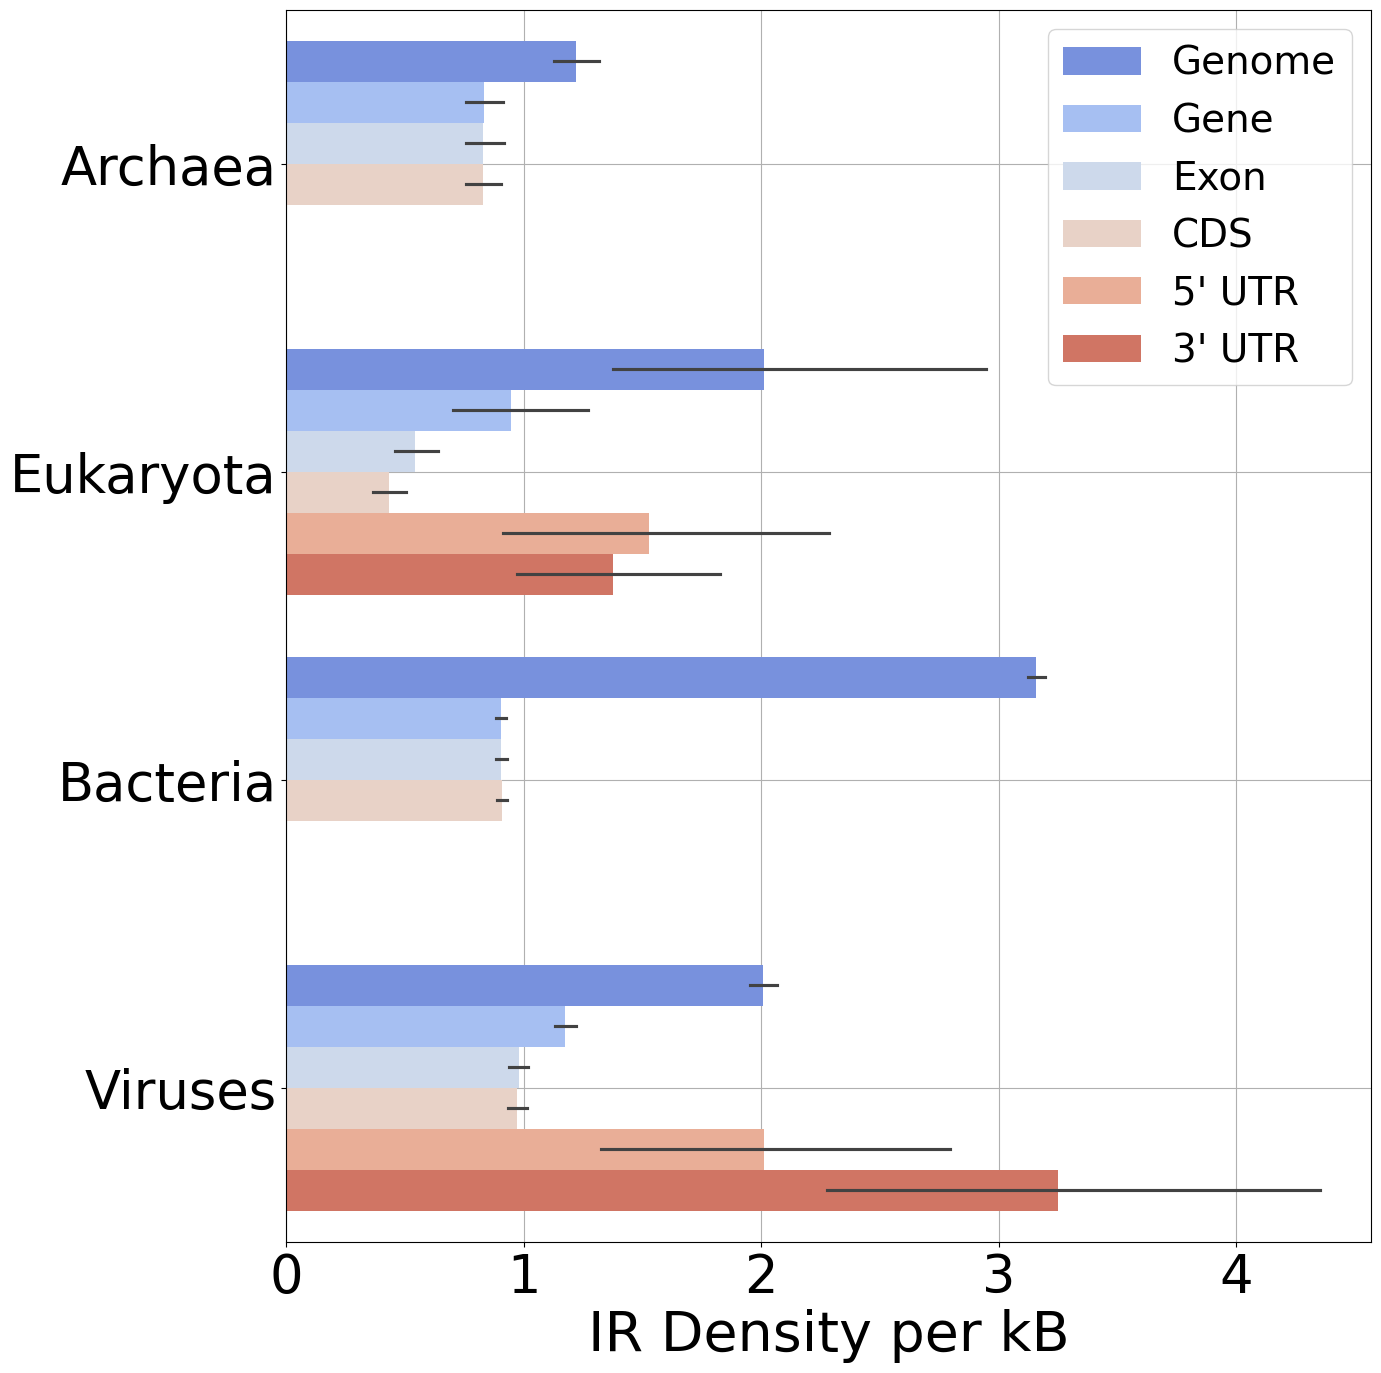

In [29]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 16))

sns.barplot(data=df.to_pandas(), 
            hue="compartment", 
            x="coverage", 
            capsize=0.0,
            y="domain", 
            order=["Archaea", "Eukaryota", "Bacteria", "Viruses"],
            hue_order=["Genome", "Gene", "Exon", "CDS", "5' UTR", "3' UTR"],
            # palette=domain_colors,
            palette="coolwarm",
            ax=ax,
            orient="h")
ax.grid()
ax.set_axisbelow(True)
ax.tick_params(axis="both", labelsize=38)
ax.set_xlabel(f"{pattern} Density per kB", fontsize=40)
ax.set_ylabel("")
ax.legend(title="", fontsize=28)
target = Path(f"{pattern}_figures").resolve().joinpath("TSS_TES")
target.mkdir(exist_ok=True, parents=True)
fig.savefig(f"{target}/coverage_domain_level_compartments_barplot_{pattern}.pdf", bbox_inches="tight", transparent=True)

In [26]:
coverage_df_species_taxid_partition["IR"]["compartment"].unique()

compartment
str
"""Exon"""
"""three_prime_UTR"""
"""Genome"""
"""CDS"""
"""Gene"""
"""five_prime_UTR"""


['Genome' 'Gene' 'Exon' 'CDS' "5' UTR" "3' UTR"]
{0: '#b2b2ff', 1: '#babaff', 2: '#c1c1ff', 3: '#c9c9ff', 4: '#d1d1ff', 5: '#d8d8ff', 6: '#e0e0ff', 7: '#e8e8ff', 8: '#f0f0ff'}
{0: '#edc41f', 1: '#efca35', 2: '#f1d04c', 3: '#f2d662', 4: '#f4dc79', 5: '#f6e28f', 6: '#f8e7a5', 7: '#faedbc', 8: '#fbf3d2'}
{0: '#b2d8b2', 1: '#badcba', 2: '#c1e0c1', 3: '#c9e4c9', 4: '#d1e8d1', 5: '#d8ecd8', 6: '#e0efe0', 7: '#e8f3e8', 8: '#f0f7f0'}
{0: '#229ad6', 1: '#38a4da', 2: '#4eaede', 3: '#64b8e2', 4: '#7ac2e6', 5: '#90cceb', 6: '#a7d7ef', 7: '#bde1f3', 8: '#d3ebf7'}


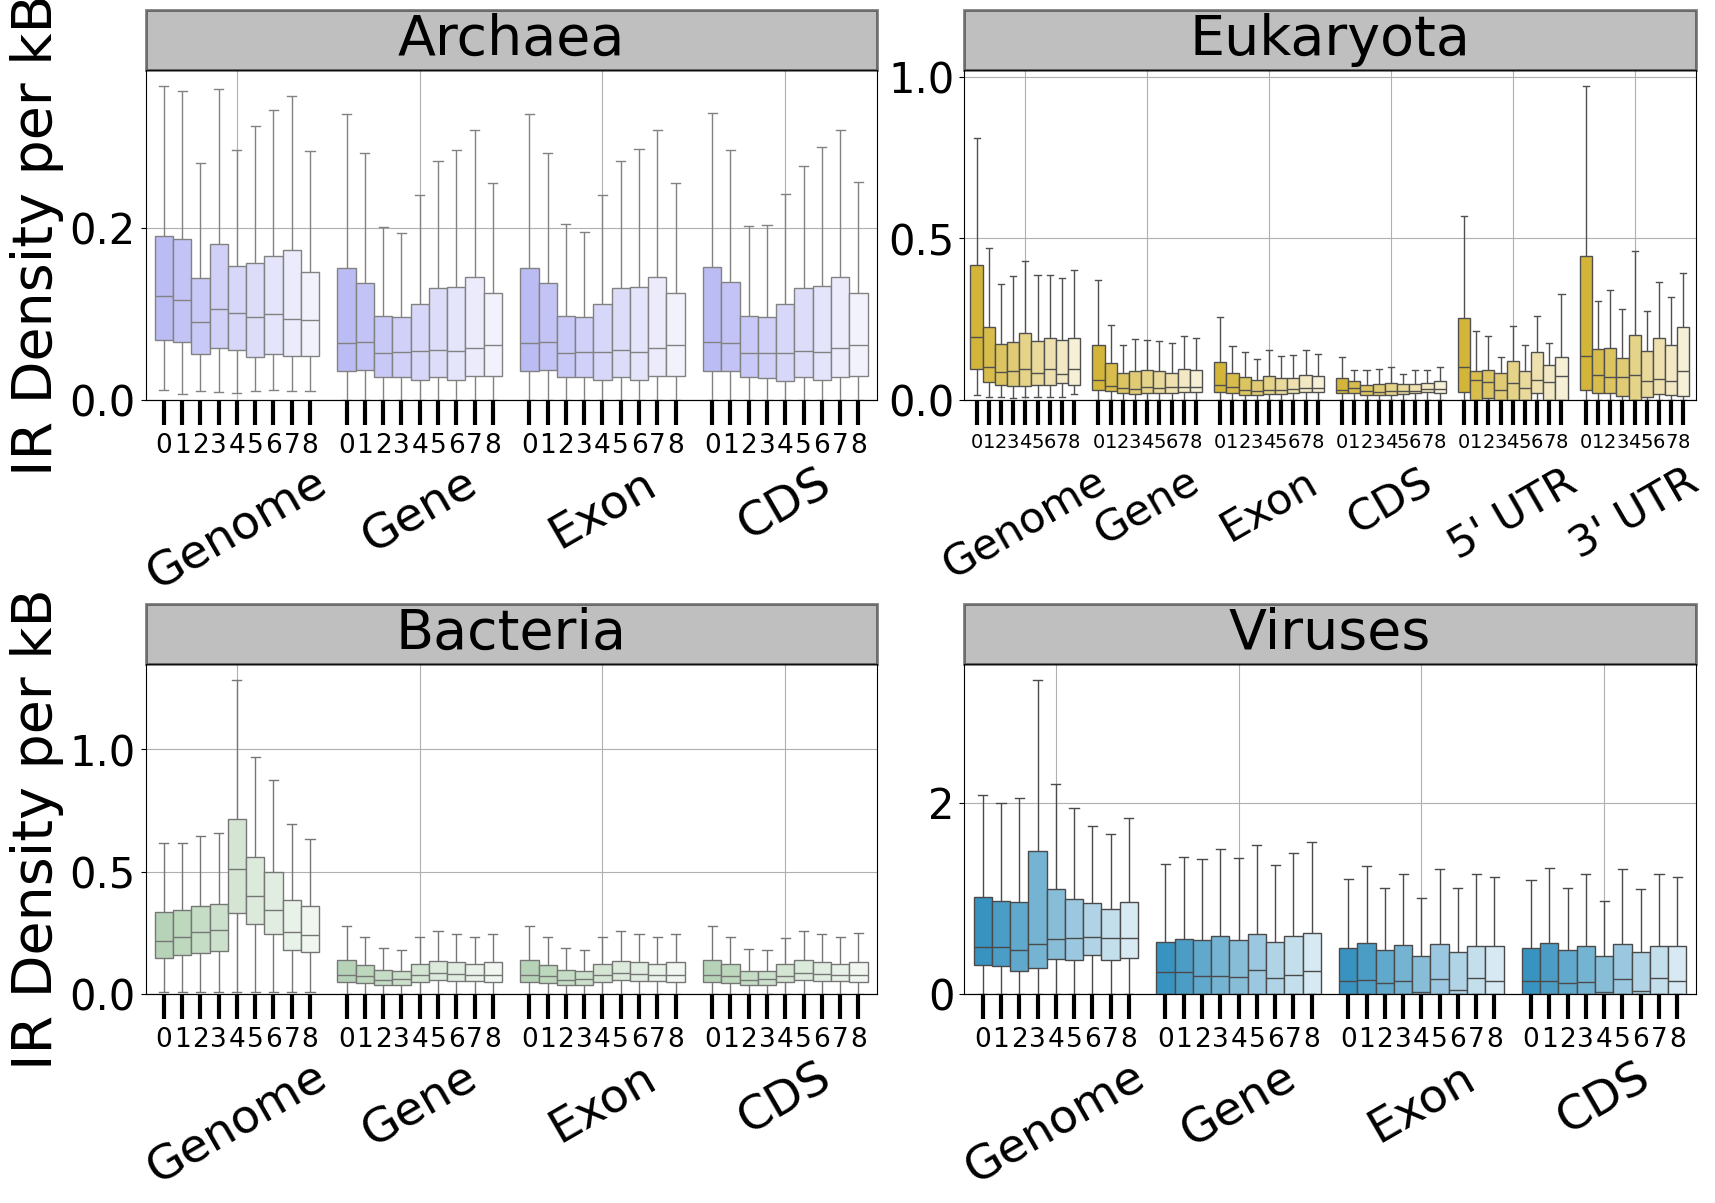

In [54]:
hue_order =  {"IR": list(range(9))}
width = 0.9
major_xtick_font_size = 26
wspace = 0.12
figsize = (20, 12)
for pattern, partition in patterns:
#     fig = plot_domain_level_coverage(
#             coverage_df_species_taxid_partition[pattern].to_pandas(), 
#             partition_col=partition,
#             width=width,
#             major_xtick_font_size=major_xtick_font_size,
#             xlabel_font_size=40,
#             ylabel_font_size=100,
#             wspace=wspace,
#             figsize=figsize,
#             hue_order=hue_order[pattern],
#             pattern=pattern, 
#             save_as=True)
#     plt.show()
    fig = plot_domain_level_coverage_boxplot(
                            coverage_df_species_taxid_partition[pattern].to_pandas(), 
                            partition_col=partition, 
                            width=width,
                            major_xtick_font_size=major_xtick_font_size,
                            xlabel_font_size=40,
                            ylabel_font_size=36,
                            wspace=wspace,
                            hspace=0.8,
                            figsize=figsize,
                            hue_order=hue_order[pattern],
                            pattern=pattern, 
                            save_as=True
                            )
    plt.show()

## Phylum Level Comparisons

In [55]:
phylum_to_domain = dict(zip(tree_of_life["phylum"], tree_of_life["domain"]))
len(phylum_to_domain)

129

In [56]:
valid_phylums = (
                 coverage_df_species_taxid[pattern]
                                            .group_by("phylum")
                                            .agg(total_species=pl.col("species_taxid").n_unique())
                                            .filter(pl.col("total_species") >= 4)["phylum"].to_list()
        )
valid_phylums

['Lentisphaerota',
 'Pseudomonadota',
 'Verrucomicrobiota',
 'Bacillota',
 'Aquificota',
 'Nitrospirota',
 'Produgelaviricota',
 'Armatimonadota',
 'Spirochaetota',
 'Bacteroidota',
 None,
 'Taleaviricota',
 'Uroviricota',
 'Pisuviricota',
 'Duplornaviricota',
 'Gemmatimonadota',
 'Chlorobiota',
 'Deinococcota',
 'Apicomplexa',
 'Cyanobacteriota',
 'Hofneiviricota',
 'Phixviricota',
 'Deferribacterota',
 'Acidobacteriota',
 'Chlorophyta',
 'Thermoplasmatota',
 'Preplasmiviricota',
 'Campylobacterota',
 'Chloroflexota',
 'Artverviricota',
 'Thermoproteota',
 'Dividoviricota',
 'Cossaviricota',
 'Streptophyta',
 'Kitrinoviricota',
 'Euglenozoa',
 'Candidatus Saccharimonadota',
 'Candidatus Micrarchaeota',
 'Planctomycetota',
 'Myxococcota',
 'Negarnaviricota',
 'Bdellovibrionota',
 'Basidiomycota',
 'Actinomycetota',
 'Peploviricota',
 'Saleviricota',
 'Ignavibacteriota',
 'Chordata',
 'Ascomycota',
 'Cressdnaviricota',
 'Methanobacteriota',
 'Lenarviricota',
 'Thermodesulfobacteriota',


In [58]:
import polars as pl
import numpy as np
from tqdm import tqdm

pattern = "IR"
coverage_df_phylum = dict()
for pattern, _ in tqdm(patterns):
    coverage_df_phylum[pattern] = (
        coverage_df_species_taxid[pattern].filter(pl.col("phylum").is_in(valid_phylums))
                        .with_columns(
                            coverage_log=pl.col("coverage").map_elements(lambda x: np.log10(x+1), return_dtype=pl.Float64)
                            )
                        .filter(~pl.col("phylum").is_null())
                        .group_by(["compartment", "phylum"], maintain_order=True)
                        .agg(pl.col("coverage_log").mean().alias(f"log(density_{pattern})"))
                        .pivot(on="compartment", index="phylum", values=f"log(density_{pattern})")
                        .select(["phylum", "Genome", "Gene", "Exon", "CDS"])
            )
coverage_df_phylum[pattern]

100%|██████████| 1/1 [00:00<00:00, 13.91it/s]


phylum,Genome,Gene,Exon,CDS
str,f64,f64,f64,f64
"""Pseudomonadota""",0.561849,0.217476,0.217474,0.218135
"""Mycoplasmatota""",0.84643,0.544186,0.544187,0.546448
"""Bacillota""",0.664588,0.228615,0.228614,0.22715
"""Duplornaviricota""",0.11338,0.092186,0.09116,0.082301
"""Negarnaviricota""",0.145299,0.083431,0.082131,0.081232
…,…,…,…,…
"""Gemmatimonadota""",0.50875,0.315916,0.315917,0.316365
"""Candidatus Micrarchaeota""",0.228214,0.119796,0.117668,0.11626
"""Euglenozoa""",0.332072,0.213348,0.213354,0.179755


In [62]:
# Color Palettes

kingdom_color_palette = {
                'Viruses': '#229ad6',
                'Bacteria': '#8eb812',
                "Archaea": "#b2b2ff",
                "Fungi": "#4d325e",
                "Plantae": "#b50996",
                "Metazoa": "#9bba2d",
                "Protista": "#c78f5b",
                } 
domain_colors = {
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#8eb812',
                'Viruses': '#229ad6',
}

/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_62834/3862166375.py:23: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("phylum").map_elements(lambda x: ...)
with this one instead:
  + pl.col("phylum").replace_strict(phylum_to_domain)

  domains = list(coverage_df_phylum[pattern].with_columns(pl.col("phylum").map_elements(lambda x: phylum_to_domain[x], return_dtype=str).alias("domain"))["domain"])


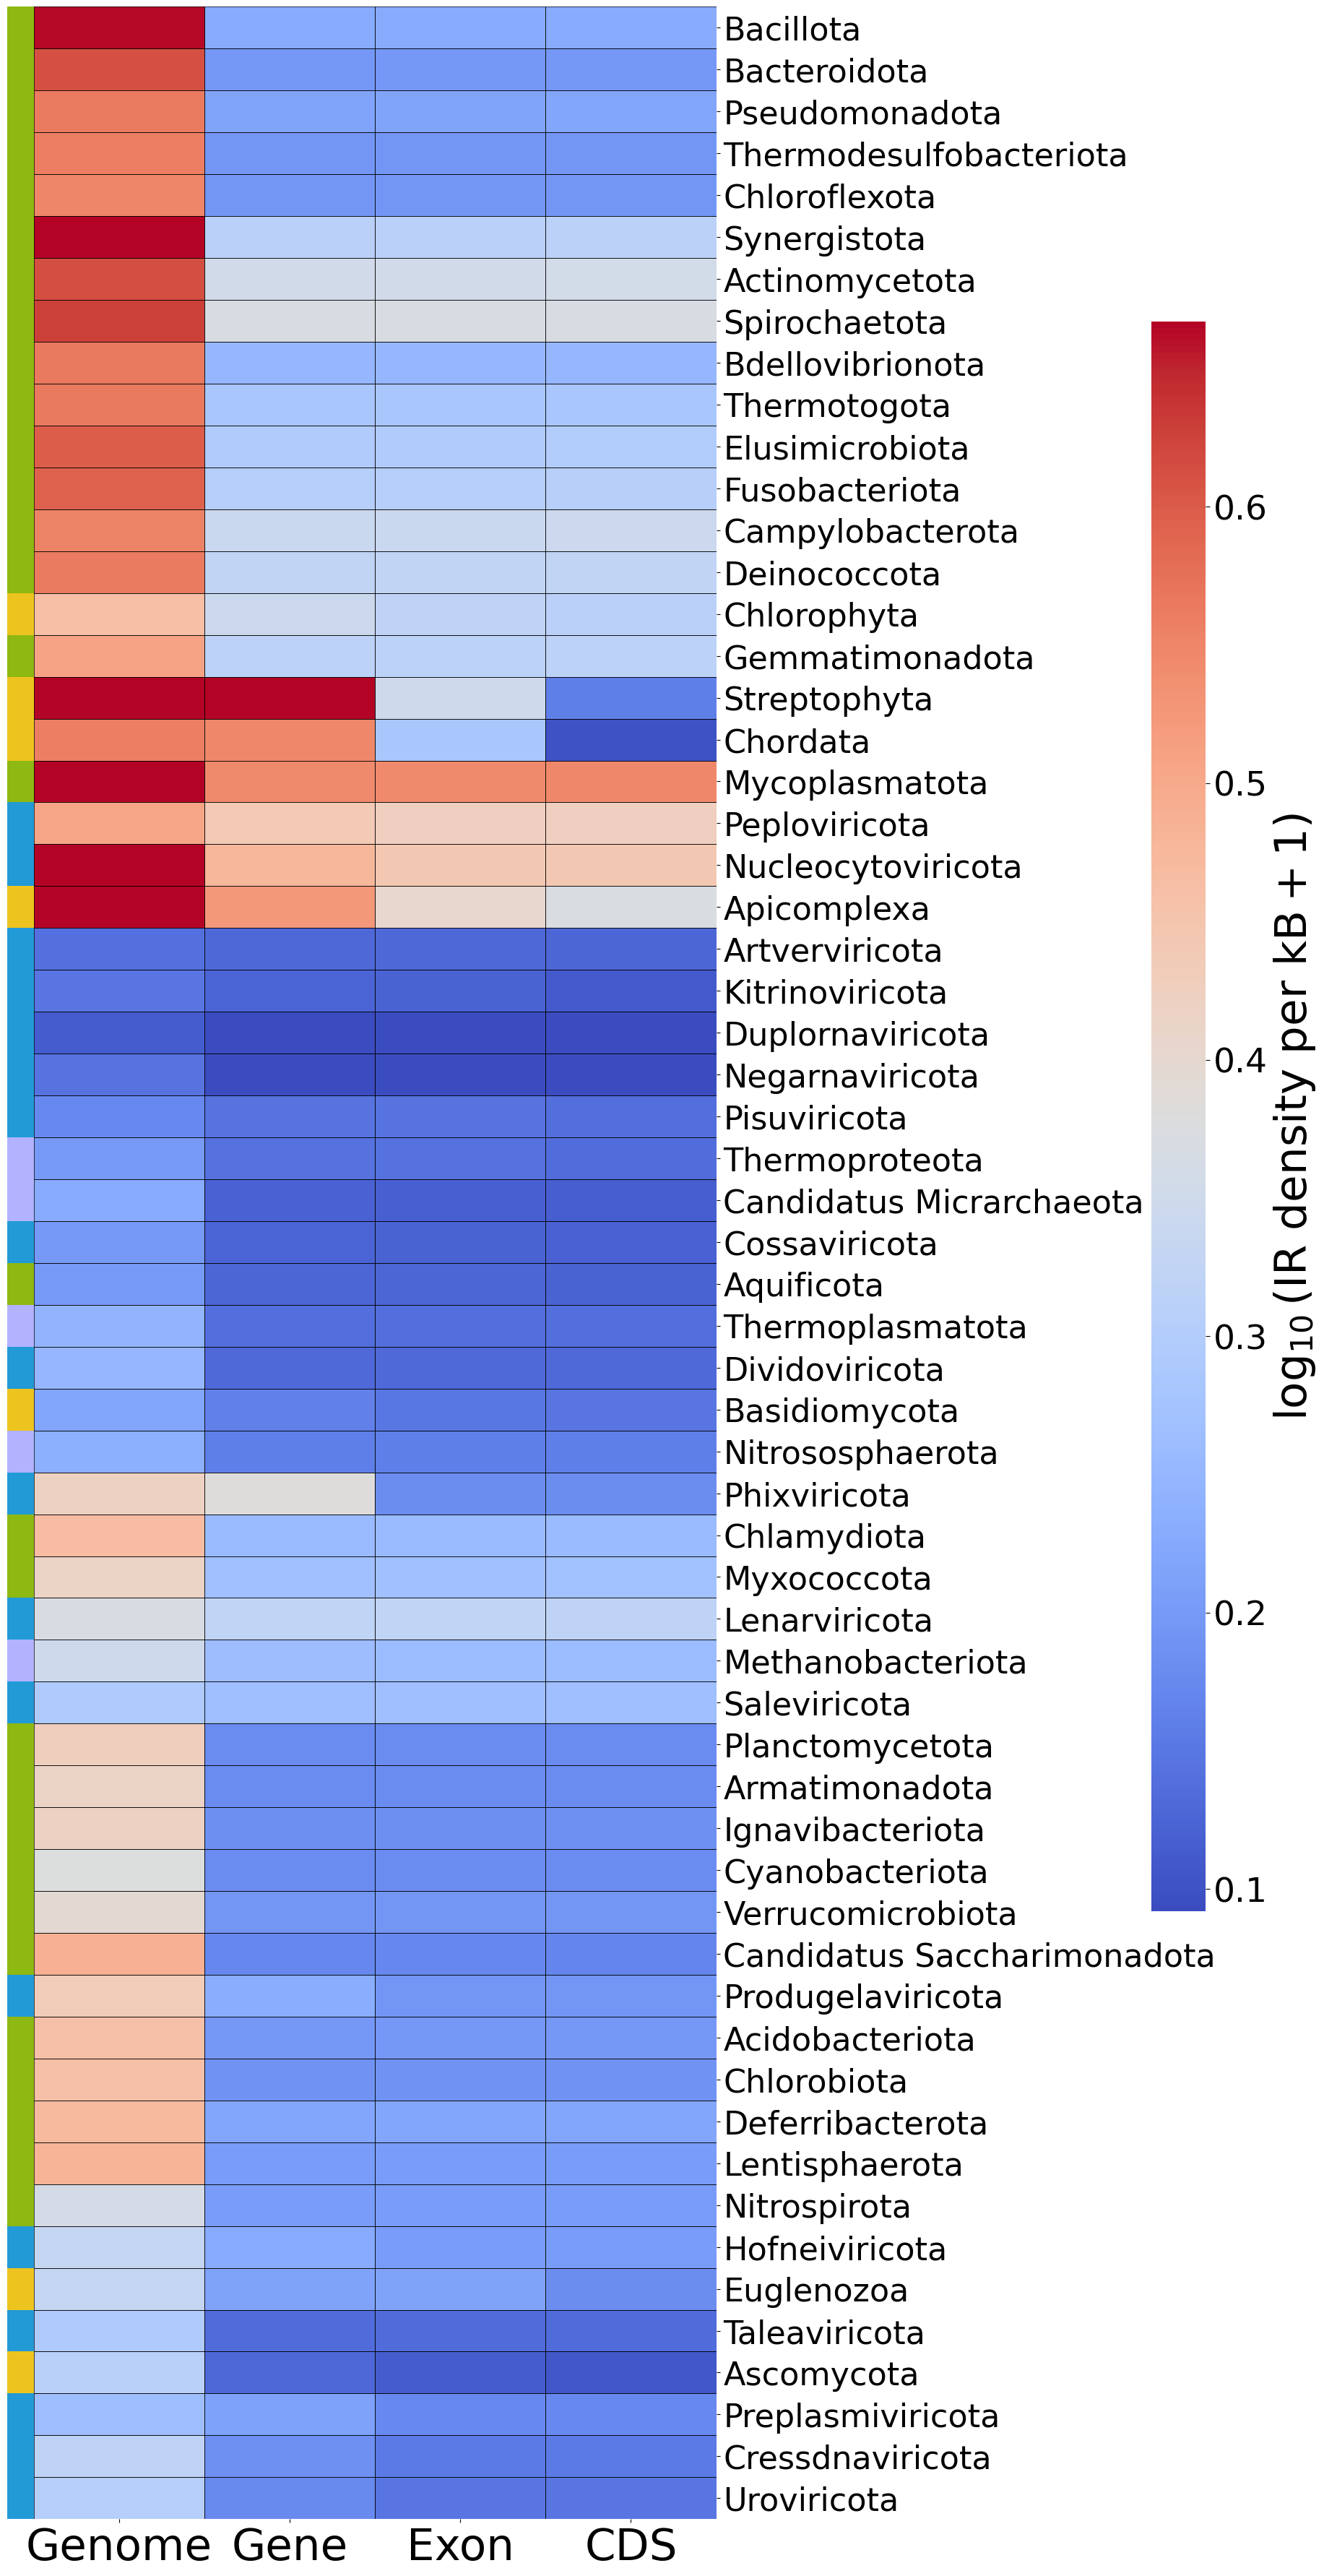

In [61]:
kws = dict(cbar_kws=dict(location="top", shrink=0.2))
figsize=(15, 44)
kingdom_color_palette = {
                'Viruses': '#229ad6',
                "Bacteria": "#0fbf2d",
                "Archaea": "#b2b2ff",
                "Fungi": "#4d325e",
                "Plantae": "#b50996",
                "Eubacteria": "#0fbf2d",
                "Metazoa": "#9bba2d",
                "Protista": "#c78f5b",
                "Archaeabacteria": "#7b7bed",
                } 
domain_colors = {
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#b2d8b2',
                'Viruses': '#229ad6',
}
domain_colors.update({"Bacteria": "#8eb812"})
kingdom_color_palette.update({"Bacteria": "#8eb812"})

domains = list(coverage_df_phylum[pattern].with_columns(pl.col("phylum").map_elements(lambda x: phylum_to_domain[x], return_dtype=str).alias("domain"))["domain"])
row_colors = [domain_colors[domain] for domain in domains]
order = ["Genome", "Gene", "Exon", "CDS"]

cg = sns.clustermap(
                  coverage_df_phylum[pattern].to_pandas().set_index("phylum")[order],
                   row_colors=[row_colors], # kingdom_colors],
                   row_cluster=True, 
                   col_cluster=False,
                    method="ward",
                   #  vmax=1.0,
                    cmap="coolwarm",
                   figsize=figsize,
                   robust=True,
                   yticklabels=True, 
                   xticklabels=True,
                   cbar_kws={"shrink": 0.1, 
                             "orientation": "vertical"}
                   )
ax = cg.ax_heatmap
cg.ax_row_dendrogram.set_visible(False)
cg.ax_col_dendrogram.set_visible(False)
ax = cg.ax_heatmap
ax.set_ylabel("")
t = ax.xaxis.get_majorticklocs()
ax.xaxis.label.set_size(22)
ax.yaxis.label.set_size(22)
ax.tick_params(axis="both", 
               which="major", 
               labelsize=32,
               rotation=0
              )
ax.tick_params(axis="x", 
               which="major", 
               labelsize=44,
               rotation=0
              )


x0, _y0, _w, _h = cg.cbar_pos
cg.ax_cbar.set_position([1.23, 0.2, 0.05, 0.5])
cg.ax_cbar.tick_params(axis='both', length=4, labelsize=34)


cg.cax.set_ylabel(r'$\log_{10}(\mathrm{IR\ density\ per\ kB+1})$', size=44)
for spine in cg.ax_cbar.spines:
    cg.ax_cbar.spines[spine].set_color('black')
    # cg.ax_cbar.spines[spine].set_linewidth(2)

ax.set_xlabel("", size=36)
import matplotlib.patches as patches
data = coverage_df_phylum[pattern].to_pandas().loc[cg.dendrogram_row.reordered_ind]
n_rows, n_cols = data.shape
for i in range(n_rows):
    for j in range(n_cols):
        rect = patches.Rectangle((j, i), 1, 1, linewidth=0.5, edgecolor='black', facecolor='none')
        ax.add_patch(rect)

fig = plt.gcf()
target = Path(f"{pattern}_figures").resolve()
target.mkdir(exist_ok=True)
fig.savefig(target.joinpath(f"{pattern}_clustermap_compartments_phylum_level.pdf"), bbox_inches='tight', transparent=True, dpi=600)
plt.show()

## Density

In [4]:
!find . -name "enrichment_out_STR"

./coverage_enrichment/enrichment_out_STR


In [11]:
!ls coverage_enrichment/enrichment_out_STR/mode_density_partition_sru | grep TSS

enrichment_bucket_0_500_gene_density.TSS.txt
enrichment_bucket_10_500_gene_density.TSS.txt
enrichment_bucket_11_500_gene_density.TSS.txt
enrichment_bucket_12_500_gene_density.TSS.txt
enrichment_bucket_13_500_gene_density.TSS.txt
enrichment_bucket_14_500_gene_density.TSS.txt
enrichment_bucket_15_500_gene_density.TSS.txt
enrichment_bucket_16_500_gene_density.TSS.txt
enrichment_bucket_17_500_gene_density.TSS.txt
enrichment_bucket_18_500_gene_density.TSS.txt
enrichment_bucket_19_500_gene_density.TSS.txt
enrichment_bucket_1_500_gene_density.TSS.txt
enrichment_bucket_20_500_gene_density.TSS.txt
enrichment_bucket_21_500_gene_density.TSS.txt
enrichment_bucket_22_500_gene_density.TSS.txt
enrichment_bucket_23_500_gene_density.TSS.txt
enrichment_bucket_24_500_gene_density.TSS.txt
enrichment_bucket_25_500_gene_density.TSS.txt
enrichment_bucket_26_500_gene_density.TSS.txt
enrichment_bucket_27_500_gene_density.TSS.txt
enrichment_bucket_28_500_gene_density.TSS.txt
enrichment_bucket_29_500_gene_densit

In [5]:
from pathlib import Path 
import pandas as pd 

pattern = "STR"
mode = "density"
partition_col = "sru"

# You can change the indir
indir = Path().cwd().joinpath("coverage_enrichment")

# # # # ## # # # # # #
tss = pd.read_table(
        indir.joinpath(f"enrichment_out_{pattern}", 
                       f"mode_{mode}_partition_{partition_col}",
                       f"enrichment_gene_density.TSS.txt"
                       )
        )

FileNotFoundError: [Errno 2] No such file or directory: '/Users/nikolchantzi/biolab/nonbdna_evolution/notebooks/IR/coverage_enrichment/enrichment_out_STR/mode_density_partition_sru/enrichment_gene_density.TSS.txt'

In [10]:
tss["spacer_length"].unique()

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', 'generic'],
      dtype=object)

In [10]:
tss.head()


NameError: name 'tss' is not defined

In [12]:

tes = pd.read_table(
        indir.joinpath(f"enrichment_out_{pattern}", 
                       f"mode_{mode}_partition_{partition_col}",
                       f"enrichment_gene_density.TES.txt"
                       )
        )

In [13]:
tss["#assembly_accession"].nunique(), tes["#assembly_accession"].nunique()

(88732, 88732)

In [14]:
tree_of_life

,#assembly_accession,taxid,species_taxid,organism_name,infraspecific_name,isolate,assembly_level,ftp_path,assembly_type,group,...,tax_id,domain,phylum,class,order,family,genus,species,kingdom,subkingdom
0,GCF_000762265.1,2162,2162,Methanobacterium formicicum,strain=BRM9,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,haploid,archaea,...,2162.0,Archaea,Methanobacteriota,Methanobacteria,Methanobacteriales,Methanobacteriaceae,Methanobacterium,Methanobacterium formicicum,Methanobacteriati,NaN
1,GCF_001458655.1,2162,2162,Methanobacterium formicicum,na,Mb9,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,haploid,archaea,...,2162.0,Archaea,Methanobacteriota,Methanobacteria,Methanobacteriales,Methanobacteriaceae,Methanobacterium,Methanobacterium formicicum,Methanobacteriati,NaN
2,GCF_002813085.1,2173,2173,Methanobrevibacter smithii,strain=KB11,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,haploid,archaea,...,2173.0,Archaea,Methanobacteriota,Methanobacteria,Methanobacteriales,Methanobacteriaceae,Methanobrevibacter,Methanobrevibacter smithii,Methanobacteriati,NaN
3,GCF_022846155.1,2173,2173,Methanobrevibacter smithii,strain=CE91-St67,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,haploid,archaea,...,2173.0,Archaea,Methanobacteriota,Methanobacteria,Methanobacteriales,Methanobacteriaceae,Methanobrevibacter,Methanobrevibacter smithii,Methanobacteriati,NaN
4,GCF_022846175.1,2173,2173,Methanobrevibacter smithii,strain=CE91-St68,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/0...,haploid,archaea,...,2173.0,Archaea,Methanobacteriota,Methanobacteria,Methanobacteriales,Methanobacteriaceae,Methanobrevibacter,Methanobrevibacter smithii,Methanobacteriati,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171379,GCA_037114785.1,3127874,3127874,Enterococcus phage vB_Efa_ZAT1,na,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/0...,haploid,viral,...,3127874.0,Viruses,Uroviricota,Caudoviricetes,NaN,NaN,Efquatrovirus,Enterococcus phage vB_Efa_ZAT1,Heunggongvirae,NaN
171380,GCA_037114795.1,3127946,3127946,Bacillus phage vB_Bsu_hmny1,na,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/0...,haploid,viral,...,3127946.0,Viruses,Uroviricota,Caudoviricetes,NaN,Salasmaviridae,Beecentumtrevirus,Bacillus phage vB_Bsu_hmny1,Heunggongvirae,NaN
171381,GCA_037114805.1,3127947,3127947,Bacillus phage vB_Bsu_hmny2,na,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/0...,haploid,viral,...,3127947.0,Viruses,Uroviricota,Caudoviricetes,NaN,Salasmaviridae,Beecentumtrevirus,Bacillus phage vB_Bsu_hmny2,Heunggongvirae,NaN
171382,GCA_037114815.1,3127948,3127948,Vibrio phage Va-ZX-1,na,na,Complete Genome,https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/0...,haploid,viral,...,3127948.0,Viruses,Uroviricota,Caudoviricetes,NaN,Autographiviridae,Kaohsiungvirus,Kaohsiungvirus VaZX1,Heunggongvirae,NaN


In [15]:
tss_tree_of_life = tss.query("biotype == '.'").merge(
                            tree_of_life.to_pandas()[["#assembly_accession", "species_taxid", "phylum", "kingdom", "domain"]],
                            on="#assembly_accession"
)
tes_tree_of_life = tes.query("biotype == '.'").merge(
                            tree_of_life.to_pandas()[["#assembly_accession", "species_taxid", "phylum", "kingdom", "domain"]],
                            on="#assembly_accession"
)

AttributeError: 'DataFrame' object has no attribute 'to_pandas'

In [ ]:
## Gini Coefficient Plot

In [ ]:
## from tqdm import tqdm
from collections import defaultdict
import random
import numpy as np

def gini_coefficient(values):
    if not values:
        return 0.0
    sorted_vals = sorted(values)
    total_tokens = sum(sorted_vals)
    population = len(sorted_vals)
    cumulative = 0
    gini_index = 0.0
    total = 0
    for i, val in enumerate(sorted_vals, start=1):
        cumulative += val
        gini_index += i / population - cumulative / total_tokens
        total += i / population
    return gini_index / (total-1)

partition_col = "sru"
partition_col = None

if partition_col:
    tss_tree_grped = tss_tree.groupby(["species_taxid", partition_col], as_index=False)\
                            .agg({str(i): "sum" for i in range(-window_size, window_size+1)} | {"domain": "first", "phylum": "first"})

    tes_tree_grped = tes_tree.groupby(["species_taxid", partition_col], as_index=False)\
                                .agg({str(i): "sum" for i in range(-window_size, window_size+1)} | {"domain": "first", "phylum": "first"})
else:
    tss_tree_grped = tss_tree.groupby(["species_taxid"], as_index=False)\
                            .agg({str(i): "sum" for i in range(-window_size, window_size+1)} | {"domain": "first", "phylum": "first"})

    tes_tree_grped = tes_tree.groupby(["species_taxid"], as_index=False)\
                                .agg({str(i): "sum" for i in range(-window_size, window_size+1)} | {"domain": "first", "phylum": "first"})

use_bootstrap = True
tss_gini_pos = defaultdict(list)
N = 1_000
alpha = 0.05

phylum = "Chordata"
tss_temp_df = tss_tree_grped.query(f"phylum == '{phylum}'")
tes_temp_df = tes_tree_grped.query(f"phylum == '{phylum}'")
for col in tqdm(xrange, leave=True, position=0):
    tss_gini_pos["pos"].append(col)
    tss_list = tss_temp_df[col].tolist()
    tes_list = tes_temp_df[col].tolist()
    if sum(tss_list) == 0:
        tss_gini_pos["tss_gini"].append(0)
    else:
        tss_gini_pos["tss_gini"].append(gini_coefficient(tss_list))
    if sum(tes_list) == 0:
        tss_gini_pos["tes_gini"].append(0)
    else:
        tss_gini_pos["tes_gini"].append(gini_coefficient(tes_list))
    #
    if use_bootstrap:
        bootstrap_tss = []
        bootstrap_tes = []
        for _ in range(N):
            tss_resampled = [random.choice(tss_list) for _ in range(len(tss_list))]
            tes_resampled = [random.choice(tes_list) for _ in range(len(tes_list))]
            if sum(tes_resampled) == 0:
                gini_coef_tes = 0
            else:
                gini_coef_tes = gini_coefficient(tes_resampled)y
                
            if sum(tss_resampled) == 0:
                gini_coef_tss = 0
            else:
                gini_coef_tss = gini_coefficient(tss_resampled)
            bootstrap_tss.append(gini_coef_tss)
            bootstrap_tes.append(gini_coef_tes)

        tss_lower_ci, tss_upper_ci = np.quantile(bootstrap_tss, [alpha/2, 1-alpha/2])
        tes_lower_ci, tes_upper_ci = np.quantile(bootstrap_tes, [alpha/2, 1-alpha/2])
        tss_gini_pos["tss_gini_lower_ci"].append(tss_lower_ci)
        tss_gini_pos["tss_gini_upper_ci"].append(tss_upper_ci)
        tss_gini_pos["tes_gini_lower_ci"].append(tes_lower_ci)
        tss_gini_pos["tes_gini_upper_ci"].append(tes_upper_ci)

tss_gini_pos = pd.DataFrame(tss_gini_pos)
tss_gini_pos

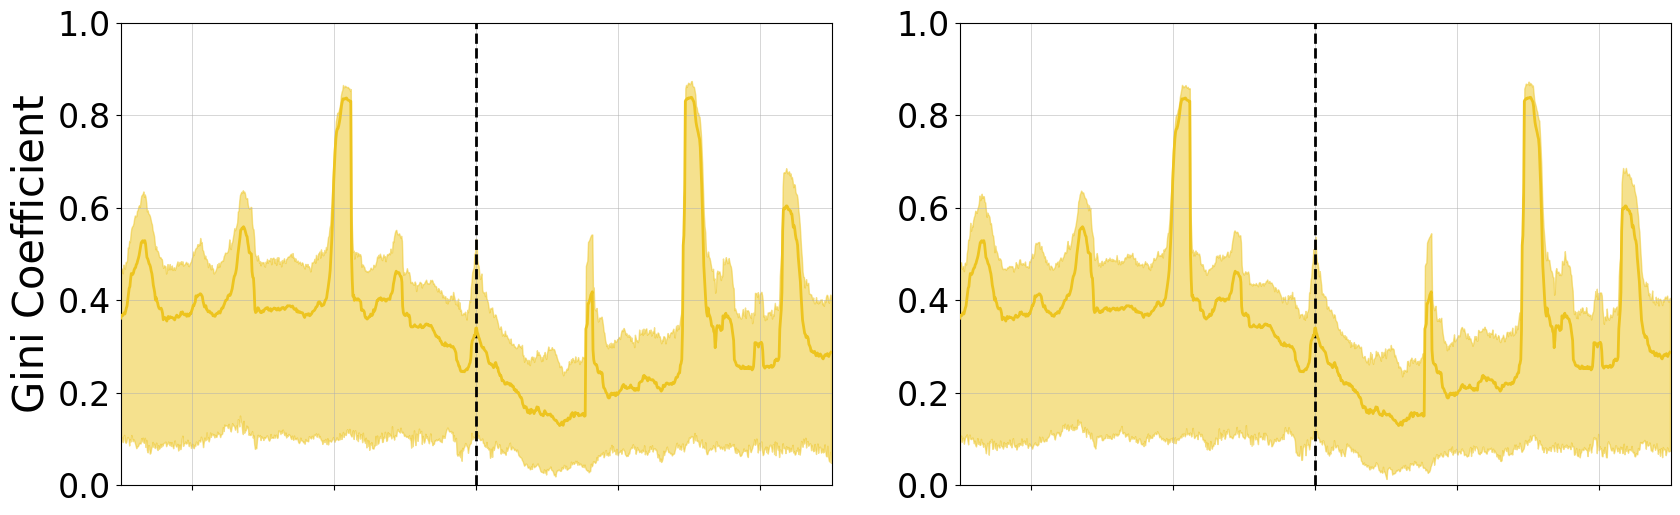

In [323]:
window_size = 500
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))
plt.subplots_adjust(wspace=0.18, hspace=0.12)
domain = "Eukaryota"
xaxis = range(-window_size, window_size+1)
ax[0].plot(xaxis, 
        tss_gini_pos["tss_gini"], 
        color=color_templates['template'][domain], 
        lw=linewidth, 
        zorder=3)
ax[0].fill_between(xaxis, 
                    y1=tss_gini_pos["tss_gini_lower_ci"], 
                    y2=tss_gini_pos["tss_gini_upper_ci"],
                    color=color_templates['template'][domain], 
                        alpha=0.5
                )
# TES
ax[1].plot(xaxis, 
        tss_gini_pos["tes_gini"], 
        color=color_templates['template'][domain], 
        lw=linewidth, 
        zorder=3)
ax[1].fill_between(xaxis, 
                    y1=tss_gini_pos["tes_gini_lower_ci"], 
                    y2=tss_gini_pos["tes_gini_upper_ci"],
                    color=color_templates['template'][domain], 
                        alpha=0.5
                )
def _modify_axis(ax, transcription_site):
    # xticks = ax.get_xticks()
    # ax.set_xticks(range(0, len(xticks), 100))
    if transcription_site == "start":
        # ax.set_ylabel("")
        ax.set_ylabel("Gini Coefficient")
    else:
        ax.set_ylabel("")
    ax.set_ylim(ymin=0, ymax=1)
    ax.set_xlim(-window_size, window_size+1)
    ax.yaxis.label.set_size(30)
    ax.xaxis.label.set_size(21)
    ax.tick_params(axis="both", which="major", labelsize=24)
    if idx != 3:
        ax.set_xticklabels([])
    ax.grid(True, which='both', axis='x') 
    ax.grid(axis="both", lw=0.4, alpha=0.6, zorder=0)
    ax.grid(axis="both", lw=0.6, alpha=0.6, zorder=0)
    ax.axvline(0, linestyle='--', color='black', lw=2.0)
    return ax

ax[0] = _modify_axis(ax[0], transcription_site="start")
ax[1] = _modify_axis(ax[1], transcription_site="end")

In [282]:
tss_tree_of_life[tss_tree_of_life["organism_name"].str.startswith("Cara")].head()

,-500,-499,-498,-497,-496,-495,-494,-493,-492,-491,...,query_perc,site,biotype,sru,#assembly_accession,species_taxid,organism_name,phylum,kingdom,domain
164150,433.0,439.0,423.0,415.0,425.0,461.0,489.0,528.0,552.0,644.0,...,44.96,TSS,.,1,GCF_023724105.1,101364,Carassius gibelio,Chordata,Metazoa,Eukaryota
164151,1043.0,1068.0,1084.0,1096.0,1092.0,1092.0,1109.0,1113.0,1103.0,1123.0,...,19.28,TSS,.,2,GCF_023724105.1,101364,Carassius gibelio,Chordata,Metazoa,Eukaryota
164152,222.0,225.0,221.0,227.0,219.0,226.0,227.0,226.0,225.0,212.0,...,9.25,TSS,.,3,GCF_023724105.1,101364,Carassius gibelio,Chordata,Metazoa,Eukaryota
164153,405.0,405.0,393.0,389.0,385.0,383.0,380.0,387.0,393.0,383.0,...,13.28,TSS,.,4,GCF_023724105.1,101364,Carassius gibelio,Chordata,Metazoa,Eukaryota
164154,78.0,80.0,81.0,80.0,76.0,78.0,82.0,77.0,81.0,79.0,...,3.48,TSS,.,5,GCF_023724105.1,101364,Carassius gibelio,Chordata,Metazoa,Eukaryota


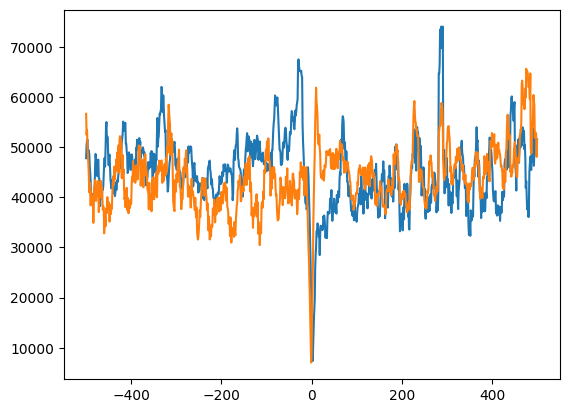

In [283]:
plt.plot(range(-window_size, window_size+1), tss_tree_of_life.query("sru == '2'")[xrange].sum())
plt.plot(range(-window_size, window_size+1), tes_tree_of_life.query("sru == '2'")[xrange].sum())

In [284]:
tss_gibelio = tss_tree_of_life.query("organism_name == 'Carassius gibelio' & sru == '1'")[xrange]
tss_gibelio.T / tss_gibelio.mean(axis=1)

,164150
-500,0.324172
-499,0.328664
-498,0.316685
-497,0.310696
-496,0.318183
...,...
496,0.200642
497,0.201391
498,0.223851
499,0.234332


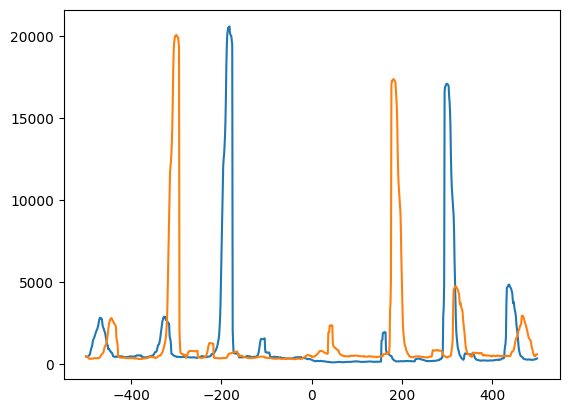

In [285]:
tss_gibelio = tss_tree_of_life.query("organism_name == 'Carassius gibelio' & sru == '1'")[xrange].T
tes_gibelio = tes_tree_of_life.query("organism_name == 'Carassius gibelio' & sru == '1'")[xrange].T

plt.plot(range(-window_size, window_size+1), tss_gibelio)
plt.plot(range(-window_size, window_size+1), tes_gibelio)

In [286]:
xrange = list(map(str, range(-window_size, window_size+1)))

tss_gibelio = tss_tree_of_life.query("organism_name == 'Carassius gibelio' & sru == '1'")[xrange]
tss_gibelio = tss_gibelio.T / tss_gibelio.mean(axis=1)
tes_gibelio = tes_tree_of_life.query("organism_name == 'Carassius gibelio' & sru == '1'")[xrange]
tes_gibelio = tes_gibelio.T / tes_gibelio.mean(axis=1)
tss_gibelio

,164150
-500,0.324172
-499,0.328664
-498,0.316685
-497,0.310696
-496,0.318183
...,...
496,0.200642
497,0.201391
498,0.223851
499,0.234332


In [287]:
tss_chordata_no_gibelio = tss_tree_of_life.query("organism_name != 'Carassius gibelio' & sru == '1' & phylum == 'Chordata'")\
                                .groupby(["species_taxid"], as_index=False)\
                                .agg({str(i): "sum" for i in range(-window_size, window_size+1)})

tes_chordata_no_gibelio = tes_tree_of_life.query("organism_name != 'Carassius gibelio' & sru == '1' & phylum == 'Chordata'")\
                                          .groupby(["species_taxid"], as_index=False)\
                                          .agg({str(i): "sum" for i in range(-window_size, window_size+1)})

In [288]:
from tqdm import tqdm

alpha = 0.95
N = 1000
window_size = 500
tss_bootstrap_data = []
tes_bootstrap_data = []
xrange = list(map(str, range(-window_size, window_size+1)))
for _ in tqdm(range(N)):
    tss_data = tss_chordata_no_gibelio.sample(frac=1.0, replace=True)[xrange].sum()
    tss_data = tss_data / tss_data.mean()
    tss_bootstrap_data.append(tss_data.to_frame().T)

    tes_data = tes_chordata_no_gibelio.sample(frac=1.0, replace=True)[xrange].sum()
    tes_data = tes_data / tes_data.mean()
    tes_bootstrap_data.append(tes_data.to_frame().T)
    
tss_bootstrap_data = pd.concat(tss_bootstrap_data, ignore_index=True)
tes_bootstrap_data = pd.concat(tes_bootstrap_data, ignore_index=True)
tss_bootstrap_data

100%|██████████| 1000/1000 [00:05<00:00, 193.38it/s]


,-500,-499,-498,-497,-496,-495,-494,-493,-492,-491,...,491,492,493,494,495,496,497,498,499,500
0,1.370013,1.339694,1.337800,1.355801,1.354854,1.359591,1.364328,1.318851,1.300849,1.298007,...,1.047880,1.030826,1.053565,1.017561,1.056407,1.067776,1.045037,1.028931,1.020404,1.020404
1,1.422719,1.378841,1.384160,1.396126,1.378841,1.386819,1.412082,1.394797,1.377511,1.358896,...,1.143494,1.102275,1.057067,1.009200,1.015848,1.043771,1.003881,1.025156,1.023826,1.009200
2,1.293760,1.284359,1.306686,1.329012,1.321962,1.329012,1.363089,1.346638,1.333713,1.312561,...,1.085771,1.056394,1.064620,1.036418,1.029368,1.048169,1.035243,1.023492,1.034068,1.016442
3,1.236110,1.221253,1.247253,1.279938,1.293309,1.303709,1.348281,1.359424,1.320052,1.296281,...,1.092739,1.074910,1.089025,1.068225,1.060053,1.068967,1.056339,1.071939,1.067482,1.055596
4,1.350206,1.323875,1.337040,1.342160,1.364834,1.378731,1.420423,1.421154,1.367029,1.357520,...,1.096402,1.084700,1.098597,1.048860,1.052517,1.052517,1.037889,1.062757,1.036426,1.026917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.279475,1.237540,1.255512,1.290601,1.304295,1.308574,1.348798,1.358212,1.316276,1.284611,...,1.139974,1.114299,1.080921,1.051823,1.044976,1.061237,1.031283,1.071507,1.062093,1.048400
996,1.262336,1.246118,1.266841,1.298377,1.296575,1.300179,1.322705,1.297476,1.278554,1.265940,...,1.034377,1.015455,1.046991,1.028971,1.050595,1.068616,1.056902,1.031674,1.043387,1.035278
997,1.267439,1.265352,1.283086,1.316467,1.319596,1.326899,1.356107,1.337330,1.324812,1.300820,...,1.080713,1.056720,1.078627,1.059850,1.054634,1.067152,1.057764,1.048375,1.052548,1.041073
998,1.308021,1.282850,1.287190,1.328852,1.341872,1.350552,1.374855,1.367043,1.340136,1.312361,...,1.125749,1.101446,1.093634,1.072803,1.077143,1.088427,1.061520,1.091898,1.077143,1.074539


In [ ]:
alpha = 0.05

# TES
tss_bootstrap_data_avg = tss_bootstrap_data.mean()
tss_bootstrap_data_lower_ci = tss_bootstrap_data.quantile(alpha / 2)
tss_bootstrap_data_upper_ci = tss_bootstrap_data.quantile(1-alpha / 2)

# TES
tes_bootstrap_data_avg = tes_bootstrap_data.mean()
tes_bootstrap_data_lower_ci = tes_bootstrap_data.quantile(alpha / 2)
tes_bootstrap_data_upper_ci = tes_bootstrap_data.quantile(1-alpha / 2)

In [290]:
tes_bootstrap_data_avg

-500    0.830012
-499    0.824003
-498    0.811290
-497    0.809994
-496    0.807421
          ...   
496     1.051522
497     1.061769
498     1.076872
499     1.064821
500     1.067421
Length: 1001, dtype: float64

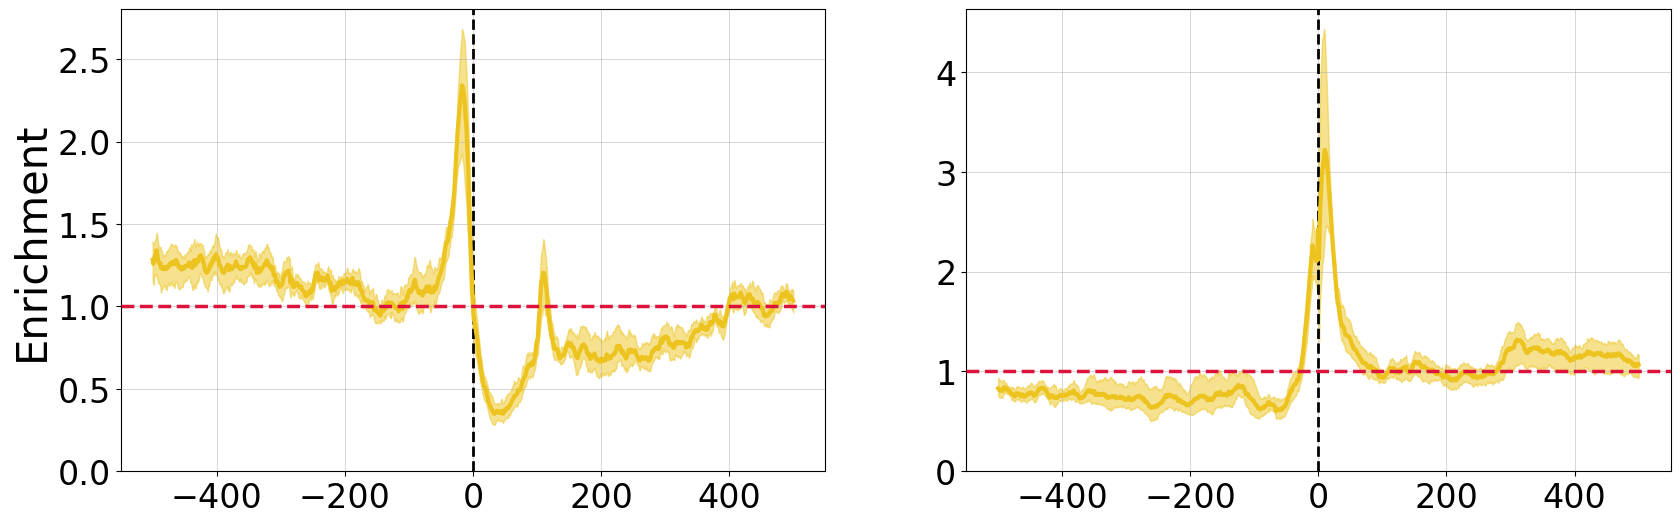

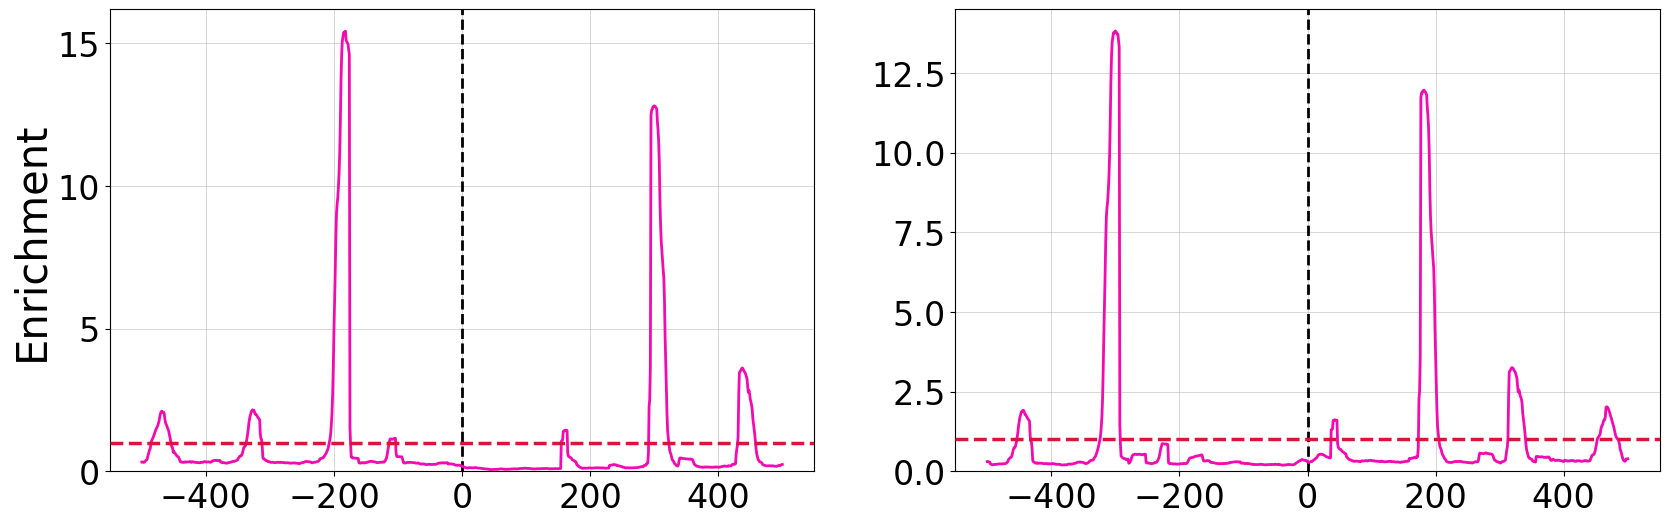

In [ ]:
# Chordata TSS-TES
linewidth = 3.0
figsize = (20, 6)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=figsize)
ax = ax.flatten()
xaxis = range(-window_size, window_size+1)
ax[0].plot(xaxis, 
        tss_bootstrap_data_avg, 
        color=color_templates['template']['Eukaryota'], 
        lw=linewidth, 
        zorder=3)
ax[0].fill_between(xaxis, 
                    y1=tss_bootstrap_data_lower_ci, 
                    y2=tss_bootstrap_data_upper_ci,
                    color=color_templates['template']['Eukaryota'], 
                        alpha=0.5
                )
# TES
ax[1].plot(xaxis, 
        tes_bootstrap_data_avg, 
        color=color_templates['template']['Eukaryota'], 
        lw=linewidth, 
        zorder=3)
ax[1].fill_between(xaxis, 
                    y1=tes_bootstrap_data_lower_ci, 
                    y2=tes_bootstrap_data_upper_ci,
                    color=color_templates['template']['Eukaryota'], 
                        alpha=0.5
                )
# ax.legend(handles=[mpatches.Patch(color=color_templates['template'][domain], label='Template'),
#                   mpatches.Patch(color=color_templates['non-template'][domain], label='Non-template')
#                  ], loc=0
#         )

def _modify_axis(ax, transcription_site):
    # xticks = ax.get_xticks()
    # ax.set_xticks(range(0, len(xticks), 100))
    if transcription_site == "start":
        # ax.set_ylabel("")
        ax.set_ylabel("Enrichment")
    else:
        ax.set_ylabel("")

    ax.set_ylim(ymin=0)
    
    ax.yaxis.label.set_size(30)
    ax.xaxis.label.set_size(21)
    ax.tick_params(axis="both", which="major", labelsize=24)
    ax.grid(True, which='both', axis='x') 
    ax.grid(axis="both", lw=0.4, alpha=0.6, zorder=0)
    ax.grid(axis="both", lw=0.6, alpha=0.6, zorder=0)
    ax.axvline(0, linestyle='--', color='black', lw=2.0)
    ax.axhline(1.0, linestyle='--', color='crimson', lw=2.5, zorder=5)
    return ax

ax[0] = _modify_axis(ax[0], transcription_site="start")
ax[1] = _modify_axis(ax[1], transcription_site="end")
target = Path("/storage/group/izg5139/default/nicole/STR_RTR/STR_figures/TSS_TES").resolve()
target.mkdir(exist_ok=True)
fig.savefig(target.joinpath(f"chordata_STR_density_TSS_TES_no_gibelio_mononucleotides.pdf"), bbox_inches='tight', dpi=600)

# Carassius Gibelio
gibelio_color = "#f30bb1"
linewidth = 2.0
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=figsize)
ax = ax.flatten()
xaxis = range(-window_size, window_size+1)
ax[0].plot(xaxis, 
        tss_gibelio, 
        color=gibelio_color, 
        lw=linewidth, 
        zorder=3)
# TES
ax[1].plot(xaxis, 
        tes_gibelio, 
        color=gibelio_color, 
        lw=linewidth, 
        zorder=3)

def _modify_axis(ax, transcription_site):
    # xticks = ax.get_xticks()
    # ax.set_xticks(range(0, len(xticks), 100))
    if transcription_site == "start":
        # ax.set_ylabel("")
        ax.set_ylabel("Enrichment")
    else:
        ax.set_ylabel("")

    ax.set_ylim(ymin=0)
    ax.yaxis.label.set_size(30)
    ax.xaxis.label.set_size(21)
    ax.tick_params(axis="both", which="major", labelsize=24)
    ax.grid(True, which='both', axis='x') 
    ax.grid(axis="both", lw=0.4, alpha=0.6, zorder=0)
    ax.grid(axis="both", lw=0.6, alpha=0.6, zorder=0)
    ax.axvline(0, linestyle='--', color='black', lw=2.0)
    ax.axhline(1.0, linestyle='--', color='crimson', lw=2.5, zorder=5)
    return ax

ax[0] = _modify_axis(ax[0], transcription_site="start")
ax[1] = _modify_axis(ax[1], transcription_site="end")
target = Path("/storage/group/izg5139/default/nicole/STR_RTR/STR_figures/TSS_TES").resolve()
target.mkdir(exist_ok=True)
fig.savefig(target.joinpath(f"carassius_gibelio_STR_density_TSS_TES_mononucleotides.pdf"), bbox_inches='tight', dpi=600)

# TSS & TES Domain Level STR

In [1]:
import pandas as pd
from pathlib import Path

pattern = "IR"
mode = "density"
partition_col = "spacer_length"
density = Path(f"enrichment_out_{pattern}") / f"mode_{mode}_partition_{partition_col}" / "domain_bootstrap"
density = Path("domain_bootstrap")
df = pd.read_csv(density.joinpath("enrichment_bootstrap_alpha_0.05...TES.density.domain.Archaea.csv"))
df

,domain,statistic,bootstrap_level,biotype,spacer_length,-500,-499,-498,-497,-496,...,491,492,493,494,495,496,497,498,499,500
0,Archaea,average,species_taxid,.,0,0.851,0.841,0.838,0.842,0.819,...,0.925,0.928,0.881,0.932,0.897,0.893,0.863,0.873,0.860,0.866
1,Archaea,lowerCI,species_taxid,.,0,0.739,0.723,0.722,0.719,0.699,...,0.773,0.782,0.779,0.828,0.790,0.791,0.767,0.776,0.763,0.766
2,Archaea,upperCI,species_taxid,.,0,0.961,0.951,0.942,0.962,0.936,...,1.113,1.117,1.004,1.055,1.019,1.011,0.966,0.977,0.957,0.973
3,Archaea,average,family,.,0,0.850,0.840,0.836,0.839,0.817,...,0.923,0.926,0.880,0.932,0.897,0.893,0.865,0.875,0.863,0.869
4,Archaea,lowerCI,family,.,0,0.673,0.673,0.664,0.656,0.640,...,0.767,0.786,0.768,0.820,0.803,0.802,0.769,0.774,0.769,0.768
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,Archaea,lowerCI,order,.,generic,0.655,0.663,0.665,0.667,0.670,...,0.838,0.846,0.850,0.842,0.844,0.847,0.828,0.833,0.828,0.817
116,Archaea,upperCI,order,.,generic,0.965,0.968,0.965,0.916,0.931,...,1.069,1.159,1.120,1.137,1.132,1.140,1.089,1.102,1.101,1.018
117,Archaea,average,class,.,generic,0.791,0.783,0.781,0.766,0.769,...,0.936,0.965,0.956,0.961,0.955,0.958,0.938,0.940,0.938,0.919
118,Archaea,lowerCI,class,.,generic,0.641,0.646,0.646,0.649,0.645,...,0.784,0.797,0.810,0.804,0.822,0.829,0.807,0.825,0.818,0.809


In [ ]:
import scipy.stats as stats
import numpy as np
window_size = 500E
xrange = list(map(str, range(-window_size, window_size+1)))
domains = ["Eukaryota", "Bacteria", "Viruses", "Archaea"]
for domain in domains:
    tss_tree = tss_tree_of_life.query(f"domain == '{domain}'")
    tes_tree = tes_tree_of_life.query(f"domain == '{domain}'")
    
    # TSS
    tss_grouped = tss_tree.reset_index(drop=True)\
                        .groupby("species_taxid")\
                        .agg({str(i): "sum" for i in range(-window_size, window_size+1)})[xrange]\
                        .reset_index(drop=True)
    tss_normalized = tss_grouped.apply(lambda row: row / row.mean(), axis=1)
    tss_avg = tss_normalized.mean()
    tss_std = tss_normalized.std()
    n_tss = len(tss_normalized)
    
    # Calculate 95% confidence intervals for TSS
    confidence_level = 0.99
    alpha = 1 - confidence_level
    t_critical = stats.t.ppf(1 - alpha/2, df=n_tss-1)
    tss_stderr = tss_std / np.sqrt(n_tss)
    tss_ci_lower = tss_avg - t_critical * tss_stderr
    tss_ci_upper = tss_avg + t_critical * tss_stderr

    # TES
    tes_grouped = tes_tree.reset_index(drop=True)\
                        .groupby("species_taxid")\
                        .agg({str(i): "sum" for i in range(-window_size, window_size+1)})[xrange]\
                        .reset_index(drop=True)
    tes_normalized = tes_grouped.apply(lambda row: row / row.mean(), axis=1)
    tes_avg = tes_normalized.mean()
    tes_std = tes_normalized.std()
    n_tes = len(tes_normalized)
    
    # Calculate 95% confidence intervals for TES
    t_critical_tes = stats.t.ppf(1 - alpha/2, df=n_tes-1)
    tes_stderr = tes_std / np.sqrt(n_tes)
    tes_ci_lower = tes_avg - t_critical_tes * tes_stderr
    tes_ci_upper = tes_avg + t_critical_tes * tes_stderr

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))
    
    # Plot TSS with confidence intervals
    x_positions = list(map(int, xrange))
    ax[0].plot(x_positions, 
               tss_avg.values, 
               color=domain_colors[domain], 
               label="TSS", 
               lw=3.0)
    ax[0].fill_between(x_positions,
                       tss_ci_lower.values,
                       tss_ci_upper.values,
                       color=domain_colors[domain],
                       alpha=0.2,
                       label=f"{confidence_level*100}% CI")

    # Plot TES with confidence intervals
    ax[1].plot(x_positions, 
               tes_avg.values, 
               color=domain_colors[domain], 
               lw=3.0)
    ax[1].fill_between(x_positions,
                       tes_ci_lower.values,
                       tes_ci_upper.values,
                       color=domain_colors[domain],
                       alpha=0.2,
                       label=f"{confidence_level*100}% CI")

    for i in range(2):
        ax[i].grid()
        ax[i].axhline(1.0, color='crimson', lw=2.0, ls='--')
        ax[i].axvline(0.0, color='black', lw=2.0, ls='--')
        ax[i].tick_params(axis="both", labelsize=19)
        ax[i].tick_params(axis="x", labelsize=22)
        if i == 0:
            ax[i].set_ylabel("Enrichment")
            ax[i].legend(loc='upper right', fontsize=14)
        else:
            ax[i].set_ylabel("")
            ax[i].legend(loc='upper right', fontsize=14)
        ax[i].yaxis.label.set_size(30)
        ax[i].set_title(domain)
        ax[i].title.set_size(32)
    
    print(f"{domain}: TSS n={n_tss}, TES n={n_tes}")
    plt.show()

Eukaryota: TSS n=145, TES n=145


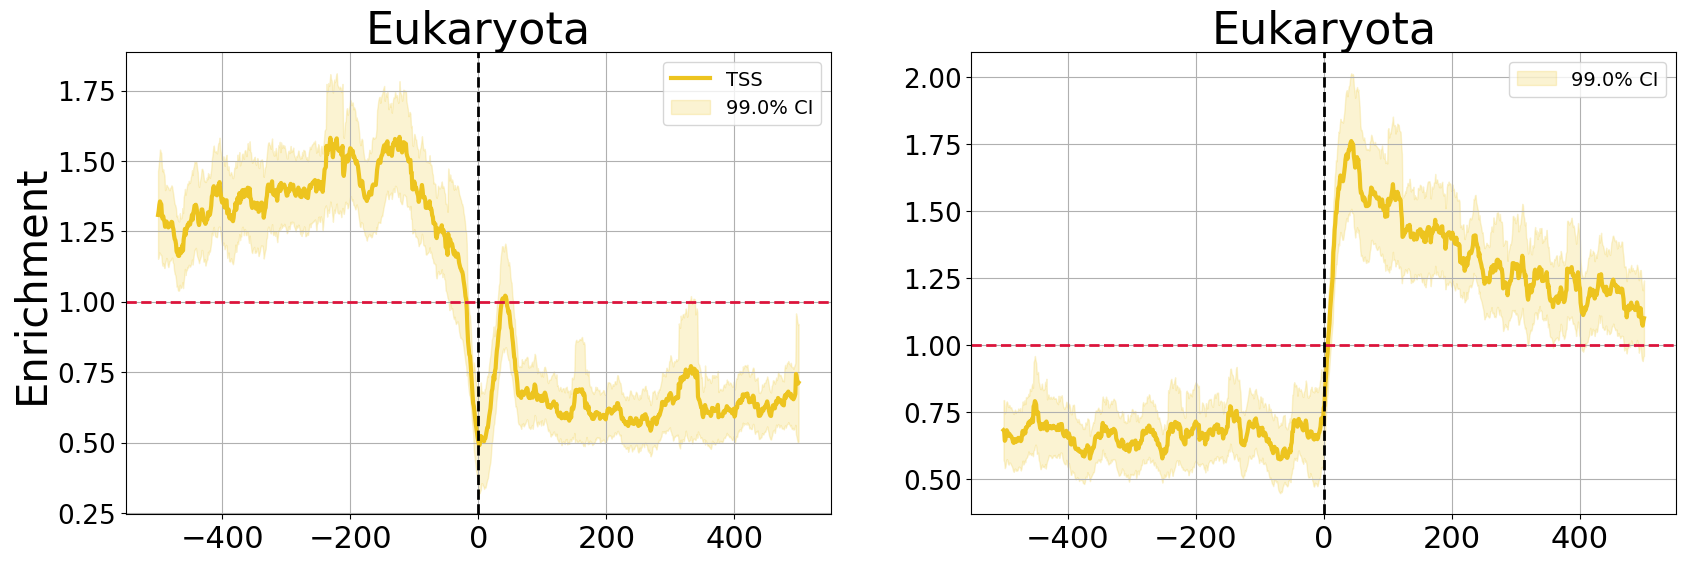

Bacteria: TSS n=10555, TES n=10555


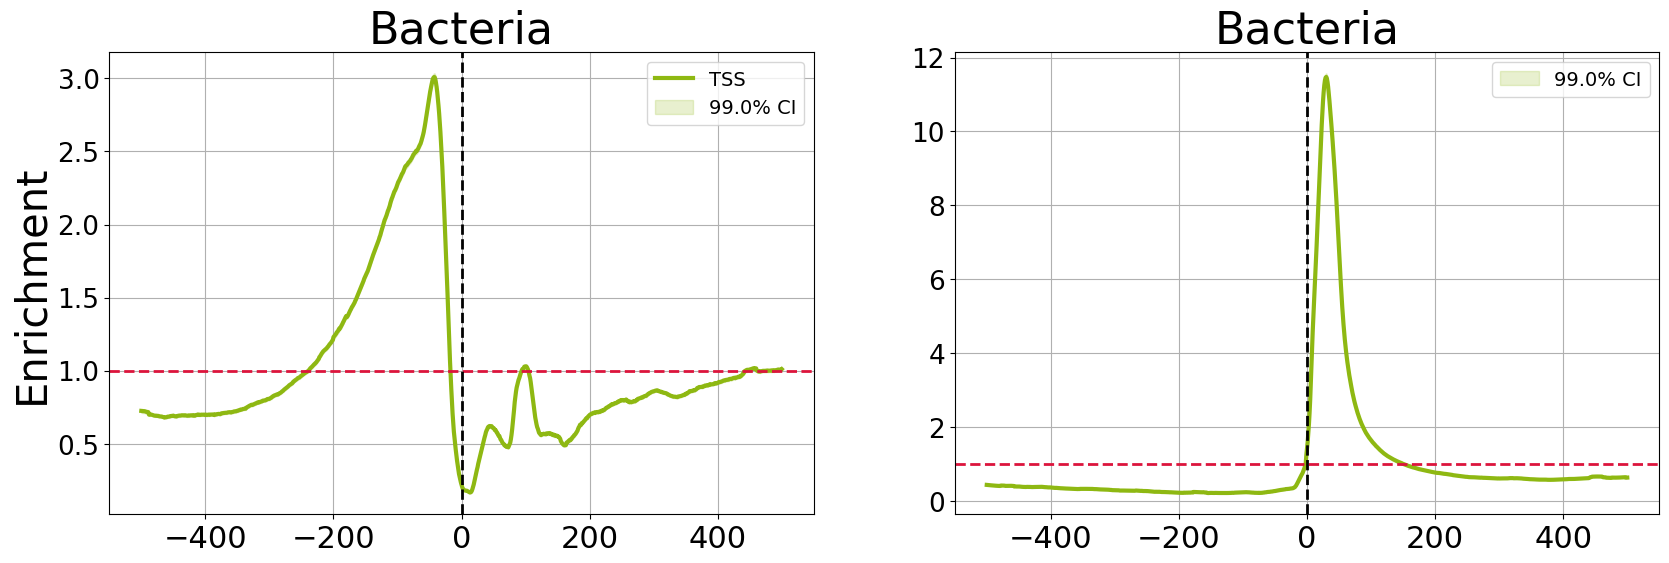

Viruses: TSS n=21970, TES n=21970


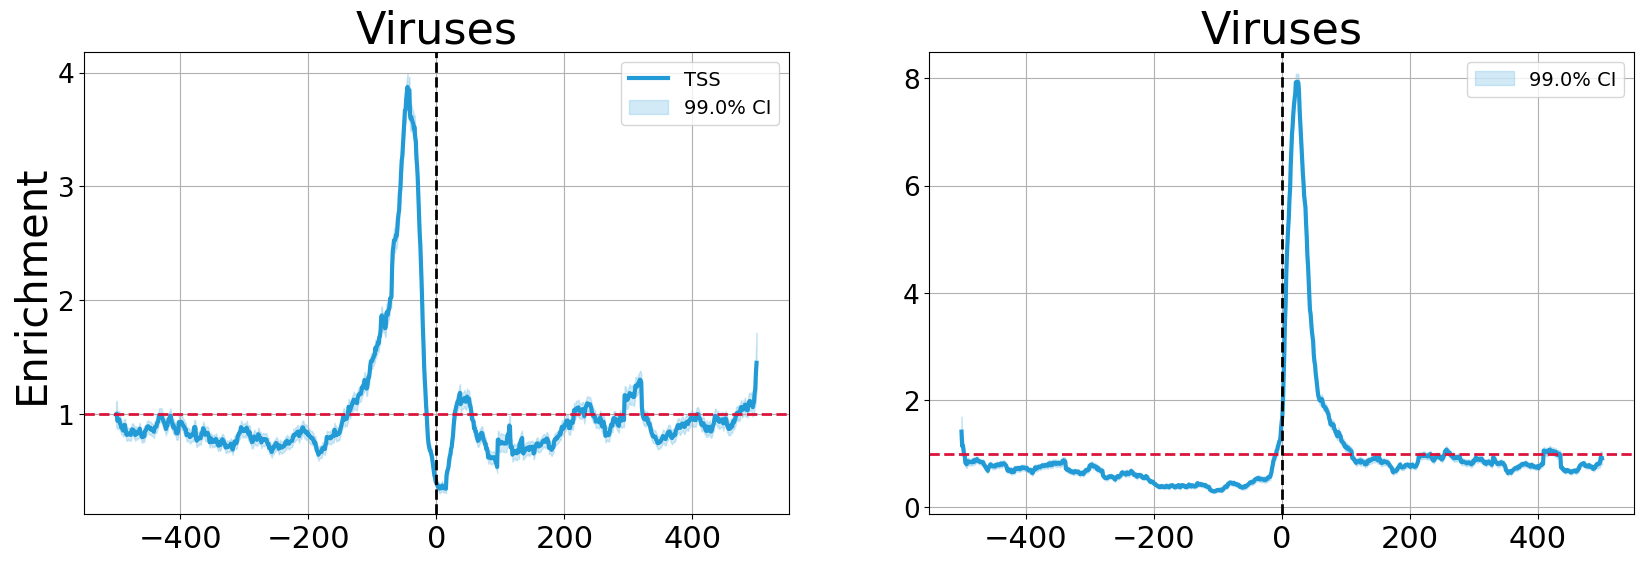

Archaea: TSS n=502, TES n=502


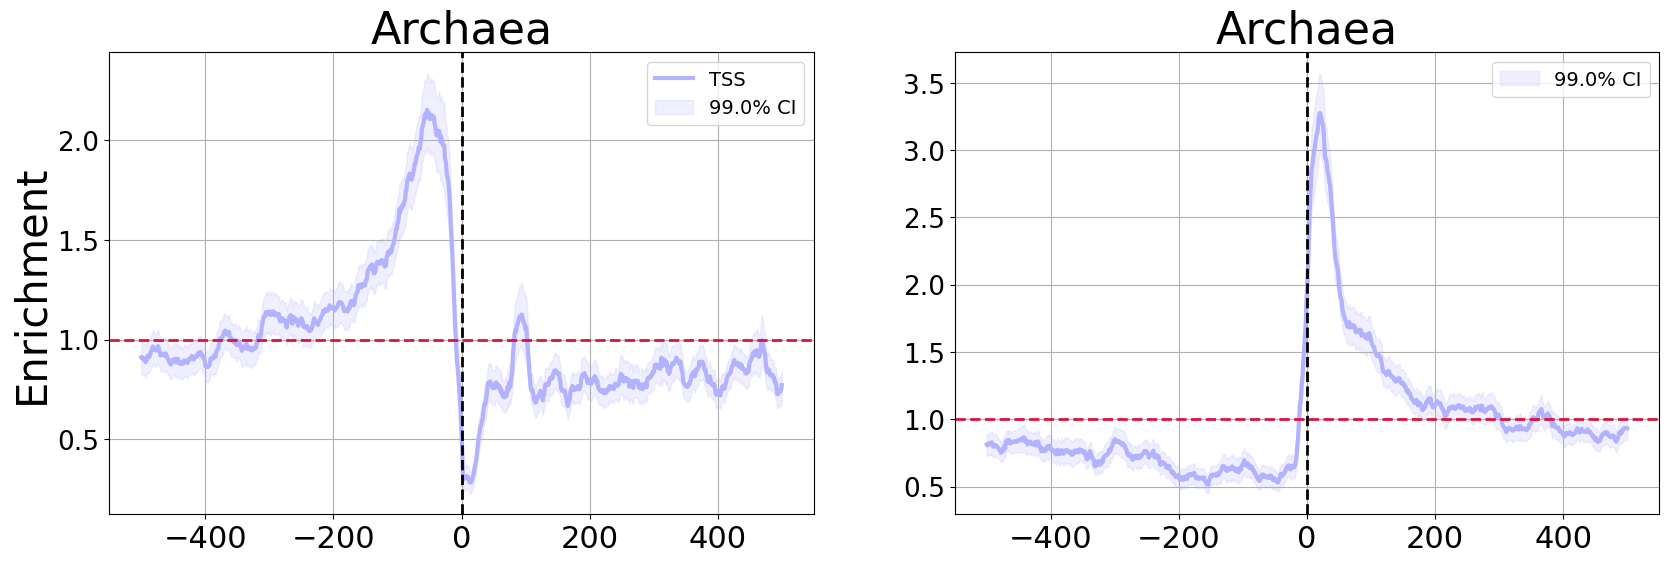

In [ ]:
import scipy.stats as stats
import numpy as np
window_size = 500E
xrange = list(map(str, range(-window_size, window_size+1)))
domains = ["Eukaryota", "Bacteria", "Viruses", "Archaea"]
for domain in domains:
    tss_tree = tss_tree_of_life.query(f"domain == '{domain}'")
    tes_tree = tes_tree_of_life.query(f"domain == '{domain}'")
    
    # TSS
    tss_grouped = tss_tree.reset_index(drop=True)\
                        .groupby("species_taxid")\
                        .agg({str(i): "sum" for i in range(-window_size, window_size+1)})[xrange]\
                        .reset_index(drop=True)
    tss_normalized = tss_grouped.apply(lambda row: row / row.mean(), axis=1)
    tss_avg = tss_normalized.mean()
    tss_std = tss_normalized.std()
    n_tss = len(tss_normalized)
    
    # Calculate 95% confidence intervals for TSS
    confidence_level = 0.99
    alpha = 1 - confidence_level
    t_critical = stats.t.ppf(1 - alpha/2, df=n_tss-1)
    tss_stderr = tss_std / np.sqrt(n_tss)
    tss_ci_lower = tss_avg - t_critical * tss_stderr
    tss_ci_upper = tss_avg + t_critical * tss_stderr

    # TES
    tes_grouped = tes_tree.reset_index(drop=True)\
                        .groupby("species_taxid")\
                        .agg({str(i): "sum" for i in range(-window_size, window_size+1)})[xrange]\
                        .reset_index(drop=True)
    tes_normalized = tes_grouped.apply(lambda row: row / row.mean(), axis=1)
    tes_avg = tes_normalized.mean()
    tes_std = tes_normalized.std()
    n_tes = len(tes_normalized)
    
    # Calculate 95% confidence intervals for TES
    t_critical_tes = stats.t.ppf(1 - alpha/2, df=n_tes-1)
    tes_stderr = tes_std / np.sqrt(n_tes)
    tes_ci_lower = tes_avg - t_critical_tes * tes_stderr
    tes_ci_upper = tes_avg + t_critical_tes * tes_stderr

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))
    
    # Plot TSS with confidence intervals
    x_positions = list(map(int, xrange))
    ax[0].plot(x_positions, 
               tss_avg.values, 
               color=domain_colors[domain], 
               label="TSS", 
               lw=3.0)
    ax[0].fill_between(x_positions,
                       tss_ci_lower.values,
                       tss_ci_upper.values,
                       color=domain_colors[domain],
                       alpha=0.2,
                       label=f"{confidence_level*100}% CI")

    # Plot TES with confidence intervals
    ax[1].plot(x_positions, 
               tes_avg.values, 
               color=domain_colors[domain], 
               lw=3.0)
    ax[1].fill_between(x_positions,
                       tes_ci_lower.values,
                       tes_ci_upper.values,
                       color=domain_colors[domain],
                       alpha=0.2,
                       label=f"{confidence_level*100}% CI")

    for i in range(2):
        ax[i].grid()
        ax[i].axhline(1.0, color='crimson', lw=2.0, ls='--')
        ax[i].axvline(0.0, color='black', lw=2.0, ls='--')
        ax[i].tick_params(axis="both", labelsize=19)
        ax[i].tick_params(axis="x", labelsize=22)
        if i == 0:
            ax[i].set_ylabel("Enrichment")
            ax[i].legend(loc='upper right', fontsize=14)
        else:
            ax[i].set_ylabel("")
            ax[i].legend(loc='upper right', fontsize=14)
        ax[i].yaxis.label.set_size(30)
        ax[i].set_title(domain)
        ax[i].title.set_size(32)
    
    print(f"{domain}: TSS n={n_tss}, TES n={n_tes}")
    plt.show()

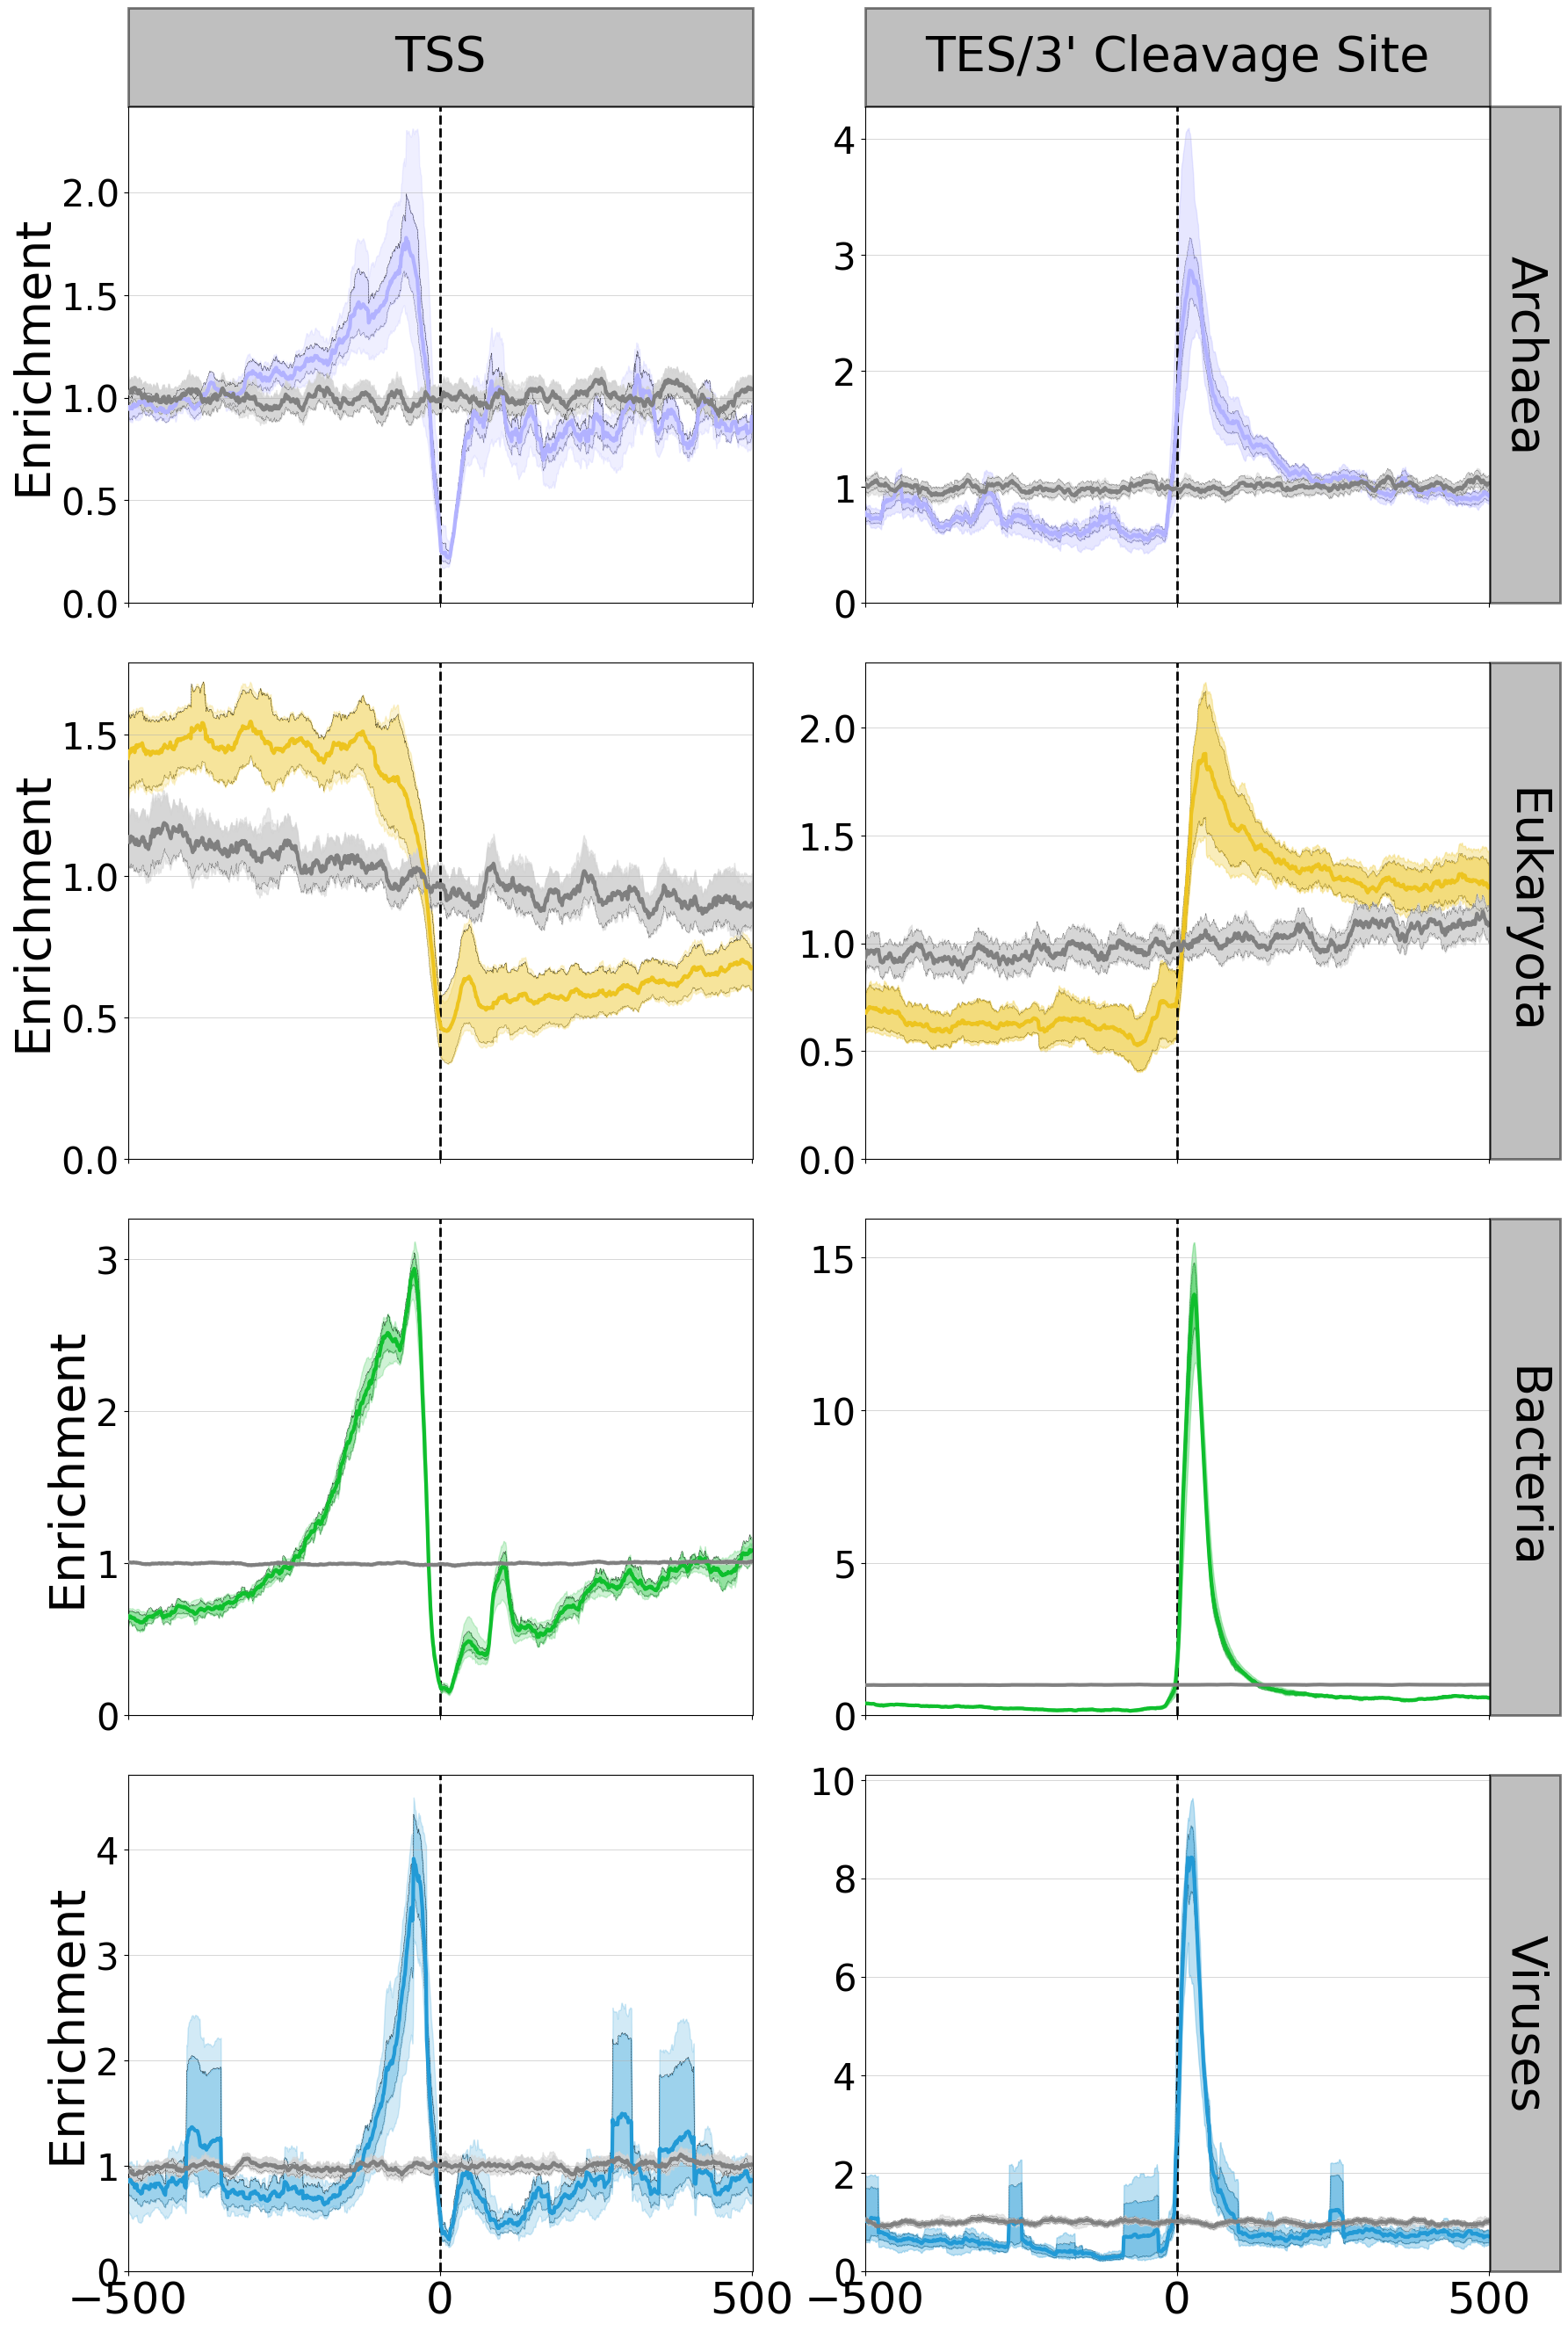

In [11]:
from matplotlib.pyplot import Rectangle
from scipy.stats import ks_2samp
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

assert density.is_dir()
kolmogorov_tests = dict()
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(20, 32))
plt.subplots_adjust(wspace=0.18, hspace=0.12)
kolmogorov_tests = dict()

# Configuration
linewidth = 3.0
window_size = 500
first_level = "species_taxid"
second_level = "family"
third_level = "order"
partition = "spacer_length" 
biotype = "."

# Plotting
density_control = Path(f"enrichment_out_{pattern}") / f"mode_{mode}_partition_{partition_col}" / "domain_bootstrap_shuffled"
density_control = Path(f"enrichment_out_{pattern}") / f"mode_{mode}_partition_{partition_col}" / "domain_bootstrap_shuffled"
density_control = Path("domain_bootstrap_shuffled2")

for idx, domain in enumerate(["Archaea", "Eukaryota", "Bacteria", "Viruses"]):
    df = pd.read_csv(density.joinpath(f"enrichment_bootstrap_alpha_0.05.{biotype}.TSS.density.domain.{domain}.csv"))\
                    .query(f"biotype == '{biotype}'")
    cols = list(map(str,range(-window_size, window_size+1)))
    tss_template = df.query(f"{partition} == 'generic'")
    
    tss_template_mean = tss_template.query(f"statistic == 'average' & bootstrap_level == '{first_level}'")[cols].values[0]
    tss_template_ci_lower = tss_template.query(f"statistic == 'lowerCI' & bootstrap_level == '{first_level}'")[cols].values[0]
    tss_template_ci_upper = tss_template.query(f"statistic == 'upperCI' & bootstrap_level == '{first_level}'")[cols].values[0]

    tss_template_ci_lower_second_layer = tss_template.query(f"statistic == 'lowerCI' & bootstrap_level == '{second_level}'")[cols].values[0]
    tss_template_ci_upper_second_layer = tss_template.query(f"statistic == 'upperCI' & bootstrap_level == '{second_level}'")[cols].values[0]
    
    # tss_template_ci_lower_third_layer = tss_template.query(f"statistic == 'lowerCI' & bootstrap_level == '{third_level}'")[cols].values[0]
    # tss_template_ci_upper_third_layer = tss_template.query(f"statistic == 'upperCI' & bootstrap_level == '{third_level}'")[cols].values[0]
    
    df = pd.read_csv(density.joinpath(f"enrichment_bootstrap_alpha_0.05.{biotype}.TES.density.domain.{domain}.csv"))\
                    .query(f"biotype == '{biotype}'")
    tes_template = df.query(f"{partition} == 'generic'")
    tes_template_mean = tes_template.query(f"statistic == 'average' & bootstrap_level == '{first_level}'")[cols].values[0]
    tes_template_ci_lower = tes_template.query(f"statistic == 'lowerCI' & bootstrap_level == '{first_level}'")[cols].values[0]
    tes_template_ci_upper = tes_template.query(f"statistic == 'upperCI' & bootstrap_level == '{first_level}'")[cols].values[0]
    
    tes_template_ci_lower_second_layer = tes_template.query(f"statistic == 'lowerCI' & bootstrap_level == '{second_level}'")[cols].values[0]
    tes_template_ci_upper_second_layer = tes_template.query(f"statistic == 'upperCI' & bootstrap_level == '{second_level}'")[cols].values[0]

    # Control
    df_control = pd.read_csv(density_control.joinpath(f"enrichment_bootstrap_alpha_0.05.{biotype}.TSS.density.domain.{domain}.csv"))\
                    .query(f"biotype == '.'")
    cols = list(map(str,range(-window_size, window_size+1)))
    tss_template_control = df_control.query(f"{partition} == 'generic'")
    
    tss_template_control_mean = tss_template_control.query(f"statistic == 'average' & bootstrap_level == '{first_level}'")[cols].values[0]
    tss_template_control_ci_lower = tss_template_control.query(f"statistic == 'lowerCI' & bootstrap_level == '{first_level}'")[cols].values[0]
    tss_template_control_ci_upper = tss_template_control.query(f"statistic == 'upperCI' & bootstrap_level == '{first_level}'")[cols].values[0]

    tss_template_control_ci_lower_second_layer = tss_template_control.query(f"statistic == 'lowerCI' & bootstrap_level == '{second_level}'")[cols].values[0]
    tss_template_control_ci_upper_second_layer = tss_template_control.query(f"statistic == 'upperCI' & bootstrap_level == '{second_level}'")[cols].values[0]
    
    # tss_template_ci_lower_third_layer = tss_template.query(f"statistic == 'lowerCI' & bootstrap_level == '{third_level}'")[cols].values[0]
    # tss_template_ci_upper_third_layer = tss_template.query(f"statistic == 'upperCI' & bootstrap_level == '{third_level}'")[cols].values[0]
    
    df_control = pd.read_csv(density_control.joinpath(f"enrichment_bootstrap_alpha_0.05.{biotype}.TES.density.domain.{domain}.csv"))\
                    .query(f"biotype == '{biotype}'")
    tes_template_control = df_control.query(f"{partition} == 'generic'")
    tes_template_control_mean = tes_template_control.query(f"statistic == 'average' & bootstrap_level == '{first_level}'")[cols].values[0]
    tes_template_control_ci_lower = tes_template_control.query(f"statistic == 'lowerCI' & bootstrap_level == '{first_level}'")[cols].values[0]
    tes_template_control_ci_upper = tes_template_control.query(f"statistic == 'upperCI' & bootstrap_level == '{first_level}'")[cols].values[0]
    
    tes_template_control_ci_lower_second_layer = tes_template_control.query(f"statistic == 'lowerCI' & bootstrap_level == '{second_level}'")[cols].values[0]
    tes_template_control_ci_upper_second_layer = tes_template_control.query(f"statistic == 'upperCI' & bootstrap_level == '{second_level}'")[cols].values[0]
    
    # kolmogorov_test_TSS = ks_2samp(tss_template_mean, tss_non_template_mean)
    # kolmogorov_test_TES = ks_2samp(tes_template_mean, tes_non_template_mean)
    # kolmogorov_tests[domain, "TSS"] = kolmogorov_test_TSS
    # kolmogorov_tests[domain, "TES"] = kolmogorov_test_TES
    
    # TES
    xaxis = range(-window_size, window_size+1)
    ax[idx][0].plot(xaxis, 
            tss_template_mean, 
            color=color_templates['template'][domain], 
            lw=linewidth, 
            zorder=3)
    ax[idx][0].fill_between(xaxis, 
                        y1=tss_template_ci_lower, 
                        y2=tss_template_ci_upper,
                        color=color_templates['template'][domain], 
                        alpha=0.3
                    )
    ax[idx][0].plot(xaxis,
                    tss_template_ci_lower,
                    color='black',
                    lw=0.2,
                    linestyle='--'
                   )
    ax[idx][0].plot(xaxis,
                    tss_template_ci_upper,
                    color='black',
                    lw=0.2,
                    linestyle='--'
                   )
    ax[idx][0].fill_between(xaxis, 
                        y1=tss_template_ci_lower_second_layer, 
                        y2=tss_template_ci_upper_second_layer,
                        color=color_templates['template'][domain], 
                        alpha=0.2
                    )
    # TSS Control
    ax[idx][0].plot(xaxis, 
            tss_template_control_mean, 
            color="gray",
 
            lw=linewidth, 
            zorder=3)
    ax[idx][0].fill_between(xaxis, 
                        y1=tss_template_control_ci_lower, 
                        y2=tss_template_control_ci_upper,
                        color="lightgray", 
                        alpha=0.8
                    )
    ax[idx][0].plot(xaxis,
                    tss_template_control_ci_lower,
                    color='black',
                    lw=0.2,
                    linestyle='--'
                   )
    ax[idx][0].plot(xaxis,
                    tss_template_ci_upper,
                    color='black',
                    lw=0.2,
                    linestyle='--'
                   )
    ax[idx][0].fill_between(xaxis, 
                        y1=tss_template_control_ci_lower_second_layer, 
                        y2=tss_template_control_ci_upper_second_layer,
                        color="lightgray", 
                        alpha=0.5
                    )

    # TES
    ax[idx][1].plot(xaxis, 
            tes_template_mean, 
            color=color_templates['template'][domain], 
            lw=linewidth, 
            zorder=3)
    ax[idx][1].fill_between(xaxis, 
                        y1=tes_template_ci_lower, 
                        y2=tes_template_ci_upper,
                        color=color_templates['template'][domain], 
                        alpha=0.4
                    )
    ax[idx][1].plot(xaxis,
                    tes_template_ci_lower,
                    color='black',
                    lw=0.2,
                    linestyle='--'
                   )
    ax[idx][1].plot(xaxis,
                    tes_template_ci_upper,
                    color='black',
                    lw=0.2,
                    linestyle='--'
                   )
    ax[idx][1].fill_between(xaxis, 
                        y1=tes_template_ci_lower_second_layer, 
                        y2=tes_template_ci_upper_second_layer,
                        color=color_templates['template'][domain], 
                        alpha=0.3
                    )
    # TES Control
    ax[idx][1].plot(xaxis, 
            tes_template_control_mean, 
            color="gray", 
            lw=linewidth, 
            zorder=3)
    ax[idx][1].fill_between(xaxis, 
                        y1=tes_template_control_ci_lower, 
                        y2=tes_template_control_ci_upper,
                        color="lightgray", 
                        alpha=0.8
                    )
    ax[idx][1].plot(xaxis,
                    tes_template_control_ci_lower,
                    color='black',
                    lw=0.2,
                    linestyle='--'
                   )
    ax[idx][1].plot(xaxis,
                    tes_template_control_ci_upper,
                    color='black',
                    lw=0.2,
                    linestyle='--'
                   )
    ax[idx][1].fill_between(xaxis, 
                        y1=tes_template_control_ci_lower_second_layer, 
                        y2=tes_template_control_ci_upper_second_layer,
                        color="lightgray", 
                        alpha=0.5
                    )
    # ax.legend(handles=[mpatches.Patch(color=color_templates['template'][domain], label='Template'),
    #                   mpatches.Patch(color=color_templates['non-template'][domain], label='Non-template')
    #                  ], loc=0
    #         )
    
    def _modify_axis(ax, transcription_site):
        # xticks = ax.get_xticks()
        # ax.set_xticks(range(0, len(xticks), 100))
        if transcription_site == "start":
            # ax.set_ylabel("")
            ax.set_ylabel("Enrichment")
        else:
            ax.set_ylabel("")
    
        ax.set_ylim(ymin=0)
        ax.set_xlim(xmin=-window_size, xmax=window_size+1)
        ax.yaxis.label.set_size(40)
        ax.xaxis.label.set_size(34)
        ax.tick_params(axis="both", which="major", labelsize=30)
        ax.tick_params(axis="x", which="major", labelsize=36)
        if idx != 3:
            ax.set_xticklabels([])
        ax.grid(True, which='both', axis='x') 
        ax.grid(axis="both", lw=0.4, alpha=0.6, zorder=0)
        ax.grid(axis="both", lw=0.6, alpha=0.6, zorder=0)
        ax.axvline(0, linestyle='--', color='black', lw=2.0)
        # ax.axhline(1.0, linestyle='--', color='crimson', lw=2.5, zorder=5)
        return ax
    
    ax[idx][0] = _modify_axis(ax[idx][0], transcription_site="start")
    ax[idx][1] = _modify_axis(ax[idx][1], transcription_site="end")
    
    fig.canvas.draw()
    sites = ["TSS", "TES/3' Cleavage Site"]
    for i, site in zip(range(2), sites):
        if idx == 0:
            bbox = ax[idx][i].get_position()
            rect_height = 0.035 # Height of the rectangle relative to figure
            rect_bottom = bbox.y1  # Bottom of the rectangle aligns with the top of the subplot
            rect_left = bbox.x0  # Left aligns with the subplot
            rect_width = bbox.x1 - bbox.x0  # Width matches the subplot
            
            fig.patches.append(Rectangle((rect_left, rect_bottom), rect_width, rect_height,
                                         edgecolor="black",
                                         linewidth=2.0,
                                         transform=fig.transFigure, facecolor='gray', alpha=0.5))
            
            # Add title text
            fig.text(rect_left + rect_width / 2, 
                     rect_bottom + rect_height / 2, 
                     # title=site, 
                     s=site,
                     ha='center', 
                     va='center', 
                     color='black', 
                     fontsize=40
                    )
        if i == 1:
            bbox = ax[idx][i].get_position()
            rect_width = 0.04 
            rect_left = bbox.x1  
            rect_height = bbox.y1 - bbox.y0
            rect_bottom = bbox.y0 
    
            fig.patches.append(Rectangle((rect_left, rect_bottom), 
                                         rect_width, rect_height,
                                         edgecolor="black",
                                         linewidth=2.0,
                                         transform=fig.transFigure, facecolor='gray', alpha=0.5))
            
            # Add title text
            fig.text(rect_left + rect_width / 2, 
                     rect_bottom + rect_height / 2, 
                     s=domain,
                     ha='center', 
                     va='center', 
                     color='black',
                     rotation=270,
                     fontsize=40
                     )
    
target = Path(f"{pattern}_figures").joinpath("TSS_TES")
target.mkdir(exist_ok=True, parents=True)
fig.savefig(f"{target}/{pattern}_TSS_TES_distribution_domains_controls_local_controls_1kb.pdf", dpi=600, transparent=True, bbox_inches="tight")

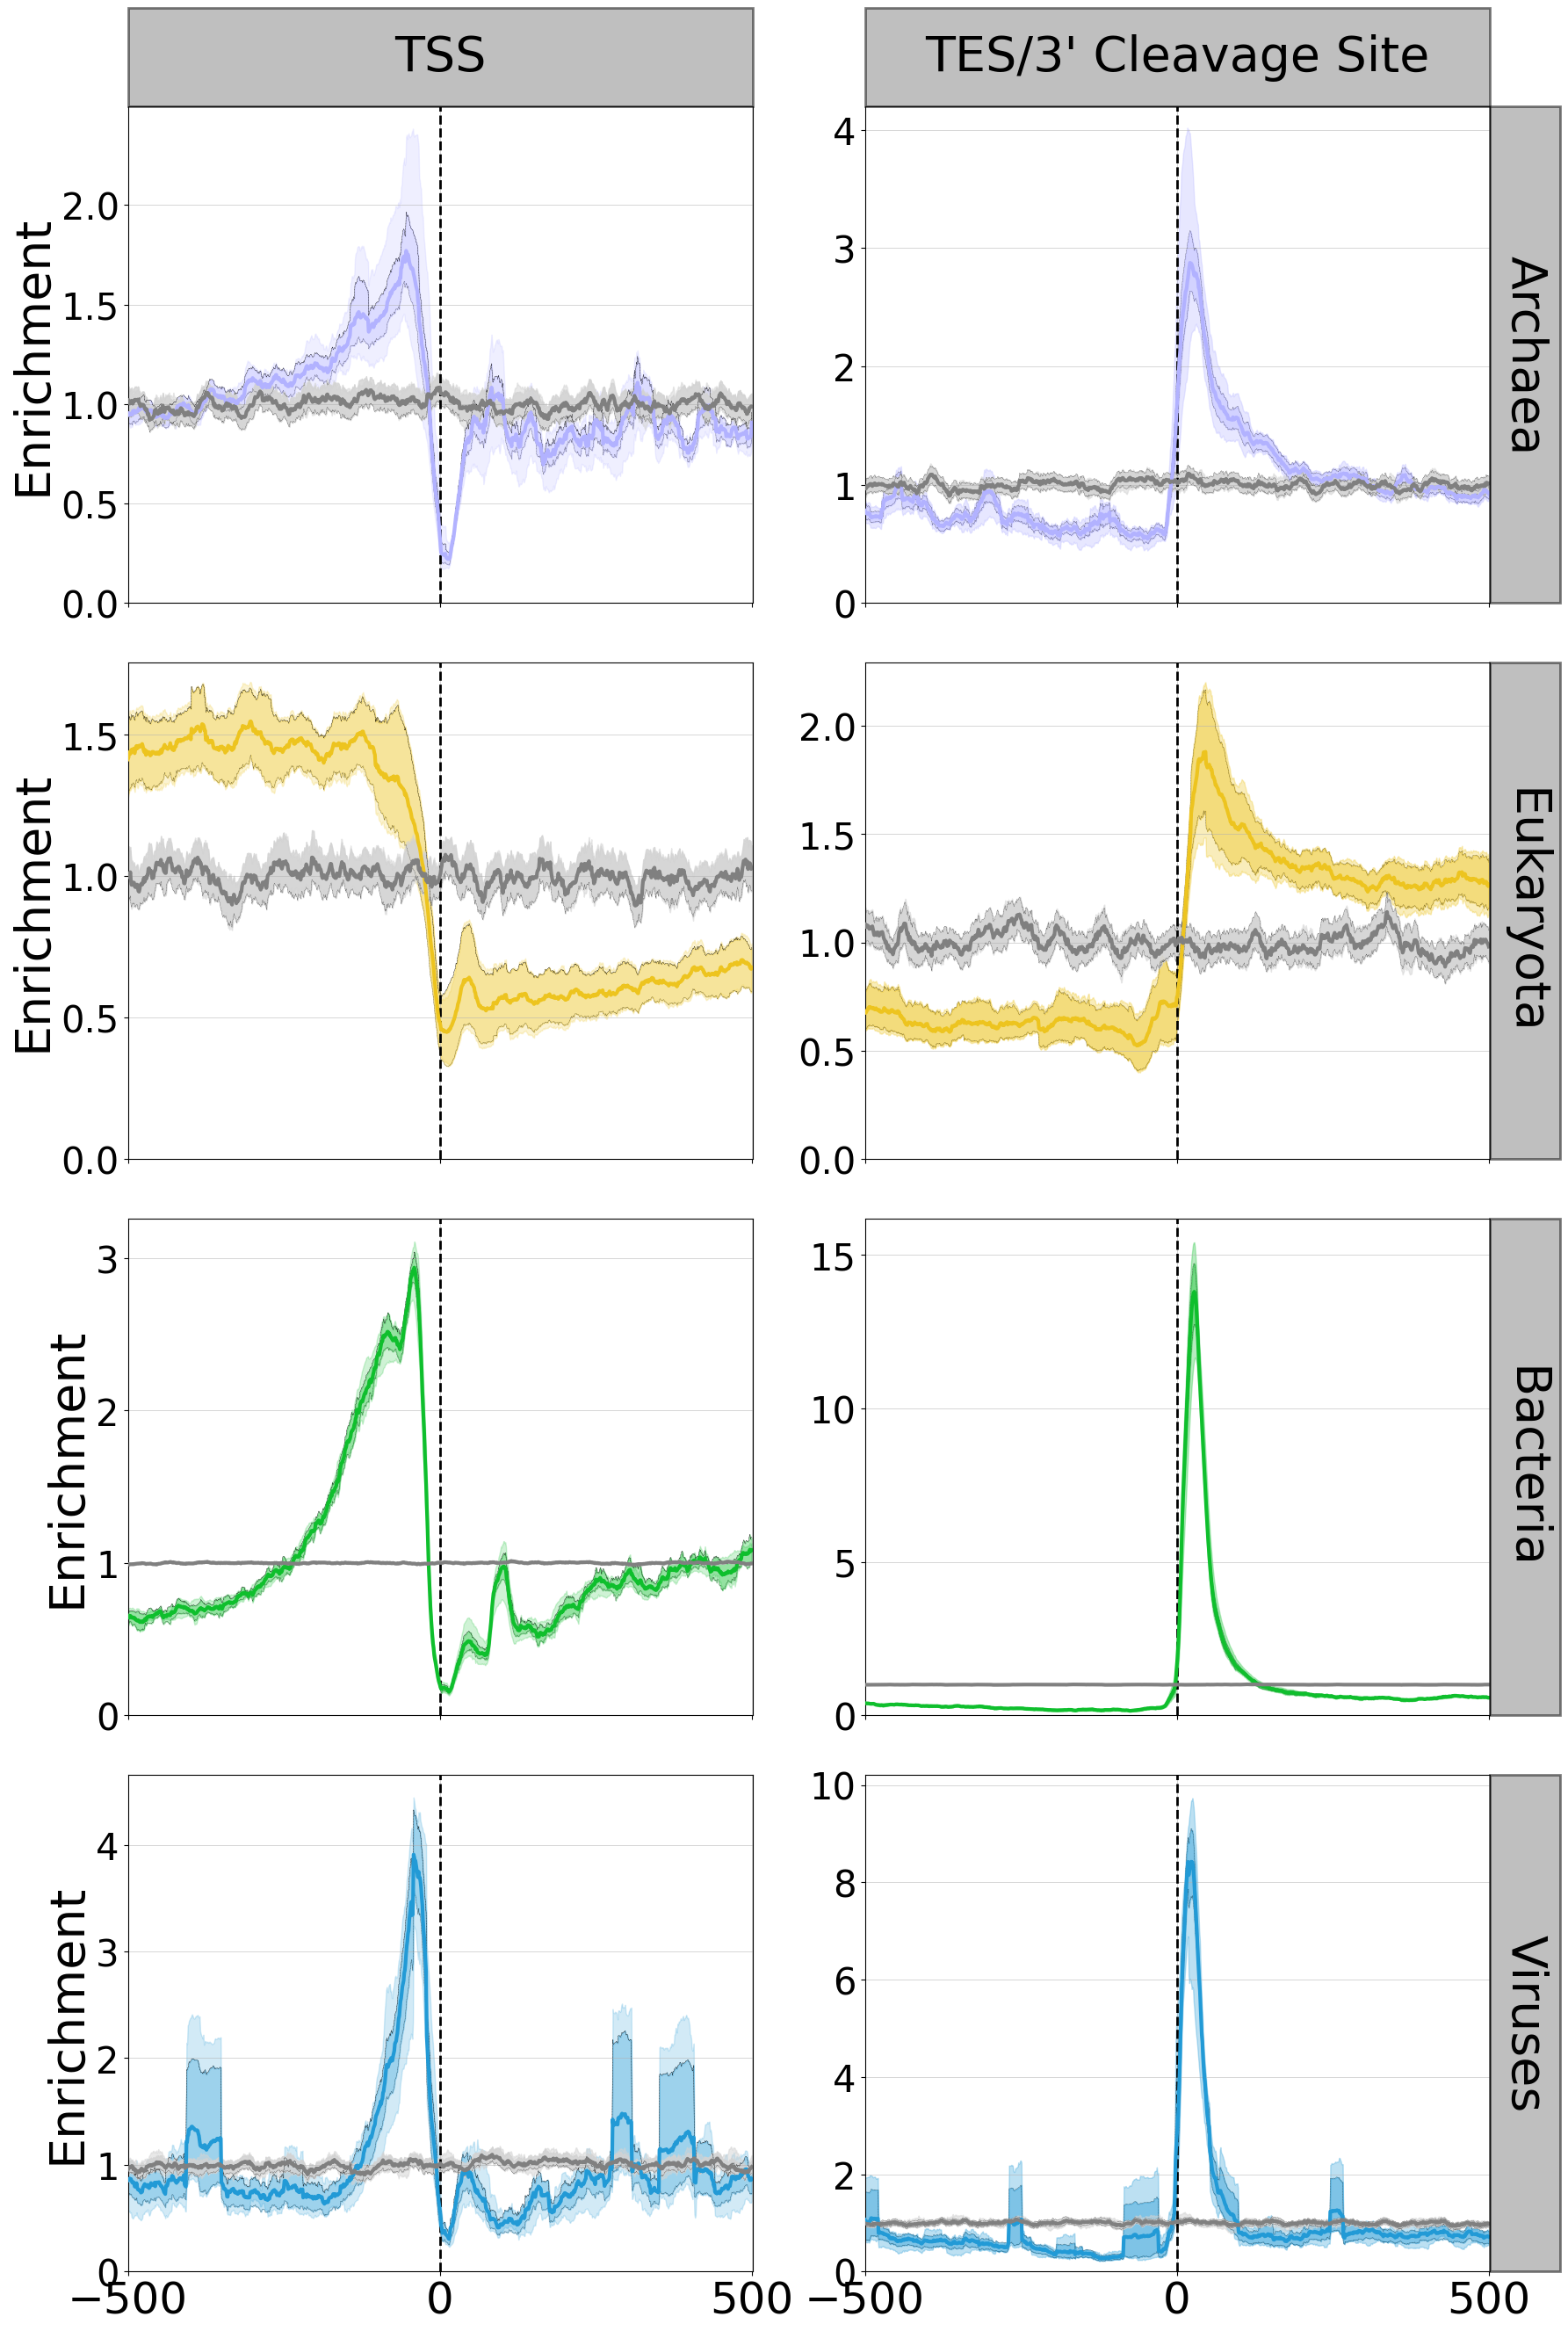

In [ ]:
from matplotlib.pyplot import Rectangle
from scipy.stats import ks_2samp
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

assert density.is_dir()
kolmogorov_tests = dict()
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(20, 32))
plt.subplots_adjust(wspace=0.18, hspace=0.12)
kolmogorov_tests = dict()

# Configuration
linewidth = 3.0
window_size = 500
first_level = "species_taxid"
second_level = "family"
third_level = "order"
partition = "spacer_length" 
biotype = "."

# Plotting
density_control = Path(f"enrichment_out_{pattern}") / f"mode_{mode}_partition_{partition_col}" / "domain_bootstrap_shuffled"
density_control = "domain_bootstrap_shuffled"

for idx, domain in enumerate(["Archaea", "Eukaryota", "Bacteria", "Viruses"]):
    df = pd.read_csv(density.joinpath(f"enrichment_bootstrap_alpha_0.05.{biotype}.TSS.density.domain.{domain}.csv"))\
                    .query(f"biotype == '{biotype}'")
    cols = list(map(str,range(-window_size, window_size+1)))
    tss_template = df.query(f"{partition} == 'generic'")
    
    tss_template_mean = tss_template.query(f"statistic == 'average' & bootstrap_level == '{first_level}'")[cols].values[0]
    tss_template_ci_lower = tss_template.query(f"statistic == 'lowerCI' & bootstrap_level == '{first_level}'")[cols].values[0]
    tss_template_ci_upper = tss_template.query(f"statistic == 'upperCI' & bootstrap_level == '{first_level}'")[cols].values[0]

    tss_template_ci_lower_second_layer = tss_template.query(f"statistic == 'lowerCI' & bootstrap_level == '{second_level}'")[cols].values[0]
    tss_template_ci_upper_second_layer = tss_template.query(f"statistic == 'upperCI' & bootstrap_level == '{second_level}'")[cols].values[0]
    
    # tss_template_ci_lower_third_layer = tss_template.query(f"statistic == 'lowerCI' & bootstrap_level == '{third_level}'")[cols].values[0]
    # tss_template_ci_upper_third_layer = tss_template.query(f"statistic == 'upperCI' & bootstrap_level == '{third_level}'")[cols].values[0]
    
    df = pd.read_csv(density.joinpath(f"enrichment_bootstrap_alpha_0.05.TES.density.domain.{domain}.csv"))\
                    .query(f"biotype == '.'")
    tes_template = df.query(f"{partition} == 'generic'")
    tes_template_mean = tes_template.query(f"statistic == 'average' & bootstrap_level == '{first_level}'")[cols].values[0]
    tes_template_ci_lower = tes_template.query(f"statistic == 'lowerCI' & bootstrap_level == '{first_level}'")[cols].values[0]
    tes_template_ci_upper = tes_template.query(f"statistic == 'upperCI' & bootstrap_level == '{first_level}'")[cols].values[0]
    
    tes_template_ci_lower_second_layer = tes_template.query(f"statistic == 'lowerCI' & bootstrap_level == '{second_level}'")[cols].values[0]
    tes_template_ci_upper_second_layer = tes_template.query(f"statistic == 'upperCI' & bootstrap_level == '{second_level}'")[cols].values[0]

    # Control
    df_control = pd.read_csv(density_control.joinpath(f"enrichment_bootstrap_alpha_0.05.TSS.density.domain.{domain}.csv"))\
                    .query(f"biotype == '.'")
    cols = list(map(str,range(-window_size, window_size+1)))
    tss_template_control = df_control.query(f"{partition} == 'generic'")
    
    tss_template_control_mean = tss_template_control.query(f"statistic == 'average' & bootstrap_level == '{first_level}'")[cols].values[0]
    tss_template_control_ci_lower = tss_template_control.query(f"statistic == 'lowerCI' & bootstrap_level == '{first_level}'")[cols].values[0]
    tss_template_control_ci_upper = tss_template_control.query(f"statistic == 'upperCI' & bootstrap_level == '{first_level}'")[cols].values[0]

    tss_template_control_ci_lower_second_layer = tss_template_control.query(f"statistic == 'lowerCI' & bootstrap_level == '{second_level}'")[cols].values[0]
    tss_template_control_ci_upper_second_layer = tss_template_control.query(f"statistic == 'upperCI' & bootstrap_level == '{second_level}'")[cols].values[0]
    
    # tss_template_ci_lower_third_layer = tss_template.query(f"statistic == 'lowerCI' & bootstrap_level == '{third_level}'")[cols].values[0]
    # tss_template_ci_upper_third_layer = tss_template.query(f"statistic == 'upperCI' & bootstrap_level == '{third_level}'")[cols].values[0]
    
    df_control = pd.read_csv(density_control.joinpath(f"enrichment_bootstrap_alpha_0.05.TES.density.domain.{domain}.csv"))\
                    .query(f"biotype == '.'")
    tes_template_control = df_control.query(f"{partition} == 'generic'")
    tes_template_control_mean = tes_template_control.query(f"statistic == 'average' & bootstrap_level == '{first_level}'")[cols].values[0]
    tes_template_control_ci_lower = tes_template_control.query(f"statistic == 'lowerCI' & bootstrap_level == '{first_level}'")[cols].values[0]
    tes_template_control_ci_upper = tes_template_control.query(f"statistic == 'upperCI' & bootstrap_level == '{first_level}'")[cols].values[0]
    
    tes_template_control_ci_lower_second_layer = tes_template_control.query(f"statistic == 'lowerCI' & bootstrap_level == '{second_level}'")[cols].values[0]
    tes_template_control_ci_upper_second_layer = tes_template_control.query(f"statistic == 'upperCI' & bootstrap_level == '{second_level}'")[cols].values[0]
    
    # kolmogorov_test_TSS = ks_2samp(tss_template_mean, tss_non_template_mean)
    # kolmogorov_test_TES = ks_2samp(tes_template_mean, tes_non_template_mean)
    # kolmogorov_tests[domain, "TSS"] = kolmogorov_test_TSS
    # kolmogorov_tests[domain, "TES"] = kolmogorov_test_TES
    
    # TES
    xaxis = range(-window_size, window_size+1)
    ax[idx][0].plot(xaxis, 
            tss_template_mean, 
            color=color_templates['template'][domain], 
            lw=linewidth, 
            zorder=3)
    ax[idx][0].fill_between(xaxis, 
                        y1=tss_template_ci_lower, 
                        y2=tss_template_ci_upper,
                        color=color_templates['template'][domain], 
                        alpha=0.3
                    )
    ax[idx][0].plot(xaxis,
                    tss_template_ci_lower,
                    color='black',
                    lw=0.2,
                    linestyle='--'
                   )
    ax[idx][0].plot(xaxis,
                    tss_template_ci_upper,
                    color='black',
                    lw=0.2,
                    linestyle='--'
                   )
    ax[idx][0].fill_between(xaxis, 
                        y1=tss_template_ci_lower_second_layer, 
                        y2=tss_template_ci_upper_second_layer,
                        color=color_templates['template'][domain], 
                        alpha=0.2
                    )
    # TSS Control
    ax[idx][0].plot(xaxis, 
            tss_template_control_mean, 
            color="gray",
 
            lw=linewidth, 
            zorder=3)
    ax[idx][0].fill_between(xaxis, 
                        y1=tss_template_control_ci_lower, 
                        y2=tss_template_control_ci_upper,
                        color="lightgray", 
                        alpha=0.8
                    )
    ax[idx][0].plot(xaxis,
                    tss_template_control_ci_lower,
                    color='black',
                    lw=0.2,
                    linestyle='--'
                   )
    ax[idx][0].plot(xaxis,
                    tss_template_ci_upper,
                    color='black',
                    lw=0.2,
                    linestyle='--'
                   )
    ax[idx][0].fill_between(xaxis, 
                        y1=tss_template_control_ci_lower_second_layer, 
                        y2=tss_template_control_ci_upper_second_layer,
                        color="lightgray", 
                        alpha=0.5
                    )

    # TES
    ax[idx][1].plot(xaxis, 
            tes_template_mean, 
            color=color_templates['template'][domain], 
            lw=linewidth, 
            zorder=3)
    ax[idx][1].fill_between(xaxis, 
                        y1=tes_template_ci_lower, 
                        y2=tes_template_ci_upper,
                        color=color_templates['template'][domain], 
                        alpha=0.4
                    )
    ax[idx][1].plot(xaxis,
                    tes_template_ci_lower,
                    color='black',
                    lw=0.2,
                    linestyle='--'
                   )
    ax[idx][1].plot(xaxis,
                    tes_template_ci_upper,
                    color='black',
                    lw=0.2,
                    linestyle='--'
                   )
    ax[idx][1].fill_between(xaxis, 
                        y1=tes_template_ci_lower_second_layer, 
                        y2=tes_template_ci_upper_second_layer,
                        color=color_templates['template'][domain], 
                        alpha=0.3
                    )
    # TES Control
    ax[idx][1].plot(xaxis, 
            tes_template_control_mean, 
            color="gray", 
            lw=linewidth, 
            zorder=3)
    ax[idx][1].fill_between(xaxis, 
                        y1=tes_template_control_ci_lower, 
                        y2=tes_template_control_ci_upper,
                        color="lightgray", 
                        alpha=0.8
                    )
    ax[idx][1].plot(xaxis,
                    tes_template_control_ci_lower,
                    color='black',
                    lw=0.2,
                    linestyle='--'
                   )
    ax[idx][1].plot(xaxis,
                    tes_template_control_ci_upper,
                    color='black',
                    lw=0.2,
                    linestyle='--'
                   )
    ax[idx][1].fill_between(xaxis, 
                        y1=tes_template_control_ci_lower_second_layer, 
                        y2=tes_template_control_ci_upper_second_layer,
                        color="lightgray", 
                        alpha=0.5
                    )
    # ax.legend(handles=[mpatches.Patch(color=color_templates['template'][domain], label='Template'),
    #                   mpatches.Patch(color=color_templates['non-template'][domain], label='Non-template')
    #                  ], loc=0
    #         )
    
    def _modify_axis(ax, transcription_site):
        # xticks = ax.get_xticks()
        # ax.set_xticks(range(0, len(xticks), 100))
        if transcription_site == "start":
            # ax.set_ylabel("")
            ax.set_ylabel("Enrichment")
        else:
            ax.set_ylabel("")
    
        ax.set_ylim(ymin=0)
        ax.set_xlim(xmin=-window_size, xmax=window_size+1)
        ax.yaxis.label.set_size(40)
        ax.xaxis.label.set_size(34)
        ax.tick_params(axis="both", which="major", labelsize=30)
        ax.tick_params(axis="x", which="major", labelsize=36)
        if idx != 3:
            ax.set_xticklabels([])
        ax.grid(True, which='both', axis='x') 
        ax.grid(axis="both", lw=0.4, alpha=0.6, zorder=0)
        ax.grid(axis="both", lw=0.6, alpha=0.6, zorder=0)
        ax.axvline(0, linestyle='--', color='black', lw=2.0)
        # ax.axhline(1.0, linestyle='--', color='crimson', lw=2.5, zorder=5)
        return ax
    
    ax[idx][0] = _modify_axis(ax[idx][0], transcription_site="start")
    ax[idx][1] = _modify_axis(ax[idx][1], transcription_site="end")
    
    fig.canvas.draw()
    sites = ["TSS", "TES/3' Cleavage Site"]
    for i, site in zip(range(2), sites):
        if idx == 0:
            bbox = ax[idx][i].get_position()
            rect_height = 0.035 # Height of the rectangle relative to figure
            rect_bottom = bbox.y1  # Bottom of the rectangle aligns with the top of the subplot
            rect_left = bbox.x0  # Left aligns with the subplot
            rect_width = bbox.x1 - bbox.x0  # Width matches the subplot
            
            fig.patches.append(Rectangle((rect_left, rect_bottom), rect_width, rect_height,
                                         edgecolor="black",
                                         linewidth=2.0,
                                         transform=fig.transFigure, facecolor='gray', alpha=0.5))
            
            # Add title text
            fig.text(rect_left + rect_width / 2, 
                     rect_bottom + rect_height / 2, 
                     # title=site, 
                     s=site,
                     ha='center', 
                     va='center', 
                     color='black', 
                     fontsize=40
                    )
        if i == 1:
            bbox = ax[idx][i].get_position()
            rect_width = 0.04 
            rect_left = bbox.x1  
            rect_height = bbox.y1 - bbox.y0
            rect_bottom = bbox.y0 
    
            fig.patches.append(Rectangle((rect_left, rect_bottom), 
                                         rect_width, rect_height,
                                         edgecolor="black",
                                         linewidth=2.0,
                                         transform=fig.transFigure, facecolor='gray', alpha=0.5))
            
            # Add title text
            fig.text(rect_left + rect_width / 2, 
                     rect_bottom + rect_height / 2, 
                     s=domain,
                     ha='center', 
                     va='center', 
                     color='black',
                     rotation=270,
                     fontsize=40
                     )
    
target = Path(f"{pattern}_figures").joinpath("TSS_TES")
target.mkdir(exist_ok=True, parents=True)
fig.savefig(f"{target}/{pattern}_TSS_TES_distribution_domains_controls.pdf", dpi=600, transparent=True, bbox_inches="tight")

## Densities in Phylums

In [33]:
phylums = set(tree_of_life["phylum"])
phylum_to_domain = dict(zip(tree_of_life["phylum"], tree_of_life["domain"]))
len(phylums)

129

In [34]:
phylum_to_domain = dict(zip(tree_of_life["phylum"], tree_of_life["domain"]))

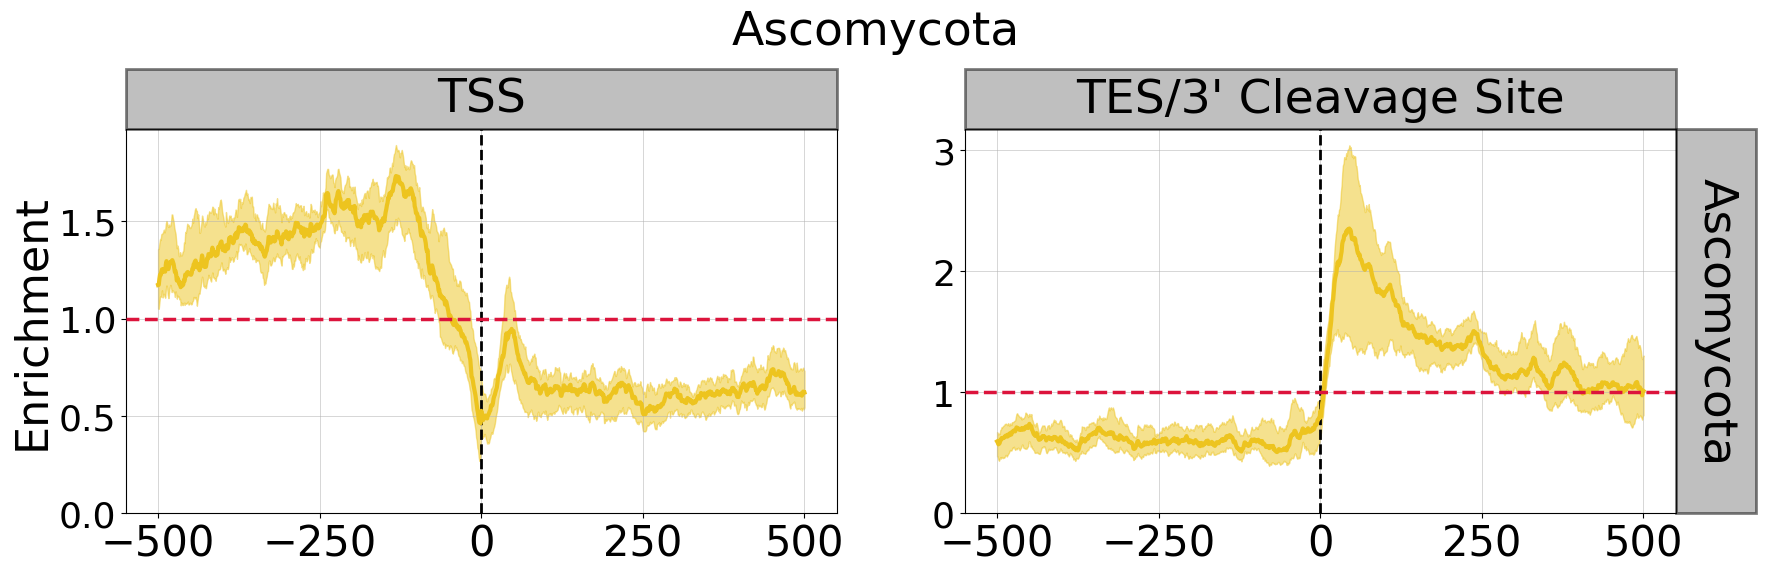

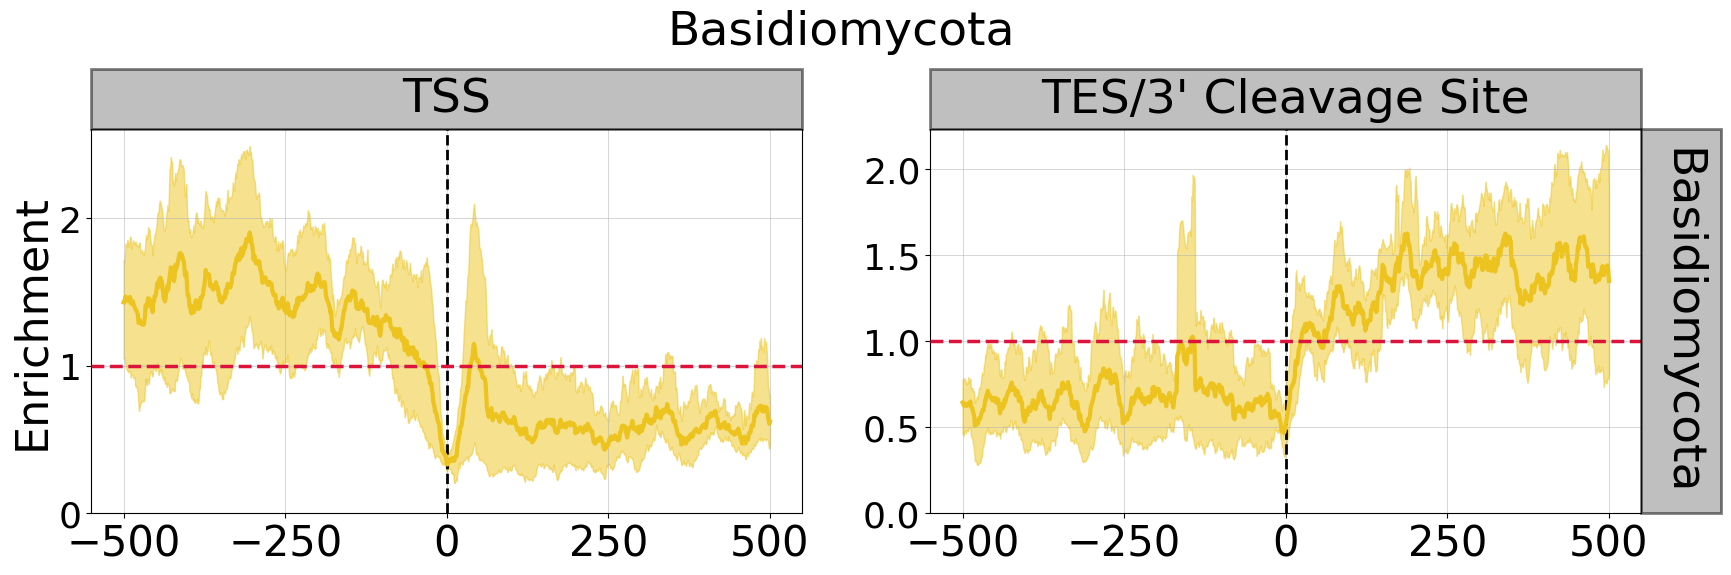

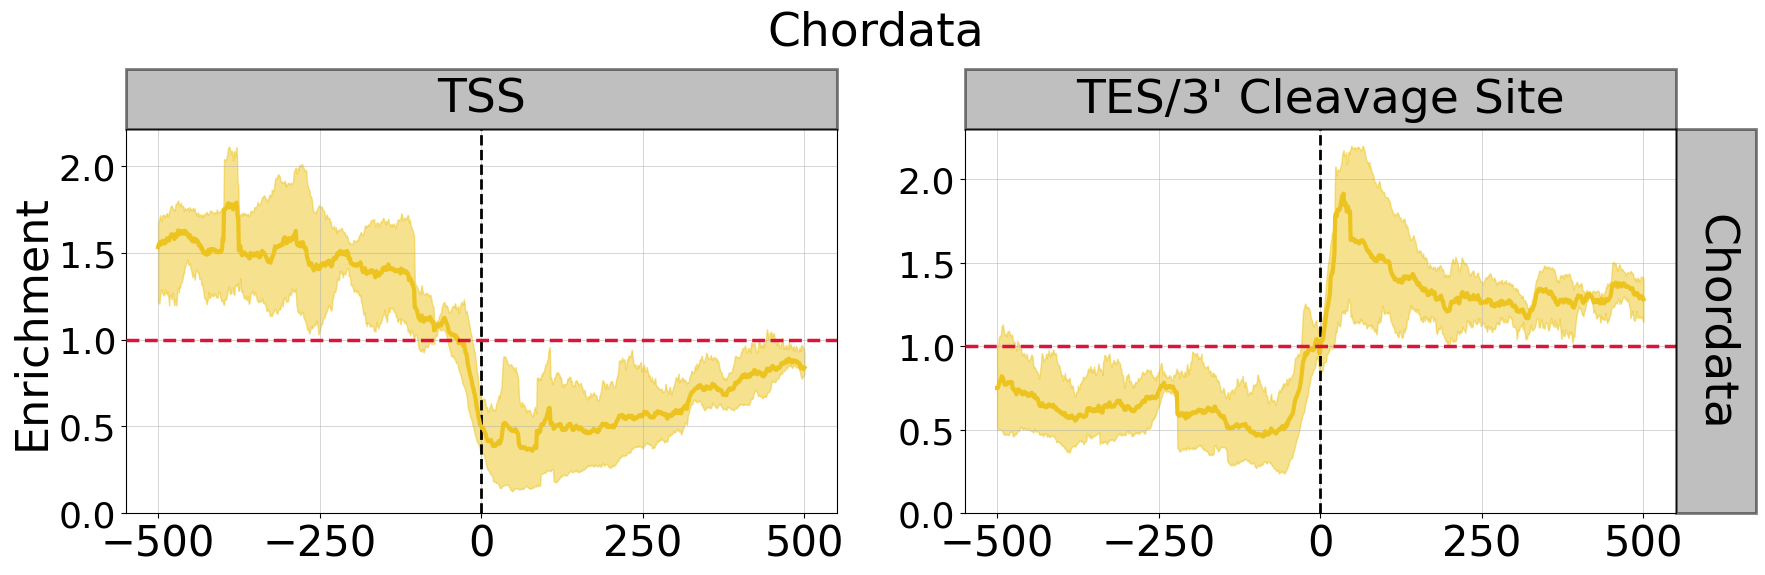

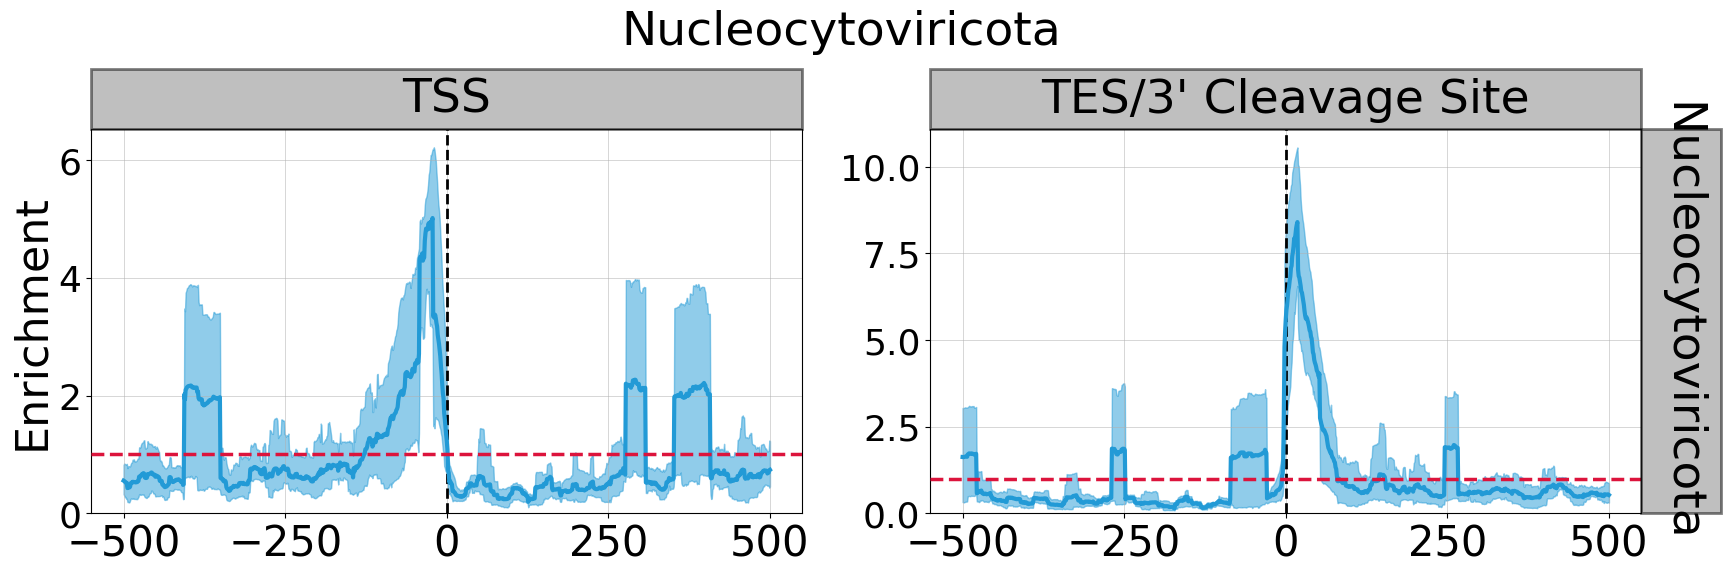

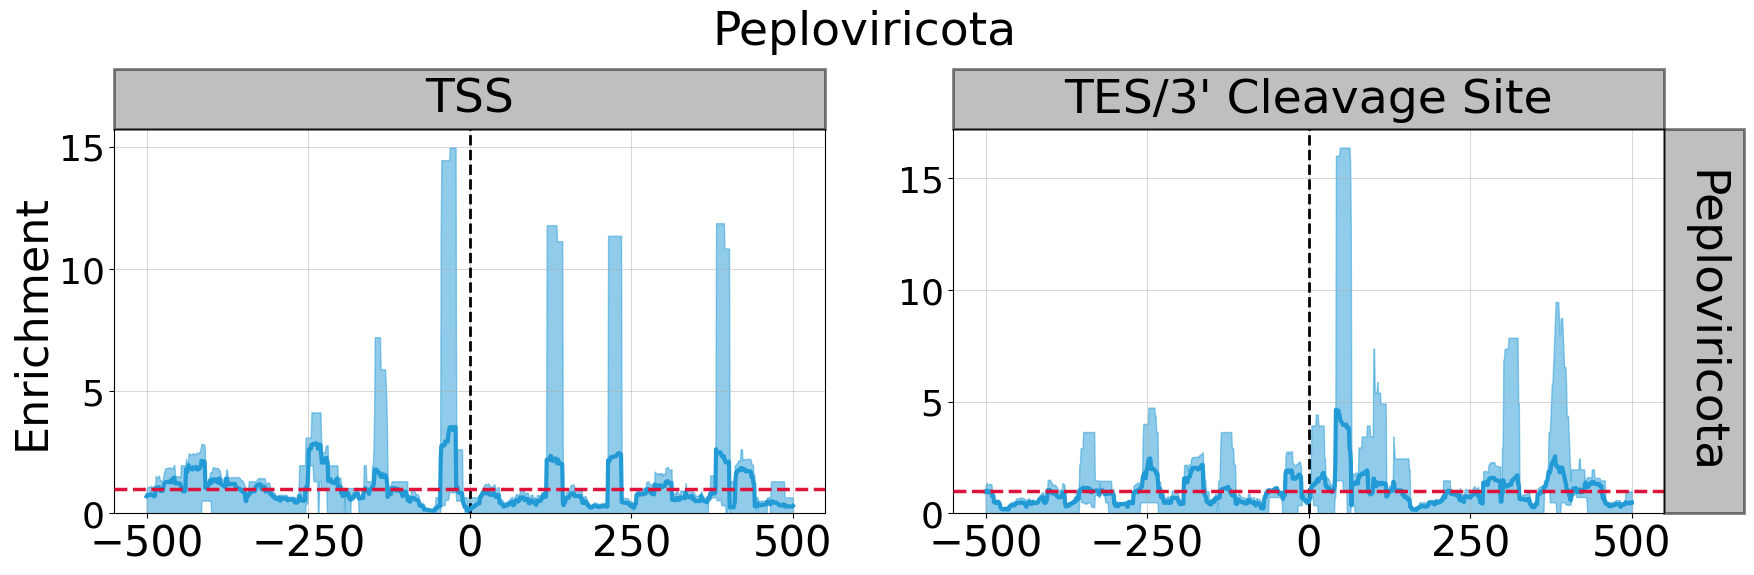

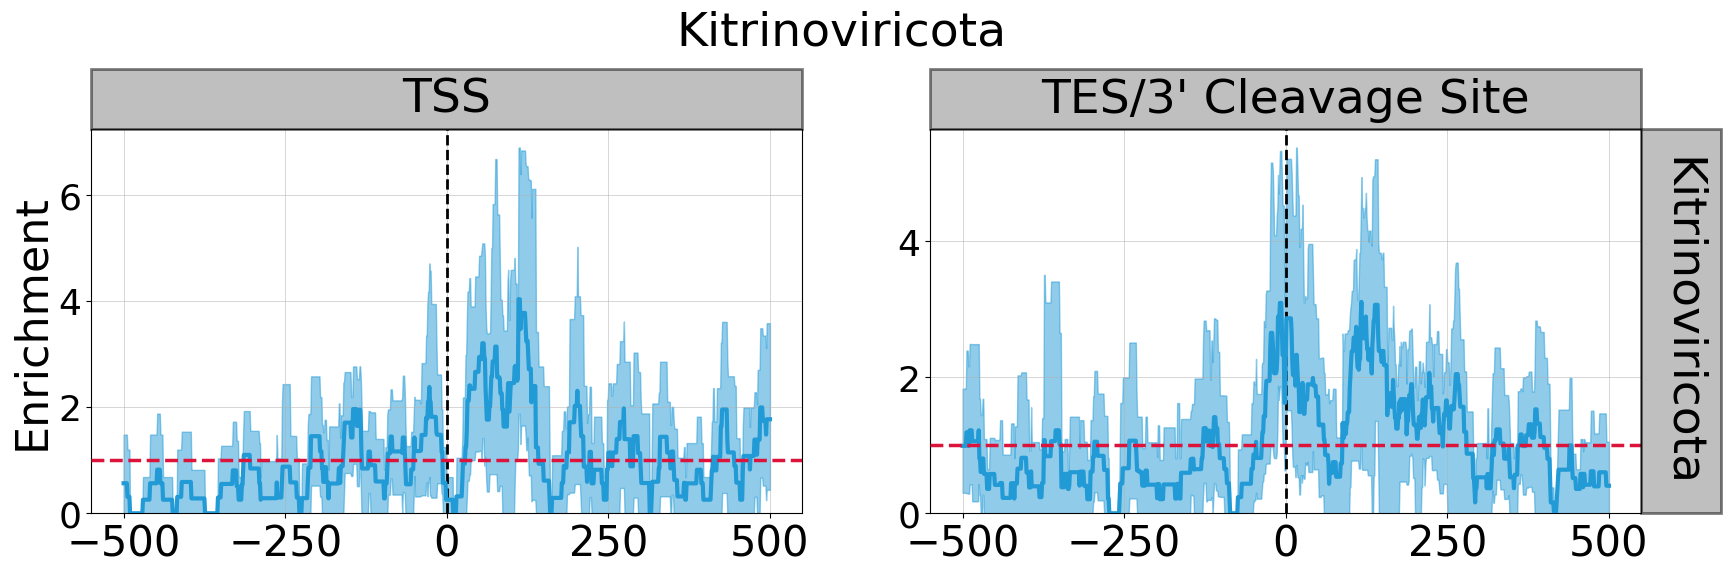

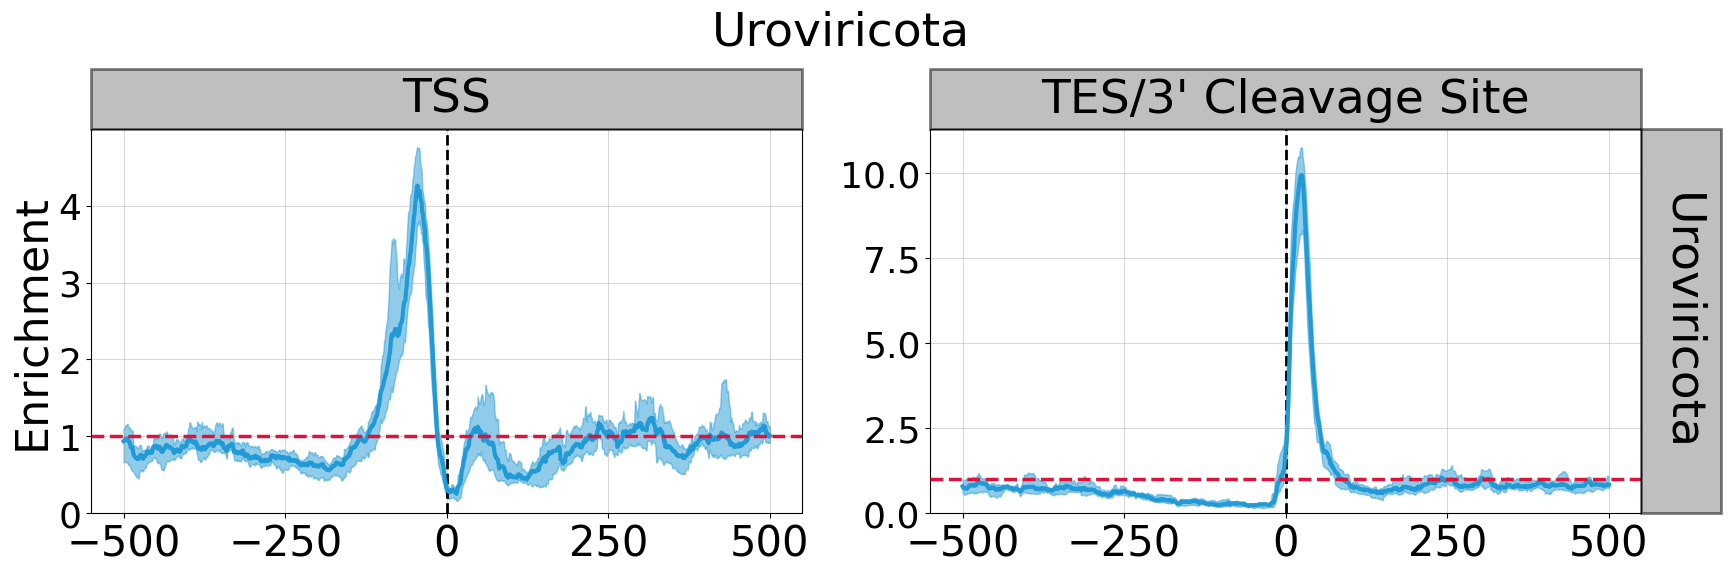

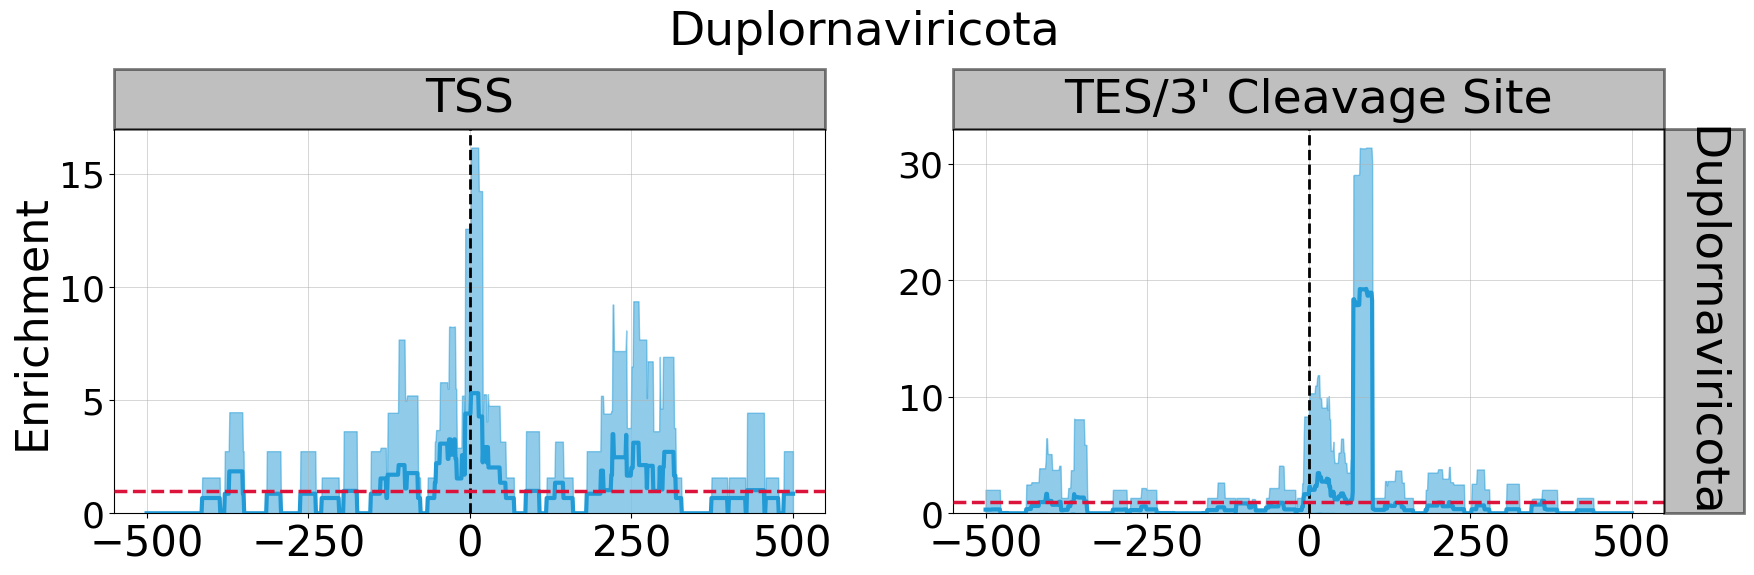

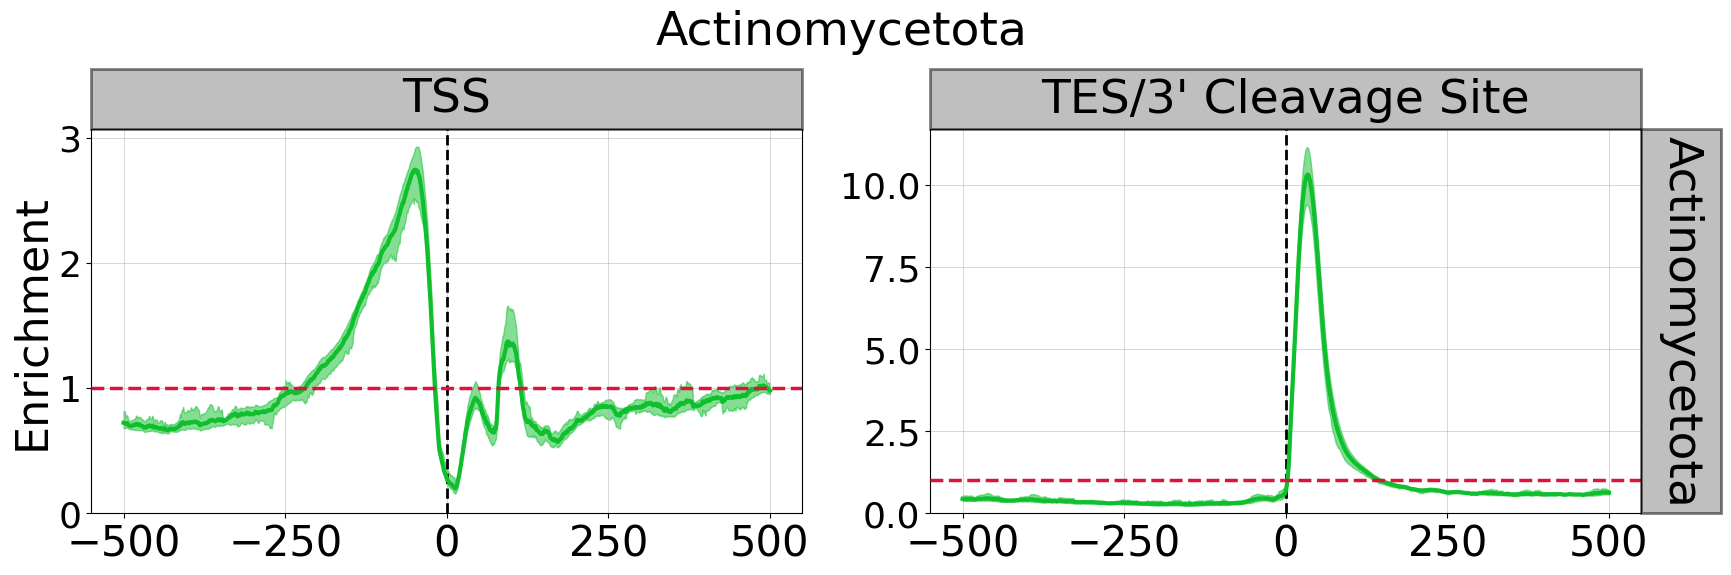

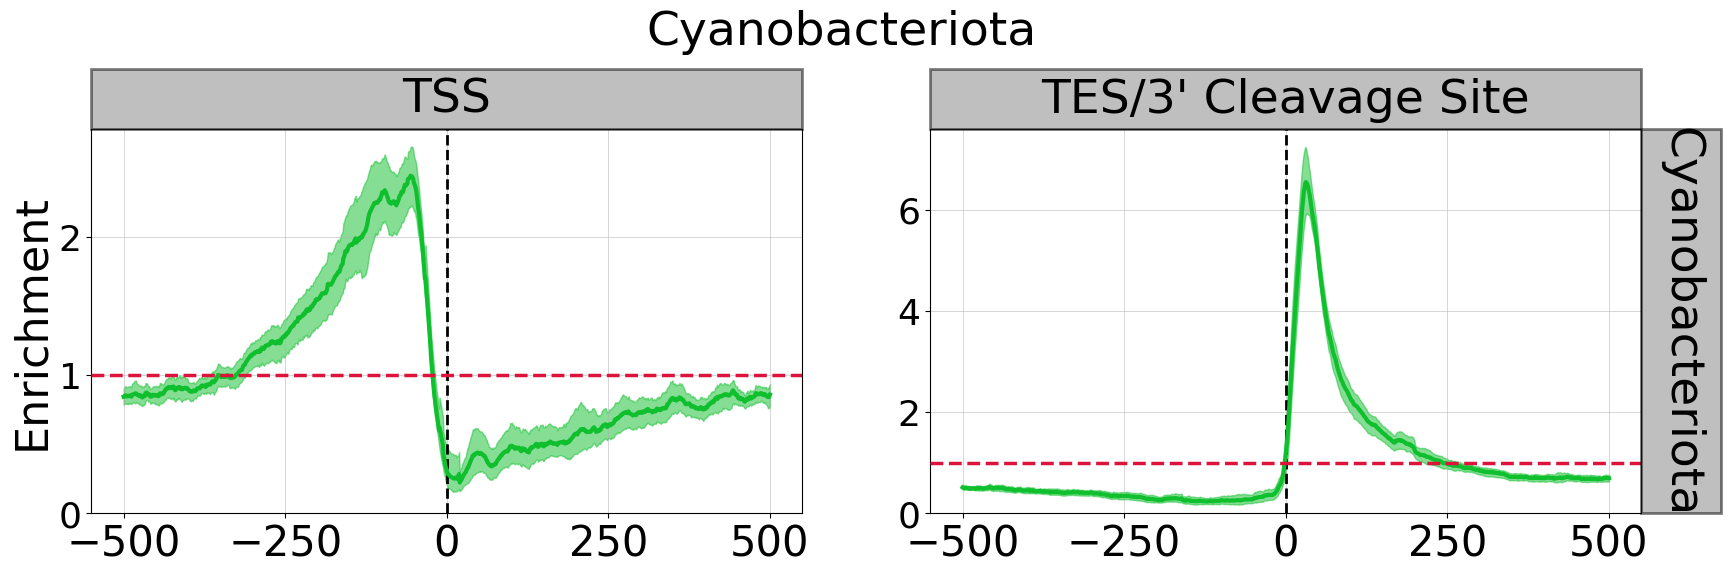

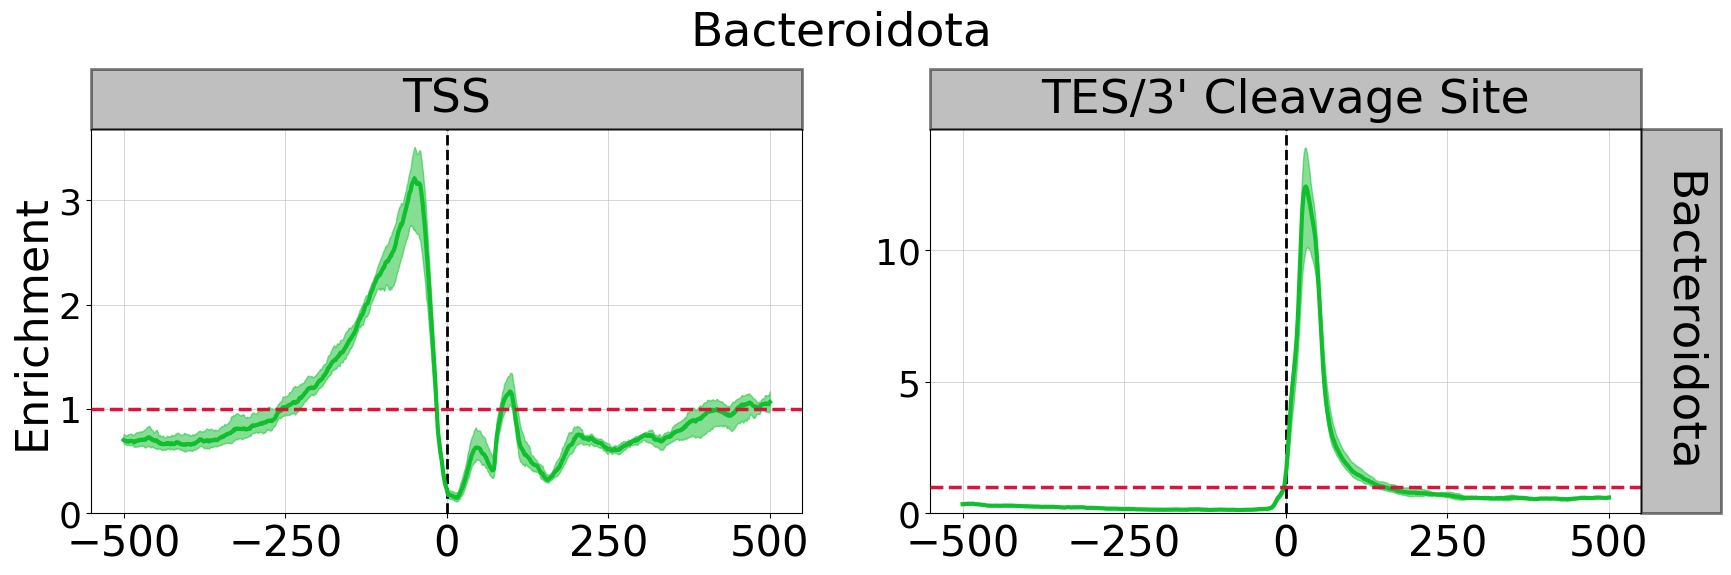

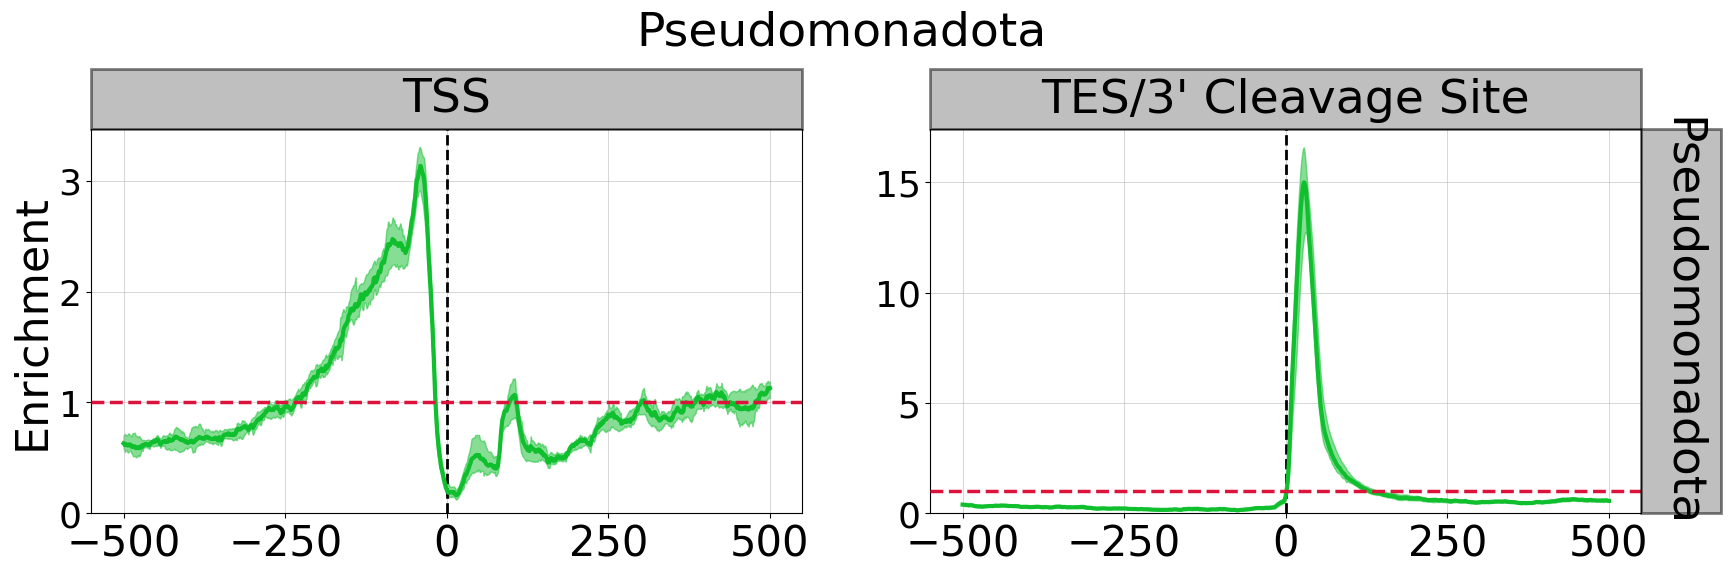

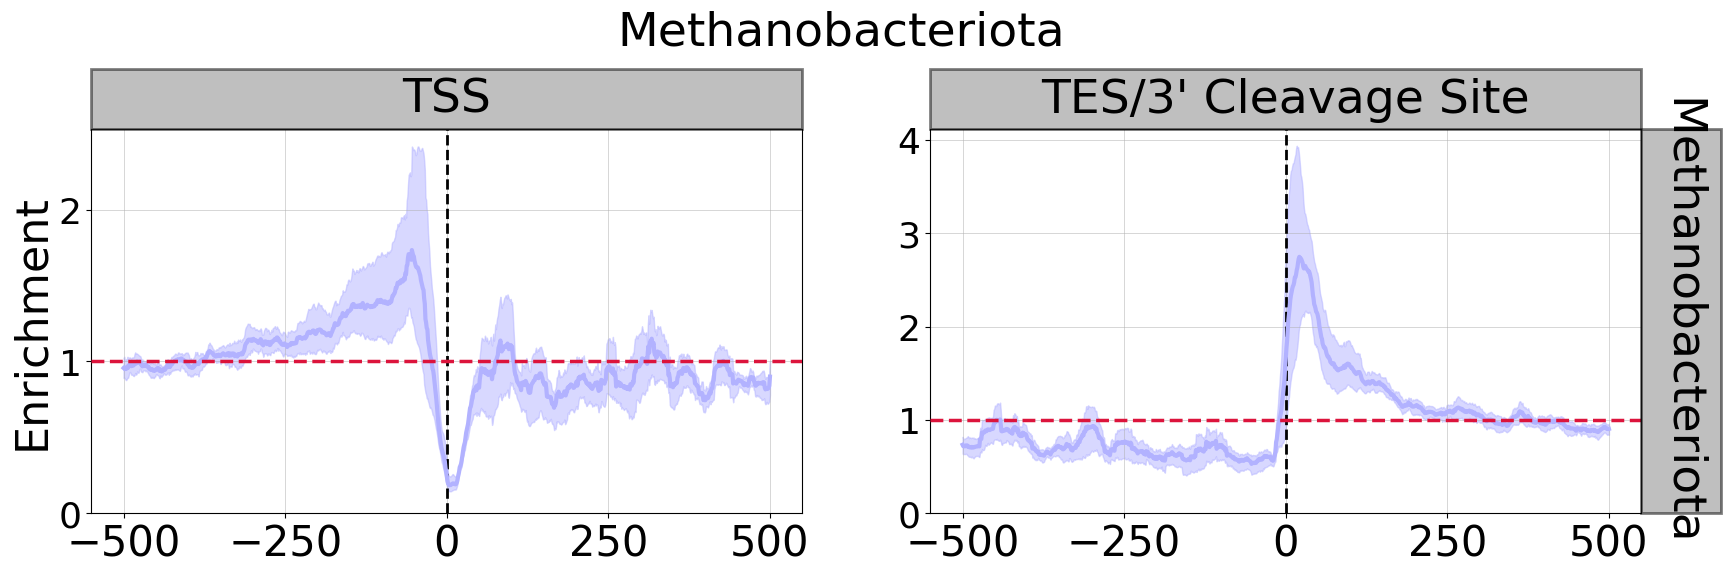

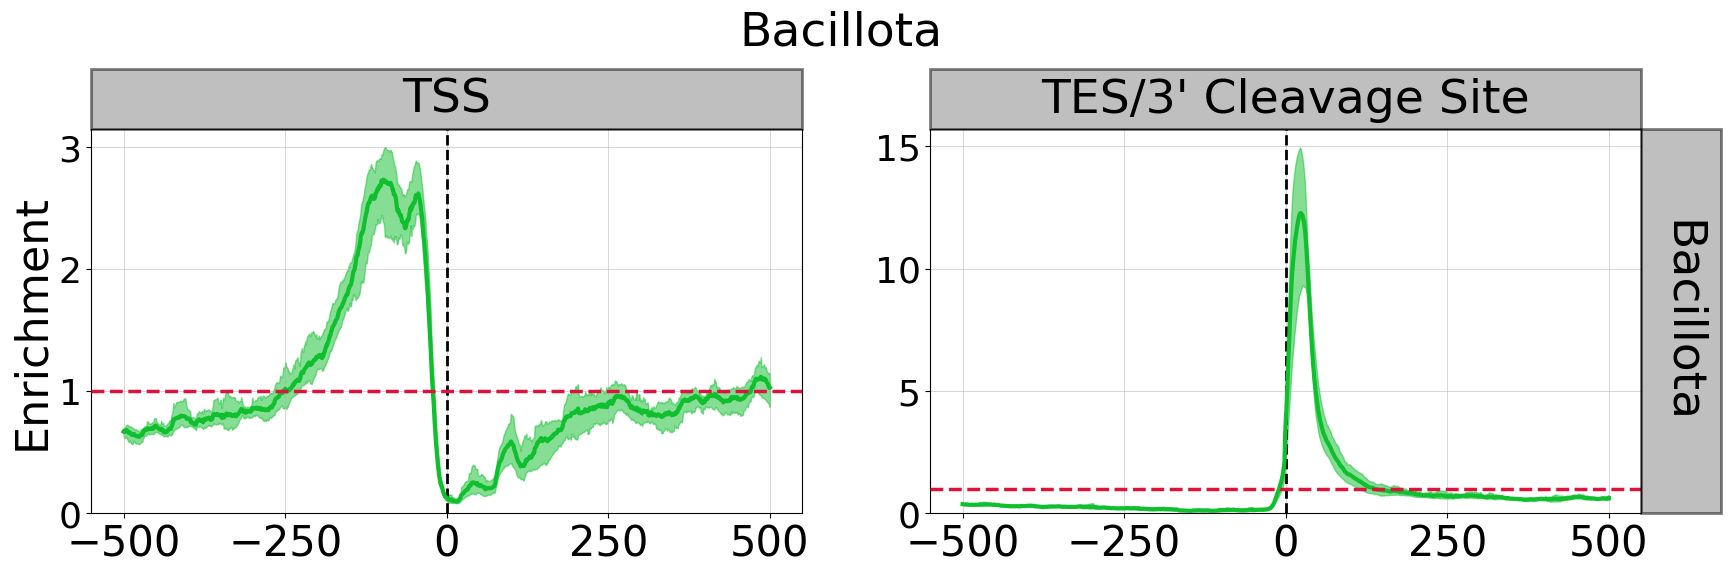

In [35]:
from matplotlib.pyplot import Rectangle
from scipy.stats import ks_2samp
from pathlib import Path

# Configuration
pattern = "IR"
mode = "density"
partition = "spacer_length"

indir = Path().cwd().joinpath(
                    f"enrichment_out_{pattern}", 
                    f"mode_{mode}_partition_{partition}", 
                    "phylum_bootstrap",
                )
assert indir.is_dir()
kolmogorov_tests = dict()
linewidth = 3.0
bootstrap_level = 'family'
alpha = 0.05
window_size = 500
eukaryotic_phyla = ["Ascomycota", "Basidiomycota", "Chordata"]
viral_phyla = ["Nucleocytoviricota", "Peploviricota", "Kitrinoviricota", "Uroviricota", "Duplornaviricota"]
bacterial_phyla = ["Actinomycetota", "Cyanobacteriota", "Bacteroidota", "Pseudomonadota"]
archaea_phyla = ["Methanobacteriota"]
selected_phyla = eukaryotic_phyla + viral_phyla + bacterial_phyla + archaea_phyla
selected_phyla += ["Bacillota"]

for idx, phylum in enumerate(selected_phyla):
    domain = phylum_to_domain[phylum]
    # enrichment_bootstrap_alpha_0.05.TES.density.phylum.Balneolota.csv
    infile = indir.joinpath(f"enrichment_bootstrap_alpha_0.05.TSS.density.phylum.{phylum}.csv")
    if not infile.is_file():
        print(infile)
        continue
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))
    plt.subplots_adjust(wspace=0.18, hspace=0.12)
    df = pd.read_csv(indir.joinpath(f"enrichment_bootstrap_alpha_0.05.TSS.density.phylum.{phylum}.csv"))\
                    .query(f"biotype == '.'")
    
    cols = list(map(str,range(-window_size, window_size+1)))
    tss_template = df.query(f"{partition} == 'generic'")
    tss_template_mean = tss_template.query(f"statistic == 'average' & bootstrap_level == '{bootstrap_level}'")[cols].values[0]
    tss_template_ci_lower = tss_template.query(f"statistic == 'lowerCI' & bootstrap_level == '{bootstrap_level}'")[cols].values[0]
    tss_template_ci_upper = tss_template.query(f"statistic == 'upperCI' & bootstrap_level == '{bootstrap_level}'")[cols].values[0]

    
    df = pd.read_csv(indir.joinpath(f"enrichment_bootstrap_alpha_0.05.TES.density.phylum.{phylum}.csv"))\
                                    .query(f"biotype == '.'")
    
    tes_template = df.query(f"{partition} == 'generic'")
    tes_template_mean = tes_template.query(f"statistic == 'average' & bootstrap_level == '{bootstrap_level}'")[cols].values[0]
    tes_template_ci_lower = tes_template.query(f"statistic == 'lowerCI' & bootstrap_level == '{bootstrap_level}'")[cols].values[0]
    tes_template_ci_upper = tes_template.query(f"statistic == 'upperCI' & bootstrap_level == '{bootstrap_level}'")[cols].values[0]

    # TES
    domain = phylum_to_domain[phylum]
    xaxis = range(-window_size, window_size+1)
    ax[0].plot(xaxis, 
            tss_template_mean, 
            color=color_templates['template'][domain], 
            lw=linewidth, 
            zorder=3)
    ax[0].fill_between(xaxis, 
                        y1=tss_template_ci_lower, 
                        y2=tss_template_ci_upper,
                        color=color_templates['template'][domain], 
                            alpha=0.5
                    )

    # TES
    ax[1].plot(xaxis, 
            tes_template_mean, 
            color=color_templates['template'][domain], 
            lw=linewidth, 
            zorder=3)
    ax[1].fill_between(xaxis, 
                        y1=tes_template_ci_lower, 
                        y2=tes_template_ci_upper,
                        color=color_templates['template'][domain], 
                            alpha=0.5
                      )
    # Adjust subplot spacing to create more room at the top for suptitle
    plt.subplots_adjust(top=0.75)
    # Add suptitle with higher position
    fig.suptitle(phylum, fontsize=34, y=0.95)
    
    def _modify_axis(ax, transcription_site):
        # xticks = ax.get_xticks()
        # ax.set_xticks(range(0, len(xticks), 100))
        if transcription_site == "start":
            # ax.set_ylabel("")
            ax.set_ylabel("Enrichment")
        else:
            ax.set_ylabel("")
    
        ax.set_ylim(ymin=0)
        
        ax.yaxis.label.set_size(32)
        ax.xaxis.label.set_size(19)
        ax.tick_params(axis="both", which="major", labelsize=26)
        ax.tick_params(axis="x", labelsize=30)
        # ax.set_xticklabels([])
        ax.grid(True, which='both', axis='x') 
        ax.grid(axis="both", lw=0.4, alpha=0.6, zorder=0)
        ax.grid(axis="both", lw=0.6, alpha=0.6, zorder=0)
        ax.axvline(0, linestyle='--', color='black', lw=2.0)
        ax.axhline(1.0, linestyle='--', color='crimson', lw=2.5, zorder=5)
        return ax
    
    ax[0] = _modify_axis(ax[0], transcription_site="start")
    ax[1] = _modify_axis(ax[1], transcription_site="end")
    
    fig.canvas.draw()
    sites = ["TSS", "TES/3' Cleavage Site"]
    for i, site in zip(range(2), sites):
        bbox = ax[i].get_position()
        rect_height = 0.1 
        rect_bottom = bbox.y1  
        rect_left = bbox.x0 
        rect_width = bbox.x1 - bbox.x0  

        fig.patches.append(Rectangle((rect_left, rect_bottom), rect_width, rect_height,
                                     edgecolor="black",
                                     linewidth=2.0,
                                     transform=fig.transFigure, facecolor='gray', alpha=0.5))
        
        fig.text(rect_left + rect_width / 2, 
                 rect_bottom + rect_height / 2, 
                 # title=site, 
                 s=site,
                 ha='center', 
                 va='center', 
                 color='black', 
                 fontsize=34
                )
        if i == 1:
            bbox = ax[i].get_position()
            rect_width = 0.04  # Narrow width for a vertical bar
            rect_left = bbox.x1  # Align to the right of the y-axis
            rect_height = bbox.y1 - bbox.y0  # Match the subplot height
            rect_bottom = bbox.y0  # Align with the bottom of the subplot
    
            fig.patches.append(Rectangle((rect_left, rect_bottom), 
                                         rect_width, rect_height,
                                         edgecolor="black",
                                         linewidth=2.0,
                                         transform=fig.transFigure, facecolor='gray', alpha=0.5))
            
            # Add title text
            fig.text(rect_left + rect_width / 2, 
                     rect_bottom + rect_height / 2, 
                     s=phylum,
                     ha='center', 
                     va='center', 
                     color='black',
                     rotation=270,
                     fontsize=34)

    target = Path(f"{pattern}_figures")
    target.mkdir(exist_ok=True, parents=True)
    fig.savefig(f"{target}/{pattern}:_TSS_TES_distribution_phylum_{phylum}.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    # fig.suptitle(phylum, fontsize=28)

In [81]:
## Partition Plot Stacking

In [190]:
tss["spacer_length"].unique()

spacer_length
str
"""1"""
"""3"""
"""0"""
"""generic"""
"""2"""
"""4"""


In [ ]:
# # #
cols = ["#assembly_accession", "species_taxid", "organism_name", "phylum", "kingdom", "domain"]
if isinstance(tss, pd.DataFrame):
    tss = pl.from_pandas(tss)
if isinstance(tes, pd.DataFrame):
    tes = pl.from_pandas(tes)
if isinstance(tree_of_life, pd.DataFrame):
    tol = pl.from_pandas(tree_of_life[cols])
    
tss_cn_tree_of_life = (
                tss.filter(pl.col("biotype") != ".")
                        .join(
                            tol,
                            on="#assembly_accession"
                        )
)
# # # 
tes_cn_tree_of_life = (
                tes.filter(pl.col("biotype") != ".")
                   .join(
                       tol,
                        on="#assembly_accession"
                   )
)

In [191]:
from bokeh.io import output_notebook 
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, ColorBar, LinearColorMapper
from bokeh.transform import transform
from bokeh.palettes import RdYlBu11
output_notebook()

Loading BokehJS ...

In [192]:
biotype = "protein_coding" 
coding_tss = tss_cn_tree_of_life.filter(
                                     pl.col("biotype") == biotype)
coding_tss

-500,-499,-498,-497,-496,-495,-494,-493,-492,-491,-490,-489,-488,-487,-486,-485,-484,-483,-482,-481,-480,-479,-478,-477,-476,-475,-474,-473,-472,-471,-470,-469,-468,-467,-466,-465,-464,…,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,total_targets,matched_targets,matched_targets_heteropolarity,matched_targets_homopolarity,target_perc,total_queries,matched_queries,query_perc,site,biotype,spacer_length,#assembly_accession,species_taxid,organism_name,phylum,kingdom,domain
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,i64,i64,f64,str,str,str,str,i64,str,str,str,str
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11,9,null,null,81.82,980,11,1.12,"""TSS""","""protein_coding""","""0""","""GCF_000008385.1""",80849,"""Wolbachia endosymbiont strain …","""Pseudomonadota""","""Pseudomonadati""","""Bacteria"""
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,6,null,null,100.0,980,7,0.71,"""TSS""","""protein_coding""","""1""","""GCF_000008385.1""",80849,"""Wolbachia endosymbiont strain …","""Pseudomonadota""","""Pseudomonadati""","""Bacteria"""
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,3,null,null,60.0,980,4,0.41,"""TSS""","""protein_coding""","""2""","""GCF_000008385.1""",80849,"""Wolbachia endosymbiont strain …","""Pseudomonadota""","""Pseudomonadati""","""Bacteria"""
0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,4,null,null,80.0,980,8,0.82,"""TSS""","""protein_coding""","""3""","""GCF_000008385.1""",80849,"""Wolbachia endosymbiont strain …","""Pseudomonadota""","""Pseudomonadati""","""Bacteria"""
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,4,null,null,66.67,980,6,0.61,"""TSS""","""protein_coding""","""4""","""GCF_000008385.1""",80849,"""Wolbachia endosymbiont strain …","""Pseudomonadota""","""Pseudomonadati""","""Bacteria"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,…,4.0,4.0,4.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,104,65,null,null,62.5,4804,82,1.71,"""TSS""","""protein_coding""","""1""","""GCF_023716625.1""",2819098,"""Vibrio sp. SCSIO 43153""","""Pseudomonadota""","""Pseudomonadati""","""Bacteria"""
1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5.0,5.0,6.0,5.0,5.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,109,70,null,null,64.22,4804,92,1.92,"""TSS""","""protein_coding""","""2""","""GCF_023716625.1""",2819098,"""Vibrio sp. SCSIO 43153""","""Pseudomonadota""","""Pseudomonadati""","""Bacteria"""
1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0

In [189]:
coding_tss[col_name].unique()

spacer_length
str
"""1"""
"""0"""
"""2"""
"""generic"""
"""3"""
"""4"""


In [147]:
coding_tss.select([col_name] + list(map(str, range(-window_size, window_size)))).to_pandas().set_index(col_name).T

spacer_length,0,1,2,3,4,generic,0,1,2,3,...,2,3,4,generic,0,1,2,3,4,generic
-500,2.0,1.0,0.0,0.0,0.0,7.0,7.0,1.0,0.0,1.0,...,0.0,0.0,2.0,6.0,0.0,3.0,0.0,2.0,0.0,13.0
-499,2.0,1.0,0.0,0.0,0.0,8.0,7.0,1.0,0.0,1.0,...,0.0,0.0,2.0,6.0,0.0,3.0,0.0,2.0,0.0,12.0
-498,2.0,1.0,0.0,0.0,0.0,8.0,7.0,1.0,0.0,1.0,...,0.0,0.0,2.0,6.0,1.0,3.0,0.0,2.0,0.0,12.0
-497,2.0,1.0,0.0,0.0,0.0,8.0,7.0,1.0,1.0,1.0,...,0.0,0.0,2.0,6.0,1.0,3.0,0.0,2.0,0.0,12.0
-496,2.0,1.0,0.0,0.0,0.0,8.0,7.0,1.0,1.0,1.0,...,0.0,0.0,2.0,7.0,1.0,3.0,0.0,2.0,0.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,4.0,1.0,0.0,1.0,0.0,0.0,3.0
496,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,4.0,1.0,0.0,1.0,0.0,0.0,3.0
497,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,4.0,1.0,0.0,1.0,0.0,0.0,3.0
498,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,4.0,1.0,0.0,1.0,0.0,0.0,3.0


In [194]:
domain = "Archaea"

# # # # 
tss_cds_partition_data = dict()
tes_cds_partition_data = dict()
# 
biotypes = ["protein_coding", "non_coding"]
col_name = "spacer_length"
for domain in domains:
    for biotype in biotypes:
        coding_tss = (
                    tss_cn_tree_of_life
                    .filter(pl.col("domain") == domain, 
                            pl.col(col_name) != "generic", 
                            pl.col("biotype") == biotype)
                    .with_columns(
                        pl.col(col_name).cast(pl.Int32).alias(col_name)
                    )
                    .group_by(col_name, maintain_order=True)
                    .agg(
                        *[pl.col(str(i)).sum() for i in range(-window_size, window_size+1)]
                    )
                    .sort(col_name)
                    # .select([col_name] + list(map(str, xrange)))
                    .to_pandas()
                    .set_index(col_name).T
                    .reset_index()
                    .rename(columns={i: str(i) for i in range(0, 9)})
            )
        tss_cds_partition_data[domain, biotype] = coding_tss 
        
        coding_tes = (
                    tes_cn_tree_of_life
                    .filter(pl.col("domain") == domain, 
                            pl.col(col_name) != "generic", 
                            pl.col("biotype") == biotype)
                    .with_columns(
                        pl.col(col_name).cast(pl.Int32).alias(col_name)
                    )
                    .group_by(col_name, maintain_order=True)
                    .agg(
                        *[pl.col(str(i)).sum() for i in range(-window_size, window_size+1)]
                    )
                    .sort(col_name)
                    # .select([col_name] + list(map(str, xrange)))
                    .to_pandas()
                    .set_index(col_name).T
                    .reset_index()
                    .rename(columns={i: str(i) for i in range(0, 9)})
            )
        tes_cds_partition_data[domain, biotype] = coding_tss 

tss_cds_partition_data[domain, biotype]

spacer_length,index,0,1,2,3,4
0,-500,13.0,11.0,14.0,16.0,13.0
1,-499,15.0,11.0,14.0,16.0,14.0
2,-498,15.0,8.0,10.0,16.0,15.0
3,-497,14.0,9.0,10.0,16.0,15.0
4,-496,14.0,9.0,10.0,16.0,15.0
...,...,...,...,...,...,...
996,496,14.0,12.0,13.0,35.0,12.0
997,497,14.0,14.0,13.0,36.0,10.0
998,498,14.0,13.0,14.0,38.0,14.0
999,499,13.0,13.0,16.0,38.0,14.0


In [ ]:
maximum = coding_tss.drop(columns=["index"]).sum(axis=1).max()
maximum

np.float64(2461.0)

In [ ]:
from bokeh.models import Span 

col_name = "spacer_length"
figures = {"tss": [], "tes": []}
spacers = list(range(0, 9))
spacers = list(range(10, 31))
biotype = "protein_coding"
window_size = 500
xrange = list(range(-window_size, window_size+1))

for i, domain in enumerate(domains):
    for typ, cds_partition_data in zip(["tss", "tes"], [tss_cds_partition_data, tes_cds_partition_data]):
        p = figure(
                # x_range=(0, 9),
                toolbar_location=None,
                title=domain,
                # output_backend="svg",
                height=500,
                width=900,
            )

        span = Span(location=0, dimension='height', line_color='black', line_dash='dashed', line_width=3)
        p.add_layout(span)  
        p.title.align = 'center'
        p.title.text_font_style = 'normal'
        p.title.text_font_size = '30pt'
        p.x_range.start = - window_size
        p.x_range.end = window_size + 1
        p.y_range.start = - 0.0
        maximum = cds_partition_data[domain, biotype].drop(columns=["index"]).sum(axis=1).max()
        p.y_range.end = maximum * 1.1
        p.xaxis.axis_label = ''
        if typ == "tss":
            p.yaxis.axis_label = f'{pattern} Occurrences'
        else:
            p.yaxis.axis_label = ''
        p.axis.axis_label_text_font_style = 'normal'
        p.axis.axis_label_text_font_size = '25pt'
        p.axis.major_label_text_font_size = '20pt'

        source = ColumnDataSource(cds_partition_data[domain, biotype])
        stackers =  [0, 1, 2, 3, 4]    
        p.varea_stack(stackers=list(map(str, stackers)),
                  # color=brewer['Spectral'][len(canonical)], 
                  color=sns.color_palette("Spectral", n_colors=len(spacers)).as_hex()[:len(stackers)],
                  # legend_label=list(map(str.upper, canonical)),
                  x="index",
                  source=source)

        # p.legend.orientation = "horizontal"
        # p.legend.background_fill_color = "#fafafa"
        # p.legend.
        figures[typ].append(p)

from bokeh.layouts import gridplot
gridplot = gridplot([[figures["tss"][i], figures["tes"][i]] for i in range(len(domains))],
                   toolbar_location=None)

target = Path(f"{pattern}_figures").joinpath("biophysical")
target.mkdir(exist_ok=True)
# export_svg(p, filename=target / f"streamplot_0
show(gridplot)


In [ ]:
# config 
pattern = "IR" 
mode = "density" 
partition = "spacer_length" 

indir = Path().cwd().joinpath(f"enrichment_out_{pattern}", f"mode_{mode}_partition_{partition}")
assert indir.is_dir()

density = indir.joinpath(f"enrichment_")


/tmp/ipykernel_3580511/2895821294.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend(loc=0)


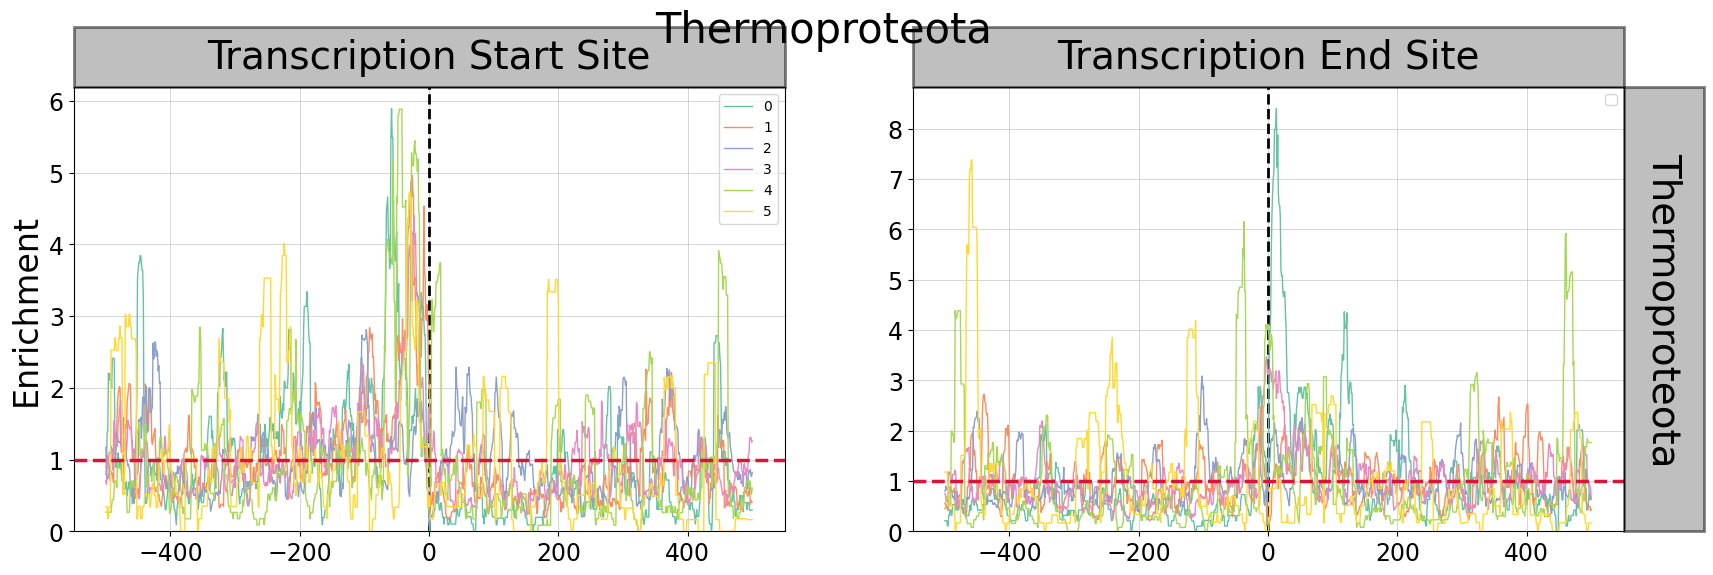

/tmp/ipykernel_3580511/2895821294.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend(loc=0)


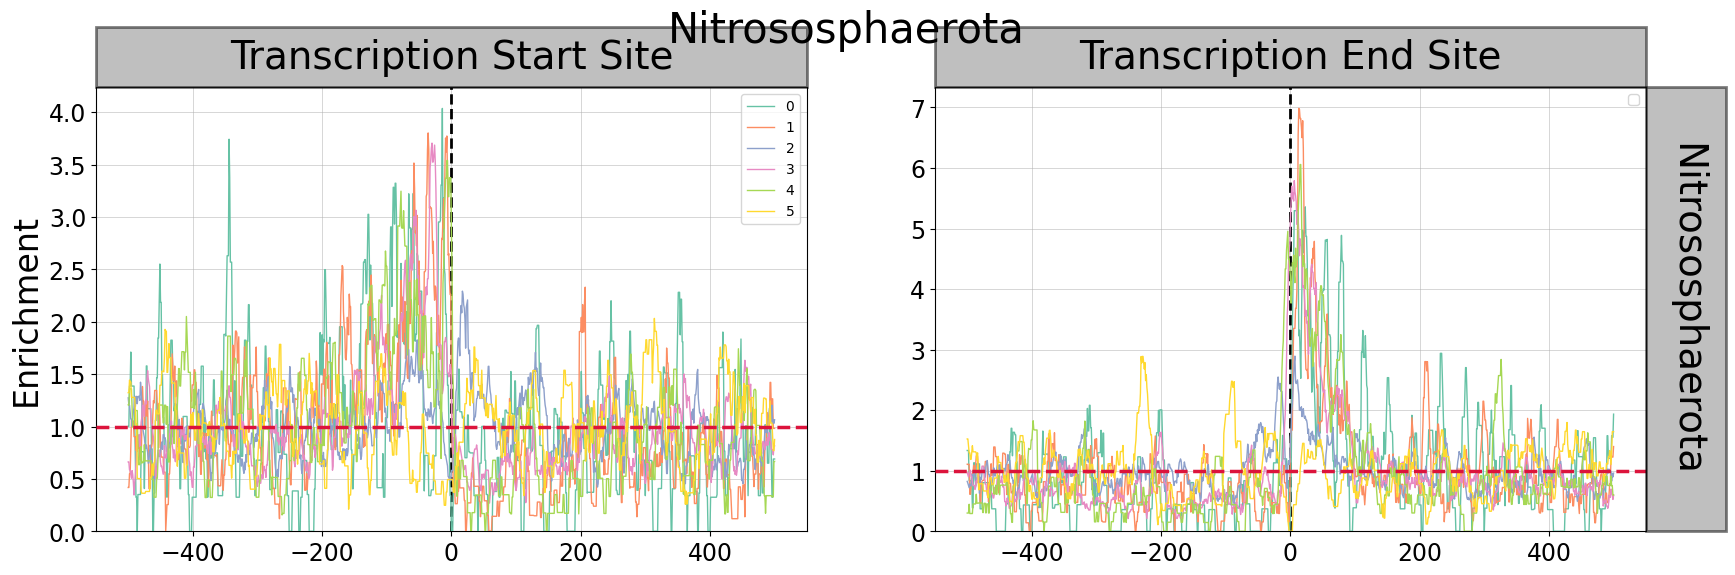

/tmp/ipykernel_3580511/2895821294.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend(loc=0)


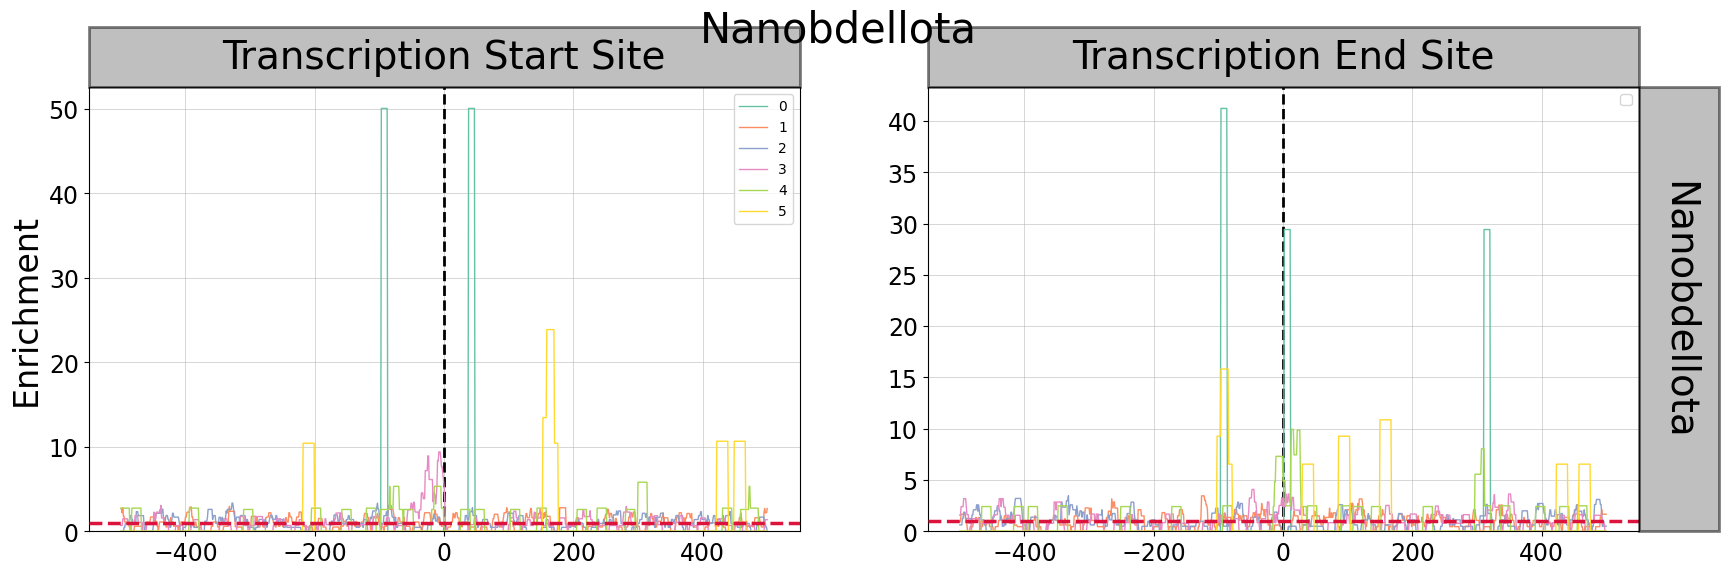

/tmp/ipykernel_3580511/2895821294.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend(loc=0)


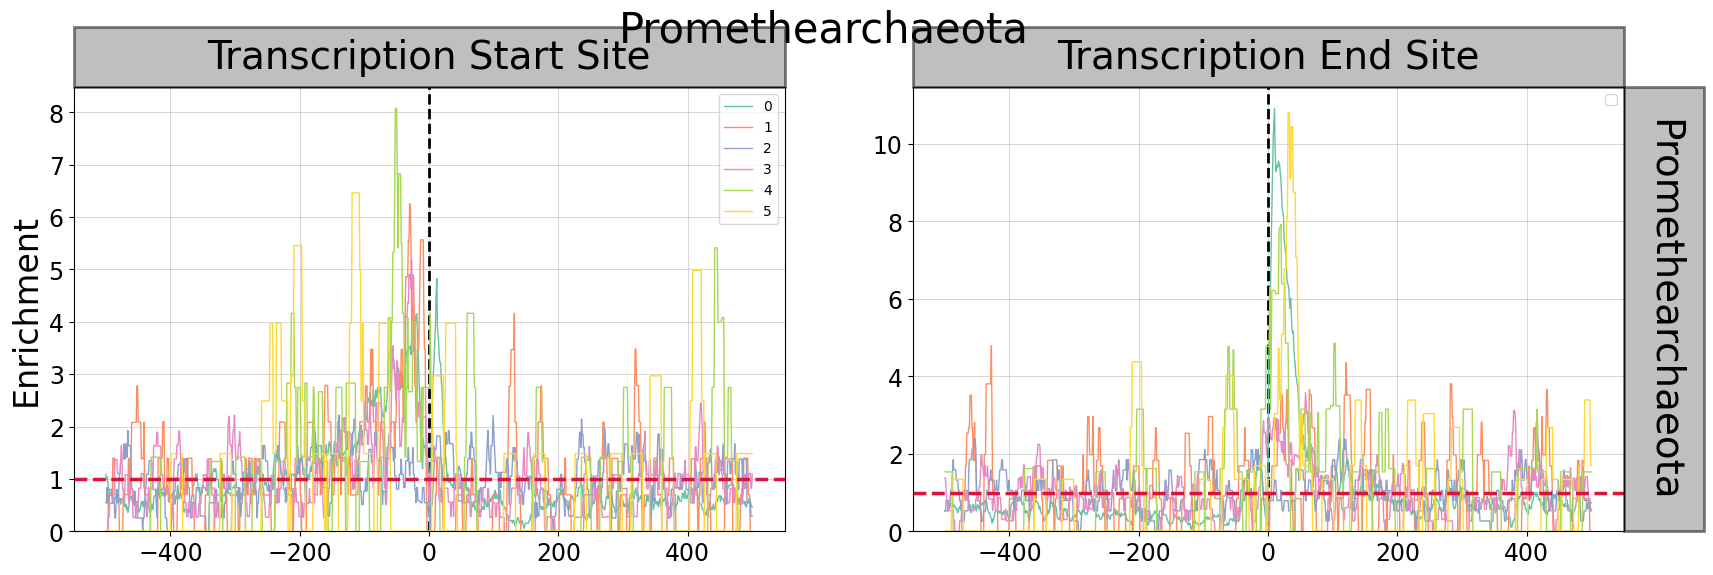

/tmp/ipykernel_3580511/2895821294.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend(loc=0)


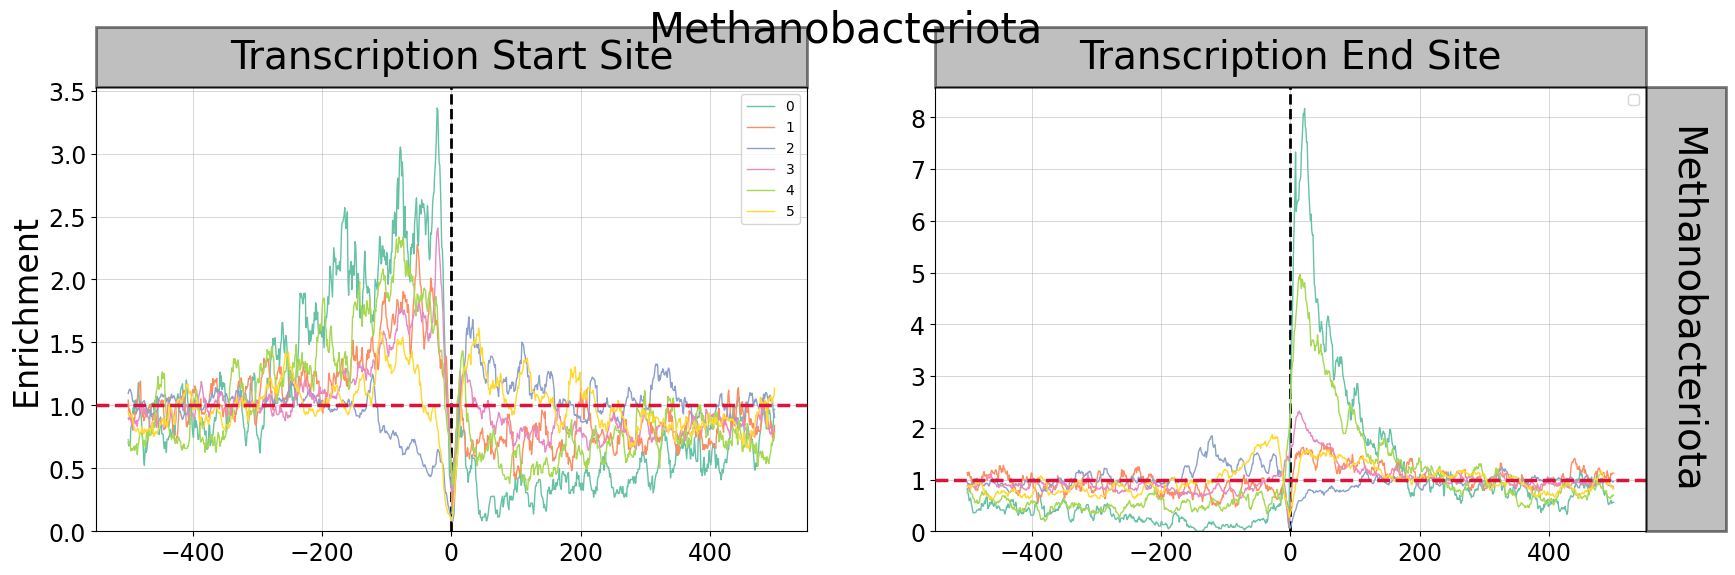

/tmp/ipykernel_3580511/2895821294.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend(loc=0)


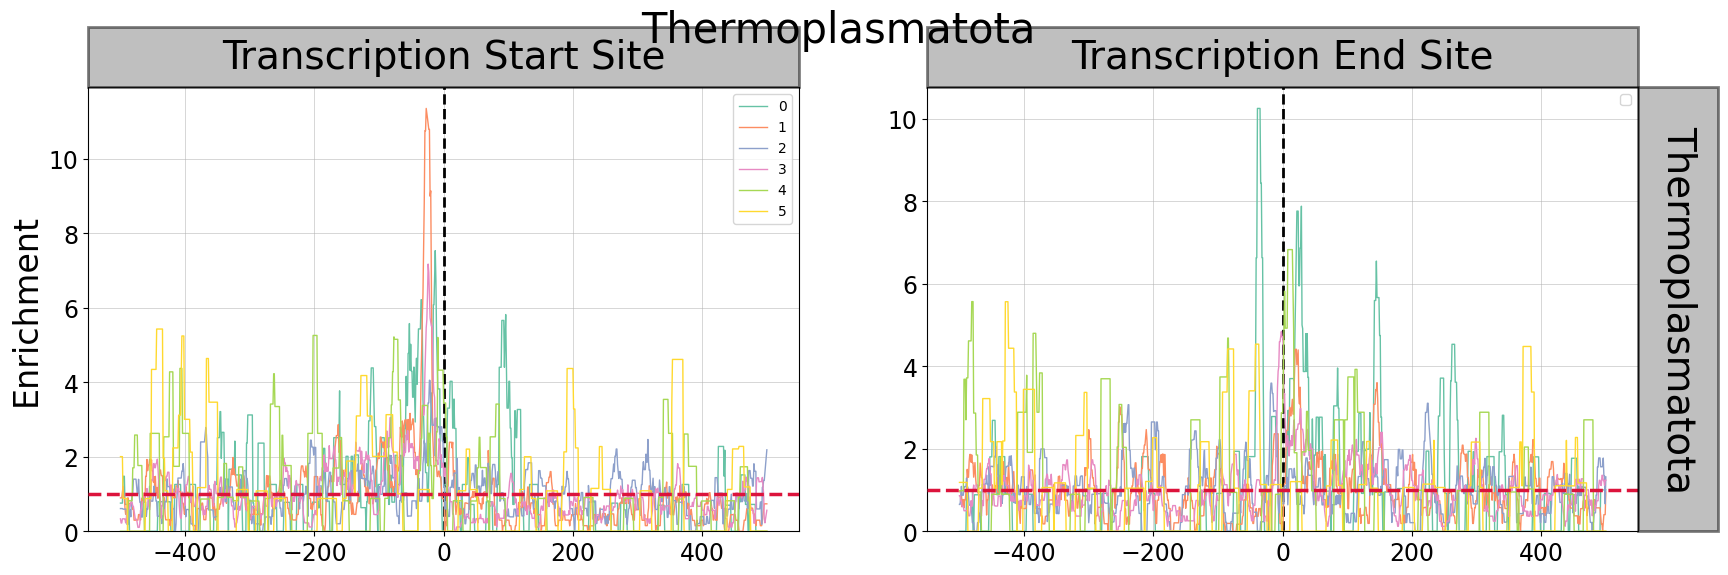

In [58]:
from matplotlib.pyplot import Rectangle
from scipy.stats import ks_2samp
from pathlib import Path

density = Path("/storage/group/izg5139/default/nicole/STR_RTR/coverage/enrichment_out/mode_density/phylum").resolve()
assert density.is_dir()
kolmogorov_tests = dict()

kolmogorov_tests = dict()
linewidth = 1.0
window_size = 500
eukaryotic_phyla = ["Ascomycota", "Basidiomycota", "Chordata"]
viral_phyla = ["Nucleocytoviricota", "Peploviricota", "Kitrinoviricota", "Uroviricota", "Duplornaviricota"]
bacterial_phyla = ["Actinomycetota", "Cyanobacteriota", "Bacteroidota", "Pseudomonadota"]
archaea_phyla = ["Methanobacteriota"]
selected_phyla = eukaryotic_phyla + viral_phyla + bacterial_phyla + archaea_phyla


partition_values = list(map(str, range(1, 7)))
for idx, phylum in enumerate(phylums):
    domain = phylum_to_domain[phylum]

    if domain != "Archaea":
        continue
    # enrichment_bootstrap_alpha_0.05.TES.polarity.domain.Archaea.csv
    
    if not density.joinpath(f"enrichment_bootstrap_alpha_0.05.TSS.density.phylum.{phylum}.csv").is_file():
        continue
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))
    plt.subplots_adjust(wspace=0.18, hspace=0.12)
    df_TSS = pd.read_csv(density.joinpath(f"enrichment_bootstrap_alpha_0.05.TSS.density.phylum.{phylum}.csv"))\
                    .query(f"biotype == '.'")
       
    df_TES = pd.read_csv(density.joinpath(f"enrichment_bootstrap_alpha_0.05.TES.density.phylum.{phylum}.csv"))\
                                    .query(f"biotype == '.'")
    
    cols = list(map(str,range(-window_size, window_size+1)))
    domain = phylum_to_domain[phylum]
    xaxis = range(-window_size, window_size+1)
    
    for i, partition in enumerate(partition_values):
        tss_template = df_TSS.query(f"sru == '{partition}'")
        tss_template_mean = tss_template.query("statistic == 'average'")[cols].values[0]
        tss_template_ci_lower = tss_template.query("statistic == 'lowerCI'")[cols].values[0]
        tss_template_ci_upper = tss_template.query("statistic == 'upperCI'")[cols].values[0]

 
        tes_template = df_TES.query(f"sru == '{partition}'")
        tes_template_mean = tes_template.query("statistic == 'average'")[cols].values[0]
        tes_template_ci_lower = tes_template.query("statistic == 'lowerCI'")[cols].values[0]
        tes_template_ci_upper = tes_template.query("statistic == 'upperCI'")[cols].values[0]

        # TSS
        ax[0].plot(xaxis, 
                tss_template_mean, 
                # color=color_templates['template'][domain], 
                color=sns.color_palette("Set2")[i],
                lw=linewidth, 
                zorder=3,
                   label=str(i)
                  )
        # ax[0].fill_between(xaxis, 
        #                     y1=tss_template_ci_lower, 
        #                     y2=tss_template_ci_upper,
        #                     color=color_templates['template'][domain], 
        #                         alpha=0.5
        #                 )
    
        # TES
        ax[1].plot(xaxis, 
                tes_template_mean, 
                # color=color_templates['template'][domain], 
                color=sns.color_palette("Set2")[i],

                lw=linewidth, 
                zorder=3)
        # ax[1].fill_between(xaxis, 
        #                     y1=tes_template_ci_lower, 
        #                     y2=tes_template_ci_upper,
        #                     color=color_templates['template'][domain], 
        #                         alpha=0.5
        #                   )
        
    # ax.legend(handles=[mpatches.Patch(color=color_templates['template'][domain], label='Template'),
    #                   mpatches.Patch(color=color_templates['non-template'][domain], label='Non-template')
    #                  ], loc=0
    #         )
    fig.suptitle(phylum, fontsize=30)
    plt.subplots_adjust(top=0.85)
    for i in range(2):
        ax[i].legend(loc=0)
    def _modify_axis(ax, transcription_site):
        # xticks = ax.get_xticks()
        # ax.set_xticks(range(0, len(xticks), 100))
        if transcription_site == "start":
            # ax.set_ylabel("")
            ax.set_ylabel("Enrichment")
        else:
            ax.set_ylabel("")
    
        ax.set_ylim(ymin=0)
        
        ax.yaxis.label.set_size(24)
        ax.xaxis.label.set_size(19)
        ax.tick_params(axis="both", which="major", labelsize=17)
        # ax.set_xticklabels([])
        ax.grid(True, which='both', axis='x') 
        ax.grid(axis="both", lw=0.4, alpha=0.6, zorder=0)
        ax.grid(axis="both", lw=0.6, alpha=0.6, zorder=0)
        ax.axvline(0, linestyle='--', color='black', lw=2.0)
        ax.axhline(1.0, linestyle='--', color='crimson', lw=2.5, zorder=5)
        return ax
    
    ax[0] = _modify_axis(ax[0], transcription_site="start")
    ax[1] = _modify_axis(ax[1], transcription_site="end")
    
    fig.canvas.draw()
    # Get the bounding box of the second subplot in figure coordinates
    sites = ["Transcription Start Site", "Transcription End Site"]
    for i, site in zip(range(2), sites):
        bbox = ax[i].get_position()
        rect_height = 0.1 # Height of the rectangle relative to figure
        rect_bottom = bbox.y1  # Bottom of the rectangle aligns with the top of the subplot
        rect_left = bbox.x0  # Left aligns with the subplot
        rect_width = bbox.x1 - bbox.x0  # Width matches the subplot
        
        # Add rectangle
        fig.patches.append(Rectangle((rect_left, rect_bottom), rect_width, rect_height,
                                     edgecolor="black",
                                     linewidth=2.0,
                                     transform=fig.transFigure, facecolor='gray', alpha=0.5))
        
        # Add title text
        fig.text(rect_left + rect_width / 2, 
                 rect_bottom + rect_height / 2, 
                 # title=site, 
                 s=site,
                 ha='center', 
                 va='center', 
                 color='black', 
                 fontsize=28
                )
        # Add rectangle
        if i == 1:
            bbox = ax[i].get_position()
            rect_width = 0.04  # Narrow width for a vertical bar
            rect_left = bbox.x1  # Align to the right of the y-axis
            rect_height = bbox.y1 - bbox.y0  # Match the subplot height
            rect_bottom = bbox.y0  # Align with the bottom of the subplot
    
            fig.patches.append(Rectangle((rect_left, rect_bottom), 
                                         rect_width, rect_height,
                                         edgecolor="black",
                                         linewidth=2.0,
                                         transform=fig.transFigure, facecolor='gray', alpha=0.5))
            
            # Add title text
            fig.text(rect_left + rect_width / 2, 
                     rect_bottom + rect_height / 2, 
                     s=phylum,
                     ha='center', 
                     va='center', 
                     color='black',
                     rotation=270,
                     fontsize=28)


    target = Path("STR_figures_RTR").joinpath("phylums")
    target.mkdir(exist_ok=True, parents=True)
    # fig.savefig(f"{target}/MR_TSS_TES_distribution_phylum_{phylum}_partitioned.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    # fig.suptitle(phylum, fontsize=28)